# Copenhagen Housing Price Model

Hierarchical Bayesian model of residential sqm prices across 9 Copenhagen districts (1992–2024), with a 2026–2060 forecast driven by Statistics Denmark population projections.

**Data sources**
- Housing transactions: [Kaggle – Danish Residential Housing Prices 1992–2024](https://www.kaggle.com/datasets/martinfrederiksen/danish-residential-housing-prices-1992-2024)
- Socioeconomic panel: Statistics Denmark (KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026)

### Table of Contents
1. [Phase 1 - Data Ingestion & EDA](#phase-1---data-ingestion--eda)
    * Task 1.1 Housing transaction data - Tomas
    * Task 1.2 & Task 1.3 Statistics Denmark - David
2. [Phase 2 - Feature Engineering](#phase-2---feature-engineering)
    * Task 2.1 Aggregate housing prices to district-year level & 2.2 Align district names & 2.3 Join raw transactions with panel & 2.4 Join housing aggregates - Ursula
    * Task 2.5 - Reduce covariates
    * Task 2.6 - Feature EDA
3. Phase 3 - PGM design
4. Phase 4 - Pyro implementation 
5. Phase 5 - Inference 
6. Phase 6 - Results & 2026-2060 forecast

## Imports

In [1]:
# ---------------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------------
import re
from functools import partial
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

# ---------------------------------------------------------------------------
# Data / numeric
# ---------------------------------------------------------------------------
import sys
import numpy as np
import pandas as pd
import pyarrow as pa
# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------------
# Machine learning / statistics
# ---------------------------------------------------------------------------
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde, norm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ---------------------------------------------------------------------------
# PyTorch
# ---------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------------------------------------------------------------------
# Pyro / probabilistic programming
# ---------------------------------------------------------------------------
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
from pyro.infer import MCMC, NUTS, HMC, SVI, Trace_ELBO, Predictive, TraceEnum_ELBO
from pyro.infer.autoguide import AutoNormal, AutoDiagonalNormal,AutoMultivariateNormal
from pyro.optim import Adam, ClippedAdam
import pyro.poutine as poutine
import pyro.optim
from pyro.distributions import constraints




print(sys.executable)
print("pandas:", pd.__version__)
print("pyarrow:", pa.__version__)
print("torch:", torch.__version__)
print("pyro:", pyro.__version__)

/opt/homebrew/Caskroom/miniforge/base/envs/modelML_project/bin/python
pandas: 2.3.3
pyarrow: 24.0.0
torch: 2.2.2
pyro: 1.9.1+ab0491a


## Phase 1 - Data Ingestion & EDA
### 1.1 Housing transaction data
Load the Kaggle parquet, filter to Copenhagen zip codes (1000–2720), and map zip codes to the 10 Copenhagen districts used by Statistics Denmark. Basic EDA: sales counts per district, price distributions, and temporal trends.

### 1.1 Housing transaction data (DKHousingPrices)

In [16]:
df = pd.read_parquet('data/DKHousingPrices.parquet', engine='pyarrow')
df['date'] = pd.to_datetime(df['date'])
print("Original shape:", df.shape)

mask = df['zip_code'].between(1000, 2720)
print("Rows matching København:", mask.sum())

df = df[mask].copy()

# Map postal codes to neighborhoods using ranges
def map_zip_to_district(zip_code):
    # Indre By (City Center)
    if 1000 <= zip_code <= 1499:
        return 'Indre By'
    
    # Østerbro
    elif zip_code in [2100, 2150]:
        return 'Østerbro'
    
    # Nørrebro
    elif 2200 <= zip_code <= 2204:
        return 'Nørrebro'
    
    # Vesterbro/Kongens Enghave (includes Sydhavn 2450)
    elif 1500 <= zip_code <= 1799 or zip_code == 2450:
        return 'Vesterbro'
    
    # Valby
    elif zip_code == 2500:
        return 'Valby'
    
    # Vanløse
    elif zip_code == 2720:
        return 'Vanløse'
    
    # Brønshøj-Husum
    elif zip_code == 2700:
        return 'Brønshøj-Husum'
    
    # Bispebjerg (includes Nordvest)
    elif 2400 <= zip_code <= 2404:
        return 'Bispebjerg'
    
    # Amager Øst & Vest
    elif zip_code == 2300:
        return 'Amager'
    
    # Frederiksberg (Separate municipality, but often grouped)
    elif zip_code == 2000 or 1800 <= zip_code <= 1999:
        return 'Frederiksberg'
        
    return None
df['neighborhood'] = df['zip_code'].apply(map_zip_to_district)

# Show unmatched postal codes
unmatched = df[df['neighborhood'].isna()]['zip_code'].unique()
if len(unmatched) > 0:
    print(f"Unmatched postal codes: {sorted(unmatched)}")

df.drop(columns=['quarter', 'house_id', 'city', 'area', 'region'], inplace=True, errors='ignore')
df.reset_index(drop=True, inplace=True)
df.head()

Original shape: (1507908, 19)
Rows matching København: 150382
Unmatched postal codes: [2600, 2605, 2610, 2620, 2625, 2630, 2635, 2640, 2650, 2660, 2665, 2670, 2680, 2690]


,date,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%,neighborhood
0,2024-10-24,Villa,regular_sale,1997,6500000,-3.0,5,142.0,45774.648438,Spættevej 16,2680,3.1,NaN,NaN,None
1,2024-10-24,Apartment,regular_sale,2006,4115000,0.0,3,77.0,53441.558594,"Teglholmsgade 8B, 3. th",2450,3.1,NaN,NaN,Vesterbro
2,2024-10-24,Apartment,regular_sale,1885,3400000,0.0,2,46.0,73913.046875,"Jakob Dannefærds Vej 10B, 4. th",1973,3.1,NaN,NaN,Frederiksberg
3,2024-10-24,Villa,family_sale,1929,4750000,0.0,4,118.0,40254.238281,Herfølgevej 19,2700,3.1,NaN,NaN,Brønshøj-Husum
4,2024-10-23,Villa,regular_sale,1949,4550000,-4.0,4,112.0,40625.000000,Vestre Plantagevej 3,2680,3.1,NaN,NaN,None


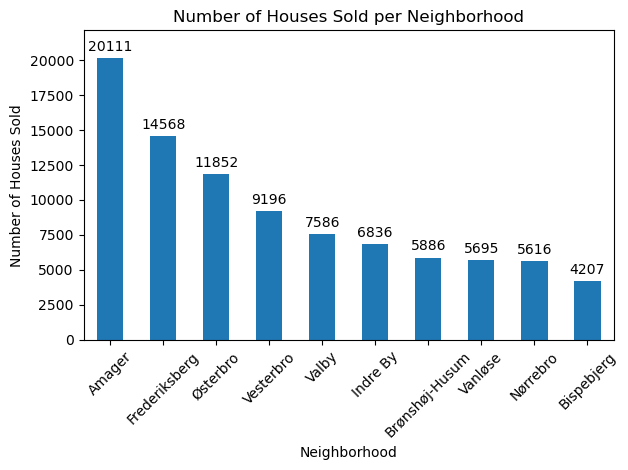

In [17]:
ax = df['neighborhood'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Number of Houses Sold per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Houses Sold')
plt.ylim(0, df['neighborhood'].value_counts().max() * 1.1)
plt.xticks(rotation=45)
plt.tight_layout()

In [18]:
df.groupby('neighborhood')['purchase_price'].agg(['mean', 'median', 'std'])

,mean,median,std
neighborhood,,,
Amager,3.274996e+06,2895000.0,2.067358e+06
Bispebjerg,2.536727e+06,2150000.0,1.626489e+06
Brønshøj-Husum,2.814610e+06,2400000.0,1.808526e+06
Frederiksberg,3.793048e+06,3300000.0,2.483333e+06
Indre By,4.280457e+06,3700000.0,2.803818e+06
Nørrebro,2.743367e+06,2469000.0,1.647398e+06
Valby,3.051307e+06,2660000.0,2.030047e+06
Vanløse,2.810252e+06,2330000.0,1.887941e+06
Vesterbro,3.956808e+06,3642085.5,2.271774e+06


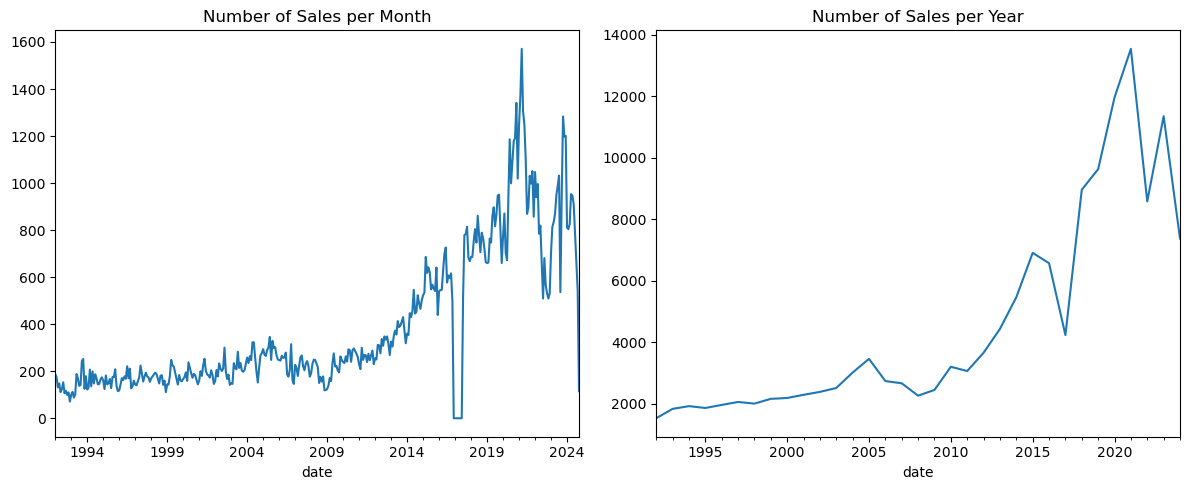

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

ts = df.set_index('date').resample('D').size()  # Daily counts of sales

# By month
ts_month = ts.resample('MS').sum()  # MS = month start
ts_month.plot(ax=axes[0])
axes[0].set_title('Number of Sales per Month')

# By year
ts_year = ts.resample('YS').sum()   # YS = year start
ts_year.plot(ax=axes[1])
axes[1].set_title('Number of Sales per Year')

plt.tight_layout()
plt.show()

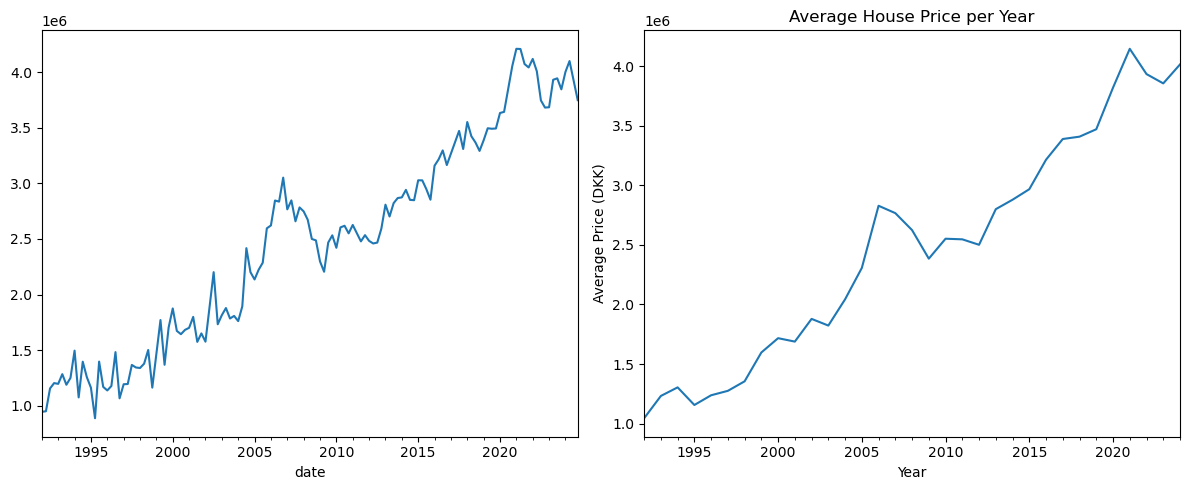

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
# Average house price per quarter
avg_price_quarter = df.groupby(df['date'].dt.to_period('Q'))['purchase_price'].mean()
avg_price_quarter.plot(ax=axes[0])
plt.title('Average House Price per Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Price (DKK)')
plt.tight_layout()



avg_price_year = df.groupby(df['date'].dt.to_period('Y'))['purchase_price'].mean()
avg_price_year.plot(ax=axes[1])
plt.title('Average House Price per Year')
plt.xlabel('Year')
plt.ylabel('Average Price (DKK)')
plt.tight_layout()
plt.show()

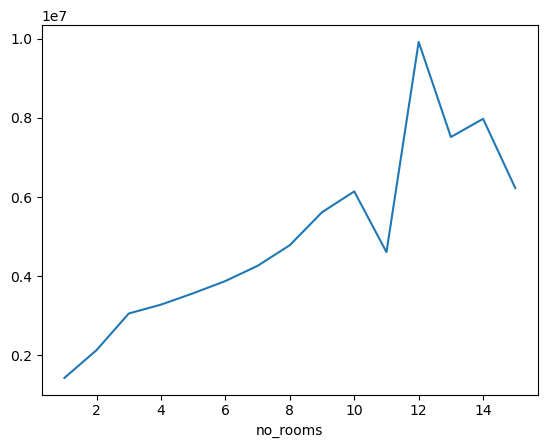

In [21]:
df.groupby('no_rooms')['purchase_price'].mean().plot();

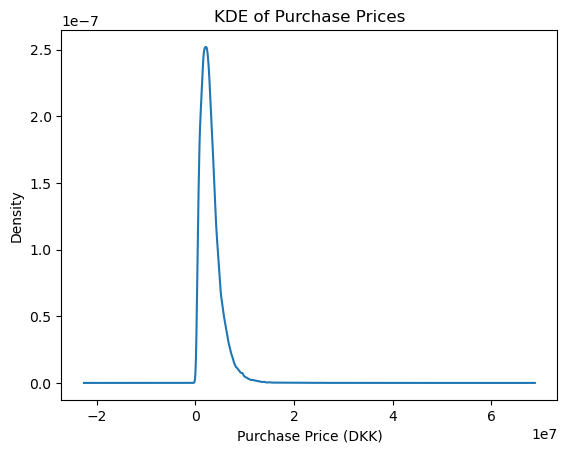

In [22]:
# KDE plot for purchase_price in 2024
df['purchase_price'].plot(kind='kde')
plt.title('KDE of Purchase Prices')
plt.xlabel('Purchase Price (DKK)')
plt.ylabel('Density')
plt.show()

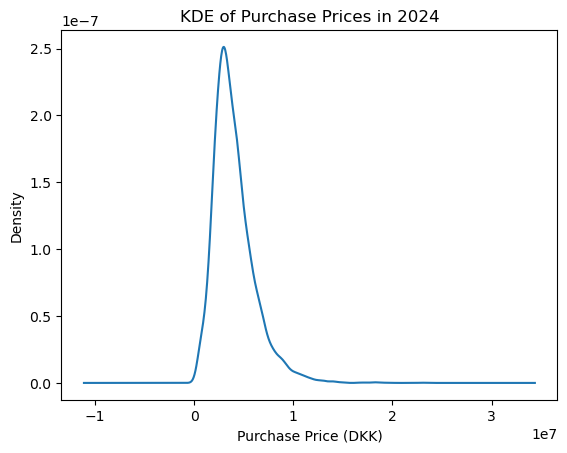

In [23]:
# KDE plot for purchase_price in 2024
df[df['date'] >= '2024-01-01']['purchase_price'].plot(kind='kde')
plt.title('KDE of Purchase Prices in 2024')
plt.xlabel('Purchase Price (DKK)')
plt.ylabel('Density')
plt.show()

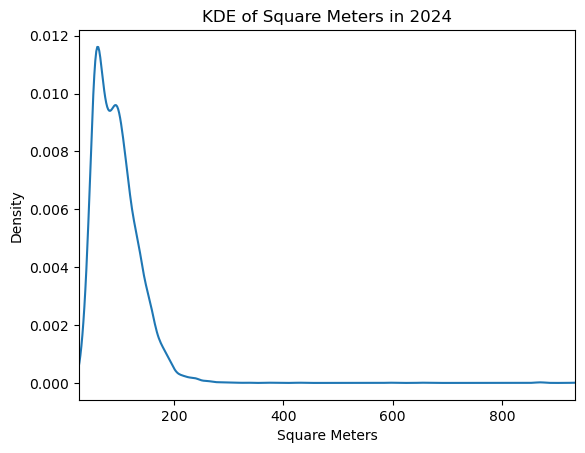

In [24]:
sqm_2024 = df[df['date'] >= '2024-01-01']['sqm']
lower, upper = sqm_2024.quantile([0, 1])
sqm_2024.plot(kind='kde')
plt.title('KDE of Square Meters in 2024')
plt.xlabel('Square Meters')
plt.ylabel('Density')
plt.xlim(lower, upper)
plt.show()

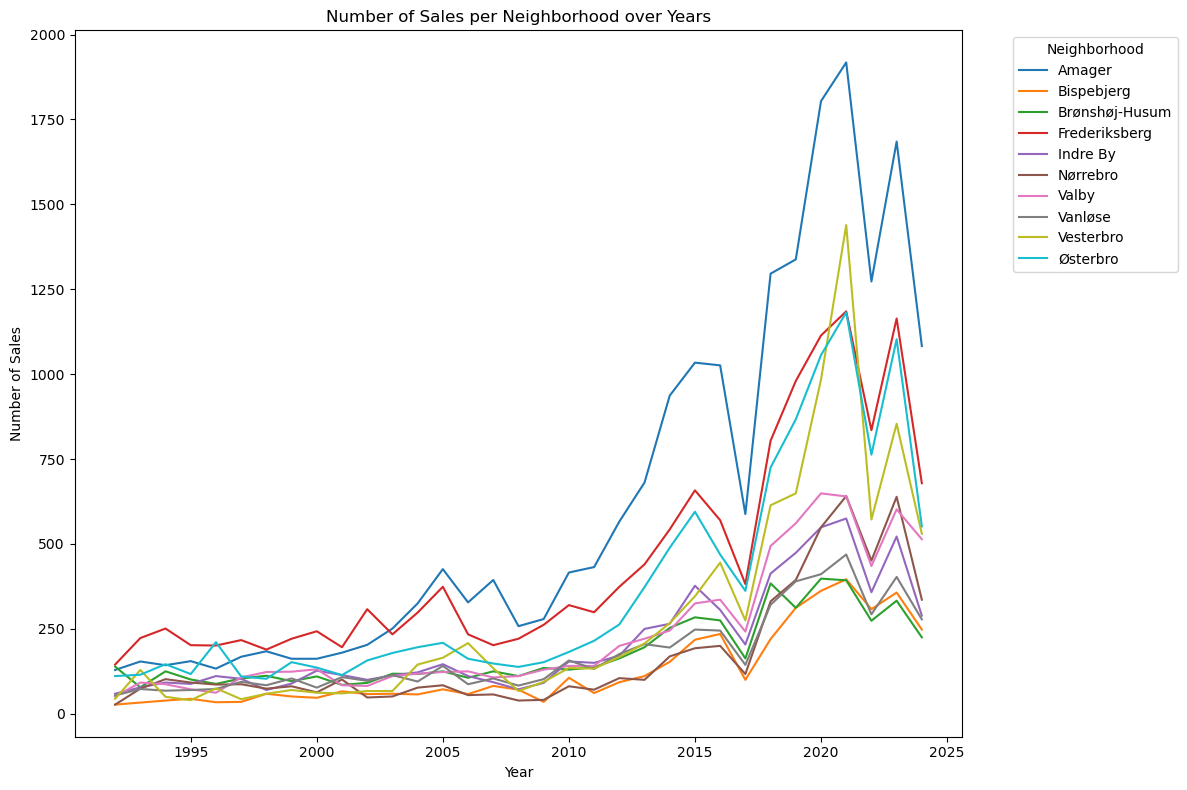

In [25]:
# Plot number of sales per neighborhood over the years

# Group by year and neighborhood, count the number of sales
sales_per_year_neigh = df.groupby([df['date'].dt.year, 'neighborhood']).size().unstack()

# Plot as line chart
sales_per_year_neigh.plot(kind='line', figsize=(12, 8))
plt.title('Number of Sales per Neighborhood over Years')
plt.xlabel('Year')
plt.ylabel('Number of Sales')
plt.legend(title='Neighborhood', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 1.2 Statistics Denmark socioeconomic panel
Load five Excel cross-tables from Statistics Denmark (Statistikbanken) and reshape from wide cross-tab format to tidy long format. Run quality checks on each tidy dataset (shape, missing values, duplicate keys, value ranges).

* *HISTORICAL:*
    * *POPULATION + PERSONS OF DANISH ORIGIN VS OTHER*
    * * KKBEF2: Population by district, sex, age and ancestry (yearly data) 
    * *AMOUNT UNEMPLOYED + DEGREE OF UNEMPLOYMENT + HIGHEST EDUCATION LEVEL:*
    * * KKLEDIG6: Unemployed (yearly) by district, degree of unemployment and highest education completed (yearly data) 
    * *TYPE OF HOUSE USE, OWNERSHIP, YEAR OF COMMISSION* _?SIZE in sqm?_
    * * KBOL3: Dwellings, square meters and residents by district, ownership, year of commissioning and type of use (yearly data) 
    * *INCOME, TYPE OF INCOME*
    * * KKIND3: Income for persons (14 years +) by district, unit, sex and type of income (yearly data) 
    * *TYPE OF HOUSEHOLD, NUMBER OF CHILDREN, HOUSEHOLD SIZE*
    * * KKHUS1: Households by district, type of household, number of children in the household and household size (!!! quaterly data) 

* *FUTURE:*
    * *POPULATION PROJECTION 2026-2060*
    * * KKFR2026: Population projection 2026 by district, sex and age (yearly)

In [26]:
# ============================================================
# 1) Paths
# Run from inside: mbml-cph-housing
# ============================================================
BASE = Path.cwd()

FILES = {
    "KKBEF2": BASE / "data" / "2026417213036619584456KKBEF2.xlsx",
    "KKLEDIG6": BASE / "data" / "2026417213155619584456KKLEDIG6.xlsx",
    "KKIND3": BASE / "data" / "202641721357619584456KKIND3.xlsx",
    "KKHUS1": BASE / "data" / "2026417214930619584456KKHUS1.xlsx",
    "KKFR2026": BASE / "data" / "2026417215628619584456KKFR2026.xlsx",
}

# ============================================================
# 2) File-specific layout
# These are based on the uploaded files you showed.
# ============================================================
CONFIG = {
    "KKBEF2": {
        "sheet_name": "KKBEF2",
        "header_row": 2,   # row with years
        "data_start_row": 3,
        "dim_names": ["ancestry", "age_group", "sex", "district"],
        "time_name": "year",
        "value_name": "value",
    },
    "KKLEDIG6": {
        "sheet_name": "KKLEDIG6",
        "header_row": 2,
        "data_start_row": 3,
        "dim_names": ["education", "unemployment_degree", "district"],
        "time_name": "year",
        "value_name": "value",
    },
    "KKIND3": {
        "sheet_name": "KKIND3",
        "header_row": 2,
        "data_start_row": 3,
        "dim_names": ["income_type", "sex", "unit", "district"],
        "time_name": "year",
        "value_name": "value",
    },
    "KKHUS1": {
        "sheet_name": "KKHUS1",
        "header_row": 2,   # row with quarter labels like 1998Q1
        "data_start_row": 3,
        "dim_names": ["household_size", "children_in_household", "household_type", "district"],
        "time_name": "quarter",
        "value_name": "value",
    },
    "KKFR2026": {
        "sheet_name": "KKFR2026",
        "header_row": 2,
        "data_start_row": 3,
        "dim_names": ["sex", "district", "age"],
        "time_name": "year",
        "value_name": "value",
    },
}

# ============================================================
# 3) Helpers
# ============================================================
def clean_text(x):
    """Standardize cell text while preserving real missing values."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in {"", "nan", "None", "NA", "N/A"}:
        return np.nan
    x = re.sub(r"\s+", " ", x)
    return x

def clean_district_name(x):
    """Optional cleanup for district labels."""
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = re.sub(r"^District\s*-\s*", "", x)
    return x

def parse_quarter_to_period(q):
    """
    Convert strings like 1998Q1 to pandas Period('1998Q1', freq='Q').
    If parsing fails, return original value.
    """
    if pd.isna(q):
        return np.nan
    q = str(q).strip()
    m = re.fullmatch(r"(\d{4})Q([1-4])", q)
    if m:
        year, quarter = m.groups()
        return pd.Period(f"{year}Q{quarter}", freq="Q")
    return q

def load_crosstab_excel(path, sheet_name, header_row, data_start_row, dim_names, time_name, value_name):
    """
    Read a Statistikbanken-style Excel cross table and reshape it to tidy long format.
    """
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # Clean all cells lightly
    raw = raw.applymap(clean_text)

    n_dims = len(dim_names)

    # Extract time labels from header row
    time_labels = raw.iloc[header_row, n_dims:].tolist()

    # Keep only rows that contain at least one non-missing value somewhere
    data = raw.iloc[data_start_row:, :].copy()
    data = data.dropna(how="all").reset_index(drop=True)

    # Rename columns
    data.columns = dim_names + time_labels

    # Forward-fill the dimension columns only
    data[dim_names] = data[dim_names].ffill()

    # Melt to long format
    tidy = data.melt(
        id_vars=dim_names,
        var_name=time_name,
        value_name=value_name
    )

    # Remove missing values in the measure column
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce")
    tidy = tidy.dropna(subset=[value_name]).reset_index(drop=True)

    # Clean dimension values
    for col in dim_names:
        tidy[col] = tidy[col].apply(clean_text)

    # District cleanup
    if "district" in tidy.columns:
        tidy["district"] = tidy["district"].apply(clean_district_name)

    # Convert time column
    if time_name == "year":
        tidy[time_name] = pd.to_numeric(tidy[time_name], errors="coerce").astype("Int64")
    elif time_name == "quarter":
        tidy[time_name] = tidy[time_name].apply(parse_quarter_to_period)

    # Final sort
    sort_cols = [c for c in dim_names + [time_name] if c in tidy.columns]
    tidy = tidy.sort_values(sort_cols).reset_index(drop=True)

    return tidy

# ============================================================
# 4) Load all files into tidy dataframes
# ============================================================
data = {}
summary = []

for name, path in FILES.items():
    cfg = CONFIG[name]

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    _sdf = load_crosstab_excel(
        path=path,
        sheet_name=cfg["sheet_name"],
        header_row=cfg["header_row"],
        data_start_row=cfg["data_start_row"],
        dim_names=cfg["dim_names"],
        time_name=cfg["time_name"],
        value_name=cfg["value_name"],
    )

    data[name] = _sdf

    summary.append({
        "dataset": name,
        "rows": len(_sdf),
        "columns": len(_sdf.columns),
        "time_column": cfg["time_name"],
        "min_time": str(_sdf[cfg["time_name"]].min()) if len(_sdf) else None,
        "max_time": str(_sdf[cfg["time_name"]].max()) if len(_sdf) else None,
    })

# ============================================================
# 5) Create direct dataframe variables
# ============================================================
KKBEF2 = data["KKBEF2"]
KKLEDIG6 = data["KKLEDIG6"]
KKIND3 = data["KKIND3"]
KKHUS1 = data["KKHUS1"]
KKFR2026 = data["KKFR2026"]

# ============================================================
# 6) Print overview
# ============================================================
summary_df = pd.DataFrame(summary)
print("Tidy datasets loaded:")
print(summary_df)

print("\nKKBEF2 sample:")
print(KKBEF2.head())

print("\nKKLEDIG6 sample:")
print(KKLEDIG6.head())

print("\nKKIND3 sample:")
print(KKIND3.head())

print("\nKKHUS1 sample:")
print(KKHUS1.head())

print("\nKKFR2026 sample:")
print(KKFR2026.head())

# ============================================================
# 7) Optional: save cleaned versions
# ============================================================
output_dir = BASE / "data" / "cleaned"
output_dir.mkdir(parents=True, exist_ok=True)

KKBEF2.to_csv(output_dir / "KKBEF2_tidy.csv", index=False)
KKLEDIG6.to_csv(output_dir / "KKLEDIG6_tidy.csv", index=False)
KKIND3.to_csv(output_dir / "KKIND3_tidy.csv", index=False)
KKHUS1.to_csv(output_dir / "KKHUS1_tidy.csv", index=False)
KKFR2026.to_csv(output_dir / "KKFR2026_tidy.csv", index=False)

print(f"\nCleaned CSV files saved to: {output_dir}")

/var/folders/wk/m7pktryd2zn74ff2_s1nkg9r0000gn/T/ipykernel_13095/2745412996.py:104: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
/var/folders/wk/m7pktryd2zn74ff2_s1nkg9r0000gn/T/ipykernel_13095/2745412996.py:104: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
/var/folders/wk/m7pktryd2zn74ff2_s1nkg9r0000gn/T/ipykernel_13095/2745412996.py:104: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
/var/folders/wk/m7pktryd2zn74ff2_s1nkg9r0000gn/T/ipykernel_13095/2745412996.py:104: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
/var/folders/wk/m7pktryd2zn74ff2_s1nkg9r0000gn/T/ipykernel_13095/2745412996.py:104: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)


Tidy datasets loaded:
    dataset   rows  columns time_column min_time max_time
0    KKBEF2  23194        6        year     1986     2025
1  KKLEDIG6   4800        5        year     2008     2023
2    KKIND3  11400        6        year     1987     2024
3    KKHUS1  76800        6     quarter   1998Q1   2024Q4
4  KKFR2026  70000        5        year     2026     2060

KKBEF2 sample:
                            ancestry   age_group  sex     district  year  \
0  Descendants of non-western origin  0-10 years  Men  Amager Vest  1986   
1  Descendants of non-western origin  0-10 years  Men  Amager Vest  1987   
2  Descendants of non-western origin  0-10 years  Men  Amager Vest  1988   
3  Descendants of non-western origin  0-10 years  Men  Amager Vest  1989   
4  Descendants of non-western origin  0-10 years  Men  Amager Vest  1990   

   value  
0  109.0  
1  136.0  
2  163.0  
3  168.0  
4  189.0  

KKLEDIG6 sample:
                           education unemployment_degree     district  ye

In [27]:
# Assumes these already exist from your load script:
# data, KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026

datasets = {
    "KKBEF2": KKBEF2,
    "KKLEDIG6": KKLEDIG6,
    "KKIND3": KKIND3,
    "KKHUS1": KKHUS1,
    "KKFR2026": KKFR2026,
}

for name, _sdf in datasets.items():
    print("=" * 80)
    print(f"{name}")
    print("=" * 80)

    print("\nShape:")
    print(_sdf.shape)

    print("\nColumns:")
    print(_sdf.columns.tolist())

    print("\nDtypes:")
    print(_sdf.dtypes)

    print("\nMissing values per column:")
    print(_sdf.isna().sum())

    print("\nExact duplicate rows:")
    print(_sdf.duplicated().sum())

    # Identify value and time columns
    value_col = "value"
    time_col = "quarter" if "quarter" in _sdf.columns else "year"

    # Dimension columns = everything except time and value
    dim_cols = [c for c in _sdf.columns if c not in [time_col, value_col]]

    print("\nDimension columns:")
    print(dim_cols)

    print("\nNumber of duplicated keys (same dimensions + same time):")
    print(_sdf.duplicated(subset=dim_cols + [time_col]).sum())

    print("\nValue summary:")
    print(_sdf[value_col].describe())

    print("\nNegative values count:")
    print((_sdf[value_col] < 0).sum())

    print("\nSample rows:")
    print(_sdf.head(10))

    print("\nUnique values per dimension column (first 15 shown):")
    for col in dim_cols:
        uniques = _sdf[col].dropna().unique()
        print(f"\n- {col}: {len(uniques)} unique")
        print(list(uniques[:15]))

    print("\nTime column summary:")
    print("Type:", _sdf[time_col].dtype)
    print("Min:", _sdf[time_col].min())
    print("Max:", _sdf[time_col].max())

    # Check if every key-time combination appears only once
    group_sizes = _sdf.groupby(dim_cols + [time_col]).size()
    bad_groups = group_sizes[group_sizes > 1]

    print("\nNumber of key-time combinations appearing more than once:")
    print(len(bad_groups))

    if len(bad_groups) > 0:
        print("\nFirst 10 duplicated key-time combinations:")
        print(bad_groups.head(10))

    print("\n")

KKBEF2

Shape:
(23194, 6)

Columns:
['ancestry', 'age_group', 'sex', 'district', 'year', 'value']

Dtypes:
ancestry      object
age_group     object
sex           object
district      object
year           Int64
value        float64
dtype: object

Missing values per column:
ancestry     0
age_group    0
sex          0
district     0
year         0
value        0
dtype: int64

Exact duplicate rows:
0

Dimension columns:
['ancestry', 'age_group', 'sex', 'district']

Number of duplicated keys (same dimensions + same time):
0

Value summary:
count    23194.000000
mean       906.619298
std       1484.900458
min          0.000000
25%         49.000000
50%        219.000000
75%       1096.000000
max      11420.000000
Name: value, dtype: float64

Negative values count:
0

Sample rows:
                            ancestry   age_group  sex     district  year  \
0  Descendants of non-western origin  0-10 years  Men  Amager Vest  1986   
1  Descendants of non-western origin  0-10 years  Men  Amage

In [28]:
for name, _sdf in datasets.items():
    time_col = "quarter" if "quarter" in _sdf.columns else "year"
    print(name, "->", _sdf[time_col].isna().sum(), "missing time values")

KKBEF2 -> 0 missing time values
KKLEDIG6 -> 0 missing time values
KKIND3 -> 0 missing time values
KKHUS1 -> 0 missing time values
KKFR2026 -> 0 missing time values


### 1.3 Build historical panel
Pivot each tidy dataset to wide format (district × year) and outer-merge into a single historical panel (1986–2025). Quarterly KKHUS1 household data is averaged to annual frequency before pivoting. The future population projections (KKFR2026, 2026–2060) are kept as a separate panel for use in Phase 6 forecasting.

In [29]:
# ============================================================
# Assumes these already exist from your tidy import script:
# KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026
# ============================================================

# ============================================================
# 1) Helpers
# ============================================================
def safe_slug(x):
    x = str(x).strip().lower()
    x = x.replace("&", "and")
    x = x.replace("%", "pct")
    x = x.replace("/", "_")
    x = x.replace("-", "_")
    x = x.replace(",", "")
    x = x.replace(".", "")
    x = x.replace("(", "")
    x = x.replace(")", "")
    x = x.replace(":", "")
    x = x.replace("'", "")
    x = x.replace('"', "")
    x = "_".join(x.split())
    while "__" in x:
        x = x.replace("__", "_")
    return x

def flatten_columns(columns):
    flat = []
    for col in columns:
        if isinstance(col, tuple):
            parts = [safe_slug(c) for c in col if c not in [None, "", "nan"]]
            flat.append("_".join(parts))
        else:
            flat.append(safe_slug(col))
    return flat

def make_wide(_sdf, id_cols, category_cols, value_col, prefix):
    """
    Converts tidy long _sdf into district-year wide format.
    """
    out = _sdf.copy()

    # Ensure clean types
    out = out.dropna(subset=id_cols + category_cols + [value_col]).copy()

    # Pivot to wide
    wide = out.pivot_table(
        index=id_cols,
        columns=category_cols,
        values=value_col,
        aggfunc="sum"
    ).reset_index()

    # Flatten multiindex columns
    wide.columns = id_cols + [
        f"{prefix}_" + "_".join([safe_slug(x) for x in col]) if isinstance(col, tuple) else f"{prefix}_{safe_slug(col)}"
        for col in wide.columns[len(id_cols):]
    ]

    return wide

# ============================================================
# 2) Standardize district/year formats
# ============================================================
KKBEF2 = KKBEF2.copy()
KKLEDIG6 = KKLEDIG6.copy()
KKIND3 = KKIND3.copy()
KKHUS1 = KKHUS1.copy()
KKFR2026 = KKFR2026.copy()

for _sdf in [KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026]:
    if "district" in _sdf.columns:
        _sdf["district"] = _sdf["district"].astype(str).str.strip()

if "year" in KKBEF2.columns:
    KKBEF2["year"] = pd.to_numeric(KKBEF2["year"], errors="coerce").astype("Int64")
if "year" in KKLEDIG6.columns:
    KKLEDIG6["year"] = pd.to_numeric(KKLEDIG6["year"], errors="coerce").astype("Int64")
if "year" in KKIND3.columns:
    KKIND3["year"] = pd.to_numeric(KKIND3["year"], errors="coerce").astype("Int64")
if "year" in KKFR2026.columns:
    KKFR2026["year"] = pd.to_numeric(KKFR2026["year"], errors="coerce").astype("Int64")

# Convert quarter -> year for housing
if "quarter" in KKHUS1.columns:
    if str(KKHUS1["quarter"].dtype) == "period[Q-DEC]":
        KKHUS1["year"] = KKHUS1["quarter"].dt.year.astype("Int64")
    else:
        KKHUS1["year"] = (
            KKHUS1["quarter"]
            .astype(str)
            .str.extract(r"(\d{4})", expand=False)
            .pipe(pd.to_numeric, errors="coerce")
            .astype("Int64")
        )

# ============================================================
# 3) Aggregate quarterly housing to annual mean
# ============================================================
KKHUS1_yearly = (
    KKHUS1
    .groupby(["household_size", "children_in_household", "household_type", "district", "year"], as_index=False)["value"]
    .mean()
)

# ============================================================
# 4) Pivot each dataset to district-year wide format
# ============================================================
KKBEF2_wide = make_wide(
    _sdf=KKBEF2,
    id_cols=["district", "year"],
    category_cols=["ancestry", "age_group", "sex"],
    value_col="value",
    prefix="pop"
)

KKLEDIG6_wide = make_wide(
    _sdf=KKLEDIG6,
    id_cols=["district", "year"],
    category_cols=["education", "unemployment_degree"],
    value_col="value",
    prefix="unemp"
)

KKIND3_wide = make_wide(
    _sdf=KKIND3,
    id_cols=["district", "year"],
    category_cols=["income_type", "sex", "unit"],
    value_col="value",
    prefix="income"
)

KKHUS1_wide = make_wide(
    _sdf=KKHUS1_yearly,
    id_cols=["district", "year"],
    category_cols=["household_size", "children_in_household", "household_type"],
    value_col="value",
    prefix="housing"
)

KKFR2026_wide = make_wide(
    _sdf=KKFR2026,
    id_cols=["district", "year"],
    category_cols=["sex", "age"],
    value_col="value",
    prefix="proj_pop"
)

# ============================================================
# 5) Merge historical datasets
# Use outer merge to keep all district-year combinations
# ============================================================
historical_panel = KKBEF2_wide.merge(
    KKLEDIG6_wide, on=["district", "year"], how="outer"
).merge(
    KKIND3_wide, on=["district", "year"], how="outer"
).merge(
    KKHUS1_wide, on=["district", "year"], how="outer"
)

historical_panel = historical_panel.sort_values(["district", "year"]).reset_index(drop=True)

# ============================================================
# 6) Keep future population projections separate
# Since only KKFR2026 covers future years
# ============================================================
future_population_panel = KKFR2026_wide.sort_values(["district", "year"]).reset_index(drop=True)

# ============================================================
# 7) Optional combined panel
# This appends future projections to historical data structure
# Most future columns will be NaN except projected population
# ============================================================
combined_panel = historical_panel.merge(
    future_population_panel, on=["district", "year"], how="outer"
).sort_values(["district", "year"]).reset_index(drop=True)

# ============================================================
# 8) Diagnostics
# ============================================================
print("=" * 80)
print("HISTORICAL PANEL")
print("=" * 80)
print("Shape:", historical_panel.shape)
print("Years:", historical_panel["year"].min(), "to", historical_panel["year"].max())
print("Districts:", historical_panel["district"].nunique())
print("Duplicated district-year rows:", historical_panel.duplicated(subset=["district", "year"]).sum())
print(historical_panel.head())

print("\n" + "=" * 80)
print("FUTURE POPULATION PANEL")
print("=" * 80)
print("Shape:", future_population_panel.shape)
print("Years:", future_population_panel["year"].min(), "to", future_population_panel["year"].max())
print("Districts:", future_population_panel["district"].nunique())
print("Duplicated district-year rows:", future_population_panel.duplicated(subset=["district", "year"]).sum())
print(future_population_panel.head())

print("\n" + "=" * 80)
print("COMBINED PANEL")
print("=" * 80)
print("Shape:", combined_panel.shape)
print("Years:", combined_panel["year"].min(), "to", combined_panel["year"].max())
print("Districts:", combined_panel["district"].nunique())
print("Duplicated district-year rows:", combined_panel.duplicated(subset=["district", "year"]).sum())
print(combined_panel.head())

# ============================================================
# 9) Save outputs
# ============================================================
BASE = Path.cwd()
output_dir = BASE / "data" / "cleaned"
output_dir.mkdir(parents=True, exist_ok=True)

historical_panel.to_csv(output_dir / "historical_panel_merged.csv", index=False)
future_population_panel.to_csv(output_dir / "future_population_panel.csv", index=False)
combined_panel.to_csv(output_dir / "combined_panel_with_future_population.csv", index=False)

print(f"\nSaved to: {output_dir}")
print("- historical_panel_merged.csv")
print("- future_population_panel.csv")
print("- combined_panel_with_future_population.csv")

HISTORICAL PANEL
Shape: (400, 212)
Years: 1986 to 2025
Districts: 10
Duplicated district-year rows: 0
      district  year  pop_descendants_of_non_western_origin_0_10_years_men  \
0  Amager Vest  1986                                              109.0      
1  Amager Vest  1987                                              136.0      
2  Amager Vest  1988                                              163.0      
3  Amager Vest  1989                                              168.0      
4  Amager Vest  1990                                              189.0      

   pop_descendants_of_non_western_origin_0_10_years_women  \
0                                              129.0        
1                                              143.0        
2                                              154.0        
3                                              182.0        
4                                              185.0        

   pop_descendants_of_non_western_origin_10_19_years_men  \
0 

## Phase 2 - Feature Engineering
Goal - Transform raw inputs into the district × year panel that feeds the Pyro model

### 2.1 Aggregate housing prices to district-year level

The housing dataset contains one row per *transaction*. The Bayesian model needs one representative
price signal per *district per year*. The cell below collapses ~91,000 regular-sale transactions
into a compact panel.

Section 2.1: Target Variable Design (Median Log SQM Price)

In this phase, we aggregate raw transaction data into a robust target variable suitable for Bayesian modeling. The following design choices ground our approach:

* **Price per Square Meter ($sqm\_price$):** Normalizes for property size, allowing the model to compare the intrinsic value of different locations regardless of whether they feature small studios or large houses.
* **Median Aggregation:** We use the median rather than the mean to provide robustness against extreme outliers and luxury sales, ensuring the target reflects the "typical" market value of a district.
* **Log-Transformation ($log\_sqm\_price$):** This choice satisfies the **Gaussian likelihood** assumption of our observation model ($y_{dt} \sim Normal(\mu, \sigma)$). It also transforms skewed price distributions into more symmetric ones and improves numerical stability during inference.
* **Heteroskedastic Noise ($\sigma_{obs}$):** We calculate the standard deviation of log-prices (`std_log_sqm_price`) for each district-year. In the Pyro model, this is treated as **observed noise**, allowing the model to weigh consistent market years more heavily than highly volatile ones.

**Design choices:**

| Choice | Reason |
|---|---|
| **Regular sales only** | Family sales (`family_sale`) are transfers between relatives at below-market prices — they reflect family agreements, not the market. Auctions and other sale types have different dynamics. Including them would bias the price signal downward and add noise. |
| **`log(sqm_price)` before aggregating** | Housing prices are right-skewed and span roughly 5× across districts. The log transformation makes the distribution approximately Gaussian and matches the **log-normal likelihood** the Pyro model will use. `median(log(x)) = log(median(x))` by monotonicity of log, so the two orderings are equivalent for the median. |
| **Median, not mean** | The median is robust to the occasional extreme transaction (luxury penthouses, distressed sales) that would pull the mean upward. |
| **`std_log_sqm_price` (within-cell std)** | Measures how *consistent* prices are within a district-year cell. A cell with high variance (few transactions or mixed property types) carries more measurement uncertainty. In Pyro this becomes **σ_obs** — the observation noise, giving data-informed weights: cells with consistent prices constrain the posterior more tightly than cells with scattered prices. |
| **`n_transactions`** | Sample size per cell. Small-n cells (< 10 transactions) produce unreliable medians and inflated standard deviations. Flagged in the diagnostics below. |
| **`pct_change_median`** | Median percentage change between listing price and final purchase price. A proxy for *market tightness*: negative = buyer's market (sellers discount), positive = seller's market (bidding wars). Useful as a model covariate, but may correlate with the interest rate already

### 2.1 Housing price aggregation and log-price target

Shape: (330, 10)

Year coverage per district:
                 min   max  count
district                         
Amager          1992  2024     33
Bispebjerg      1992  2024     33
Brønshøj-Husum  1992  2024     33
Frederiksberg   1992  2024     33
Indre By        1992  2024     33
Nørrebro        1992  2024     33
Valby           1992  2024     33
Vanløse         1992  2024     33
Vesterbro       1992  2024     33
Østerbro        1992  2024     33

District-years with fewer than 10 transactions:
Empty DataFrame
Columns: [district, year, median_log_sqm_price, mean_log_sqm_price, std_log_sqm_price, n_transactions, median_sqm, median_purchase_price, pct_change_median, sem_log_sqm_price]
Index: []


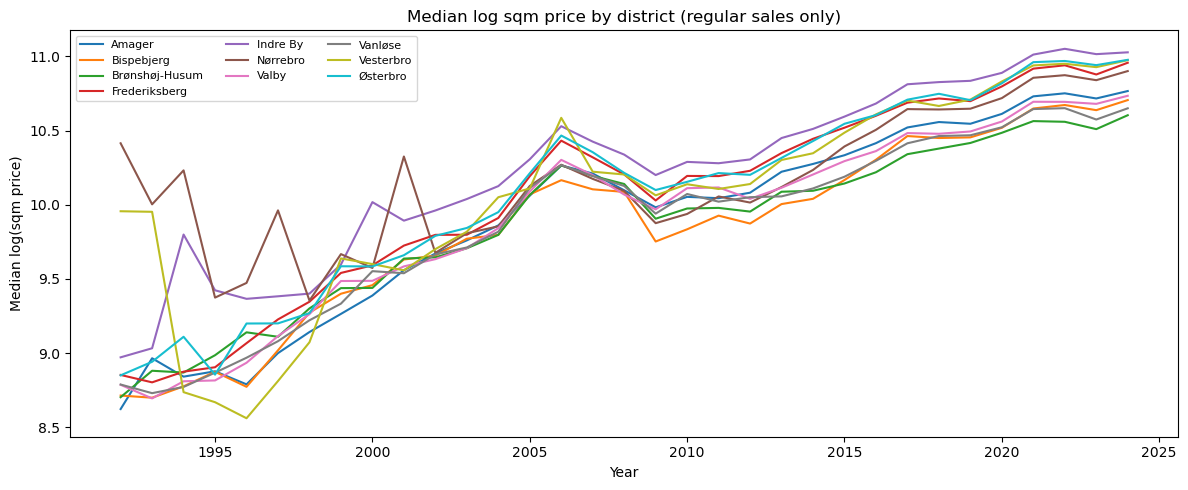


Saved: data/cleaned/housing_agg_district_year.csv


In [30]:
# Adding a filter for regular sales only, mapped district, and valid sqm_price
mask = (
    df['neighborhood'].notna() & 
    (df['sales_type'] == 'regular_sale') &
    df['sqm_price'].notna() &
    (df['sqm_price'] > 0)
) 

# Apply the filter to the dataframe
df_filtered = df[mask].copy()

df_filtered['year'] = df_filtered['date'].dt.year
df_filtered['log_sqm_price'] = np.log(df_filtered['sqm_price'])

# Aggregate to district × year level
housing_agg = (
    df_filtered.groupby(['neighborhood', 'year'])
    .agg(
        median_log_sqm_price   = ('log_sqm_price', 'median'),
        mean_log_sqm_price     = ('log_sqm_price', 'mean'),
        std_log_sqm_price      = ('log_sqm_price', 'std'),
        n_transactions         = ('sqm_price', 'count'),
        median_sqm             = ('sqm', 'median'),
        median_purchase_price  = ('purchase_price', 'median'),
        pct_change_median      = ('%_change_between_offer_and_purchase', 'median')
    )
    .reset_index()
    .rename(columns={'neighborhood': 'district'})
)

# Standard Error of the Median for each district-year cell.
# The asymptotic constant 1.253 converts the sample std to an estimate
# of the sampling uncertainty of the median (vs the mean, which uses 1/sqrt(N)).
# This is used as sigma_obs in the Pyro model so that a district-year with
# 10 transactions carries less weight than one with 1000.
housing_agg['sem_log_sqm_price'] = (
    1.253 * housing_agg['std_log_sqm_price'] / np.sqrt(housing_agg['n_transactions'])
)

print('Shape:', housing_agg.shape)
print('\nYear coverage per district:')
print(housing_agg.groupby('district')['year'].agg(['min', 'max', 'count']))
print('\nDistrict-years with fewer than 10 transactions:')
print(housing_agg[housing_agg['n_transactions'] < 10])

fig, ax = plt.subplots(figsize=(12, 5))
for d_name, grp in housing_agg.groupby('district'):
    ax.plot(grp['year'], grp['median_log_sqm_price'], label=d_name, linewidth=1.5)
ax.set_title('Median log sqm price by district (regular sales only)')
ax.set_xlabel('Year')
ax.set_ylabel('Median log(sqm price)')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

housing_agg.to_csv('data/cleaned/housing_agg_district_year.csv', index=False)
print('\nSaved: data/cleaned/housing_agg_district_year.csv')

### 2.2 Align district names and collapse Amager sub-districts

Before the two datasets can be joined, their district names must match exactly.
The housing dataset uses simplified informal names (from the zip-code mapping);
Statistics Denmark uses official administrative names.

Three issues to resolve:

1. **`Vesterbro` → `Vesterbro/Kongens Enghave`** — the full administrative name includes Kongens Enghave
2. **Drop `Frederiksberg`** — Frederiksberg is an independent municipality
3. **Collapse `Amager Øst` + `Amager Vest` → `Amager`** — zip code 2300 spans both sub-districts. We aggregate the two Statistics Denmark rows into one by summing. Summing is correct because all panel columns are count-type totals (population headcounts, unemployment counts, income totals in DKK 1,000). Per-capita derived features (e.g. income per capita) will be computed as `sum(income) / sum(population)` in Phase 2.5, which gives the correct combined-district average.

In [31]:
# Load the historical panel (socioeconomic features from Statistikbanken) that we created in Phase 1 
historical_panel = pd.read_csv('data/cleaned/historical_panel_merged.csv')

print("Aggrigated housing data districts:   ", sorted(housing_agg['district'].unique()))
print("Historical socioeconomic panel districts: ", sorted(historical_panel['district'].unique()))

# -- Part 1: rename districts in housing_agg to match historical_panel
# Vesterbro → matches panel name; Amager stays as-is (we fix the panel side)
housing_agg['district'] = housing_agg['district'].replace(
    {'Vesterbro': 'Vesterbro/Kongens Enghave'}
)
# Frederiksberg is a separate municipality — not in Statistics Denmark tables -> drop it from housing_agg
housing_agg = housing_agg[housing_agg['district'] != 'Frederiksberg'].copy() 

# -- Part 2: sum Amager Øst & Vest in the panel to match the housing data (which has them combined as Amager)
#  # zip 2300 covers both sub-districts, so housing transactions cannot be split)
# All panel columns are count-type → sum is the correct aggregation.
amager_rows = historical_panel[historical_panel['district'].isin(['Amager Øst', 'Amager Vest'])]
amager_combined = (
    amager_rows
    .drop(columns=['district']) # drop old district column
    .groupby('year', as_index=False) # group by year to sum the two sub-districts
    .sum(numeric_only=True) # sum only numeric columns, keep 'year' as-is
)
amager_combined.insert(0, 'district', 'Amager') # add new district column with combined name

# Drop old rows and append combined Amager
historical_panel = pd.concat([
    historical_panel[~historical_panel['district'].isin(['Amager Øst', 'Amager Vest'])],
    amager_combined
], ignore_index=True).sort_values(['district', 'year']).reset_index(drop=True)

# -- Verify final district alignment
agg_dists = set(housing_agg['district'].unique())
panel_dists = set(historical_panel['district'].unique())
unmatched = agg_dists.symmetric_difference(panel_dists)

if unmatched:
    print("\nWarning: Unmatched districts after cleaning:", unmatched)
else:
    print("\nSuccess: Districts are aligned between datasets.")

# Save the cleaned historical panel for modeling
housing_agg.to_csv('data/cleaned/housing_agg_district_year.csv', index=False)
historical_panel.to_csv('data/cleaned/historical_panel_merged_aligned.csv', index=False)
print("\nSaved: housing_agg_district_year.csv  (aligned)")
print("Saved: historical_panel_merged_aligned.csv")

Aggrigated housing data districts:    ['Amager', 'Bispebjerg', 'Brønshøj-Husum', 'Frederiksberg', 'Indre By', 'Nørrebro', 'Valby', 'Vanløse', 'Vesterbro', 'Østerbro']
Historical socioeconomic panel districts:  ['Amager Vest', 'Amager Øst', 'Bispebjerg', 'Brønshøj-Husum', 'Indre By', 'Nørrebro', 'Valby', 'Vanløse', 'Vesterbro/Kongens Enghave', 'Østerbro']

Success: Districts are aligned between datasets.

Saved: housing_agg_district_year.csv  (aligned)
Saved: historical_panel_merged_aligned.csv


### 2.3 Join raw transactions (`df`) with `historical_panel`

Left-join **each sale** in `df` to the **district–year** socioeconomic panel on `(district, year)` (same district naming as `housing_agg`: `neighborhood` → `district`, Vesterbro rename). Rows without a mappable district are dropped before the join.

**Two outputs:**

| DataFrame | Years | Purpose |
|-----------|-------|---------|
| `model_panel_ungrouped` | All years present in `df` that match keys in `historical_panel` | Full horizon; pre-2008 rows can have missing unemployment breakdowns in the panel (same issue as `model_panel_full`). |
| `model_panel_ungrouped_restricted` | **year ≥ 2008** | Matches the **KKLEDIG6** availability window — comparable spirit to `model_panel_restricted` for analyses that need complete unemployment covariates. |


In [32]:
_tx = df.copy()
_tx["year"] = _tx["date"].dt.year
_tx["district"] = _tx["neighborhood"].replace(
    {"Vesterbro": "Vesterbro/Kongens Enghave"}
)
_tx = _tx.dropna(subset=["neighborhood", "district", "year"], how="any")
_tx = _tx.loc[_tx["district"].astype(str).str.strip().ne("")].copy()

_hp = historical_panel.set_index(["district", "year"])

model_panel_ungrouped = (
    _tx.set_index(["district", "year"])
    .join(_hp, how="left")
    .reset_index()
)

model_panel_ungrouped_restricted = model_panel_ungrouped.loc[
    model_panel_ungrouped["year"] >= 2008
].copy()

print("model_panel_ungrouped:", model_panel_ungrouped.shape)
print("model_panel_ungrouped_restricted:", model_panel_ungrouped_restricted.shape)


model_panel_ungrouped: (91553, 227)
model_panel_ungrouped_restricted: (72176, 227)


#### Checking whether "sqm_price" in dataframe model_panel_ungrouped_restricted follows a normal distribution: 

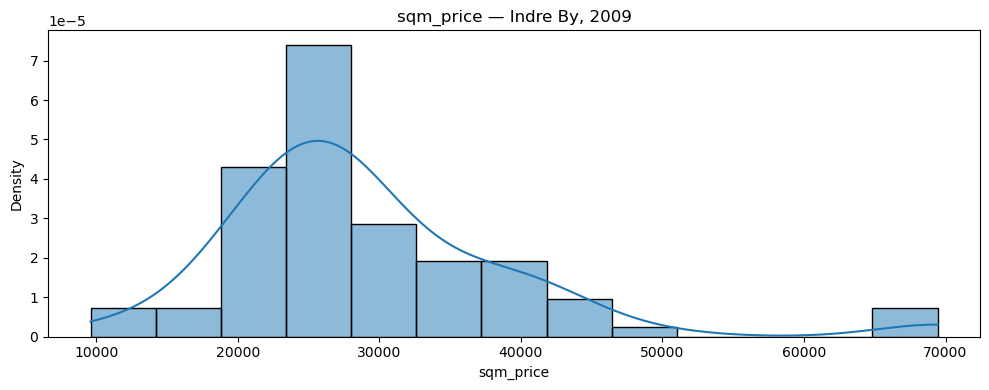

n = 91


In [33]:
district = "Indre By"   # change
year = 2009             # change

sub = model_panel_ungrouped_restricted[
    (model_panel_ungrouped_restricted["district"] == district)
    & (model_panel_ungrouped_restricted["year"] == year)
]

x = sub["sqm_price"].dropna()
if x.empty:
    raise ValueError(f"No rows for district={district!r}, year={year}")

fig, ax = plt.subplots(figsize=(10, 4))

sns.histplot(x, kde=True, stat="density", ax=ax)
ax.set_title(f"sqm_price — {district}, {year}")

plt.tight_layout()
plt.show()

print("n =", len(x))

Finding multimodal district year combinations:

In [34]:
def kde_n_modes(x, min_n=80, grid_n=400, prominence_frac=0.05):
    """
    Number of local maxima in a Gaussian KDE of x.
    prominence_frac: peak must stand out by this fraction of max(pdf) (reduces noise modes).
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < min_n:
        return np.nan
    if np.ptp(x) < 1e-12:
        return 1
    kde = gaussian_kde(x)
    lo, hi = float(np.min(x)), float(np.max(x))
    pad = max((hi - lo) * 0.08, 1e-6)
    y_grid = np.linspace(lo - pad, hi + pad, int(grid_n))
    pdf = kde(y_grid)
    prom = prominence_frac * float(np.max(pdf))
    peaks, _ = find_peaks(pdf, prominence=prom)
    return int(peaks.size)


df = model_panel_ungrouped_restricted[["district", "year", "sqm_price"]].dropna()

rows = []
for (d, y), sub in df.groupby(["district", "year"], sort=True):
    xp = sub["sqm_price"].to_numpy()
    nm = kde_n_modes(xp)
    rows.append(
        {
            "district": d,
            "year": y,
            "n": int(xp.size),
            "kde_n_modes": nm,
        }
    )

mode_tbl = pd.DataFrame(rows)
mode_tbl["multimodal_kde"] = mode_tbl["kde_n_modes"] >= 2

multimodal_only = mode_tbl.loc[mode_tbl["multimodal_kde"], ["district", "year", "n", "kde_n_modes"]].sort_values(
    ["district", "year"], ignore_index=True
)

print(f"Multimodal district–year cells (KDE, sqm_price): {len(multimodal_only)}")
if multimodal_only.empty:
    print("(none)")
else:
    with pd.option_context("display.max_rows", None, "display.width", 200):
        print(multimodal_only.to_string(index=False))

# mode_tbl.to_csv("data/cleaned/district_year_sqm_price_kde_modes.csv", index=False)

Multimodal district–year cells (KDE, sqm_price): 23
                 district  year    n  kde_n_modes
                   Amager  2014  937          2.0
               Bispebjerg  2023  357          2.0
            Frederiksberg  2022  835          2.0
            Frederiksberg  2023 1164          2.0
                 Indre By  2011  150          2.0
                 Indre By  2018  413          2.0
                 Indre By  2019  474          2.0
                 Indre By  2020  549          2.0
                 Indre By  2021  575          2.0
                 Indre By  2022  358          2.0
                 Indre By  2023  522          2.0
                 Nørrebro  2010   81          2.0
                 Nørrebro  2019  394          2.0
                 Nørrebro  2020  549          2.0
                 Nørrebro  2021  641          2.0
                 Nørrebro  2022  451          2.0
                 Nørrebro  2023  639          2.0
                    Valby  2024  514          2.

In [35]:
model_panel_ungrouped_restricted["district"]

0        Vesterbro/Kongens Enghave
1                    Frederiksberg
2                   Brønshøj-Husum
3                           Amager
4                           Amager
                   ...            
72171                Frederiksberg
72172                       Amager
72173                       Amager
72174    Vesterbro/Kongens Enghave
72175                Frederiksberg
Name: district, Length: 72176, dtype: object

### 2.4 Join housing aggregates with the socioeconomic panel

Merge the district-year housing aggregates with the Statistics Denmark historical panel
on the composite key `(district, year)` using an **inner join** — only district-years that
appear in *both* datasets are kept.

**Two output versions are produced:**

| Version | Years | Rows | Purpose |
|---|---|---|---|
| `model_panel_full` | all available (~1992–2024) | ~297 | Reference; some columns are NaN before 2008 |
| `model_panel_restricted` | 2008–2024 | ~153 | **Used for Pyro model fitting** — all covariate groups complete |

The 2008 cutoff is driven by KKLEDIG6 (unemployment by education level), which Statistics Denmark
only provides from 2008 onward.

**IF WE WANT TO INCLUDE A LONGER TIME-FRAME -> WE CAN TAKE UNEMPLOYMENT OUT**

Modeling panel shape: (297, 220)

Modeling panel year coverage per district:
                            min   max  count
district                                    
Amager                     1992  2024     33
Bispebjerg                 1992  2024     33
Brønshøj-Husum             1992  2024     33
Indre By                   1992  2024     33
Nørrebro                   1992  2024     33
Valby                      1992  2024     33
Vanløse                    1992  2024     33
Vesterbro/Kongens Enghave  1992  2024     33
Østerbro                   1992  2024     33

Nulls in key columns:
district                0
year                    0
median_log_sqm_price    0
n_transactions          0
dtype: int64


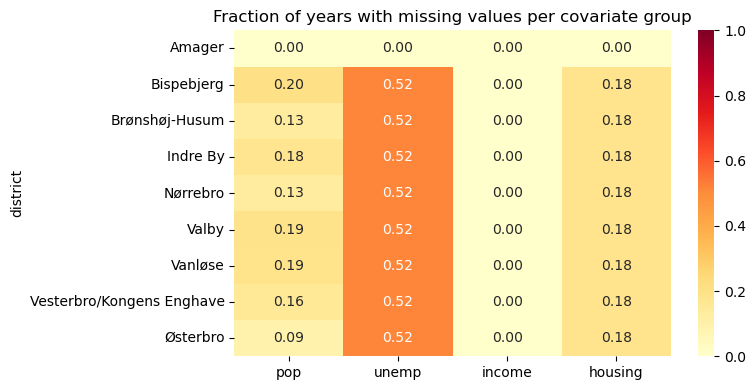


Full panel:        297 rows, years 1992–2024
Restricted panel:  153 rows, years 2008–2024


In [36]:
# Creating combined dataset for modelling 
# -- Inner join on district * year to keep only rows where we have both housing and socioeconomic data -- 
model_panel = housing_agg.merge(historical_panel, on=['district', 'year'], how='inner')

# Check the shape and coverage of the final modeling panel
print("Modeling panel shape:", model_panel.shape)
print("\nModeling panel year coverage per district:")
print(model_panel.groupby('district')['year'].agg(['min', 'max', 'count']))
print("\nNulls in key columns:")
print(model_panel[['district', 'year', 'median_log_sqm_price', 'n_transactions']].isnull().sum())

# Missing values by covariate group 
#   (we want to check if missingness is concentrated in certain districts or years, which could bias our model)
prefixes = ['pop', 'unemp', 'income', 'housing']
covariate_cols = [col for col in model_panel.columns if any(col.startswith(p) for p in prefixes)]

miss_frac = model_panel.groupby('district')[covariate_cols].apply(lambda df: df.isnull().mean())

miss_by_prefix = {}
for pfx in prefixes:
    cols = [col for col in covariate_cols if col.startswith(pfx)]
    if cols:
        miss_by_prefix[pfx.rstrip('_')] = miss_frac[cols].mean(axis=1)

miss_summary = pd.DataFrame(miss_by_prefix)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(miss_summary, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('Fraction of years with missing values per covariate group')
plt.tight_layout()
plt.show()

# ── Two panel versions ────────────────────────────────────────────────────────
# Full panel: all available years (unemp_ columns will be NaN before 2008)
# Restricted: year >= 2008 — all covariate groups complete, used for model fitting
model_panel_full       = model_panel.copy()
model_panel_restricted = model_panel[model_panel['year'] >= 2008].copy()

model_panel_full.to_csv('data/cleaned/model_panel_full.csv', index=False)
model_panel_restricted.to_csv('data/cleaned/model_panel_restricted.csv', index=False)

print(f"\nFull panel:       {model_panel_full.shape[0]:4d} rows, "
      f"years {model_panel_full['year'].min()}–{model_panel_full['year'].max()}")
print(f"Restricted panel: {model_panel_restricted.shape[0]:4d} rows, "
      f"years 2008–{model_panel_restricted['year'].max()}")

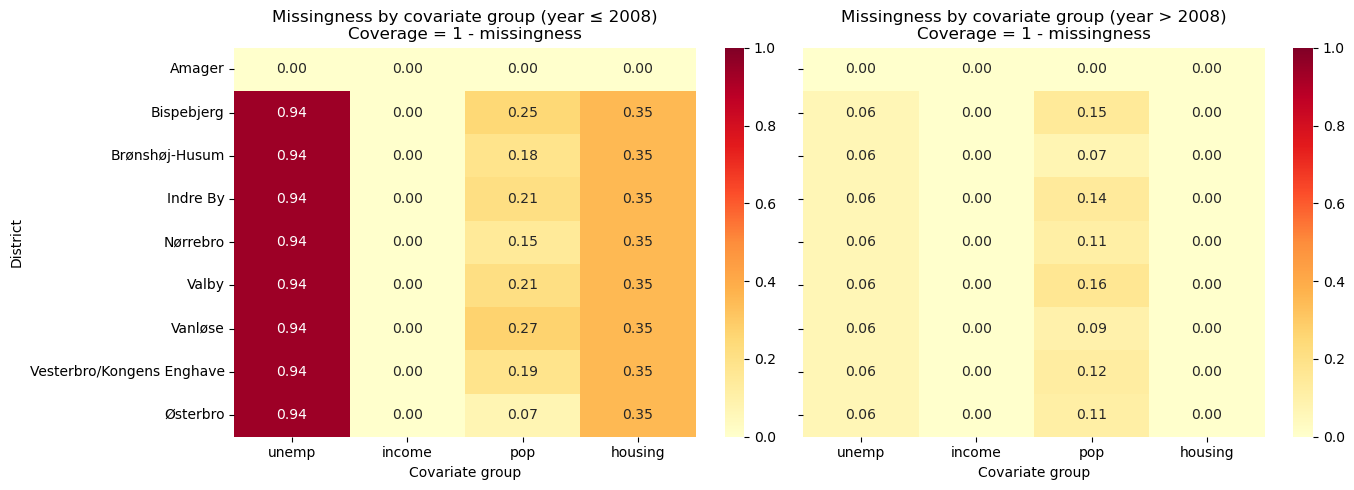

In [37]:
panel = model_panel_full.copy() if "model_panel_full" in globals() else model_panel.copy()

prefixes = ['unemp_', 'income_', 'pop_', 'housing_']
covariate_cols = [c for c in panel.columns if any(c.startswith(p) for p in prefixes)]

def missing_by_group(df_period):
    miss_frac = df_period.groupby('district')[covariate_cols].apply(lambda g: g.isnull().mean())
    out = {}
    for pfx in prefixes:
        cols = [c for c in covariate_cols if c.startswith(pfx)]
        if cols:
            out[pfx.rstrip('_')] = miss_frac[cols].mean(axis=1)
    return pd.DataFrame(out).sort_index()

miss_pre  = missing_by_group(panel[panel['year'] <= 2008])
miss_post = missing_by_group(panel[panel['year'] > 2008])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.heatmap(miss_pre, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Missingness by covariate group (year ≤ 2008)\nCoverage = 1 - missingness')
axes[0].set_xlabel('Covariate group')
axes[0].set_ylabel('District')

sns.heatmap(miss_post, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Missingness by covariate group (year > 2008)\nCoverage = 1 - missingness')
axes[1].set_xlabel('Covariate group')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 2.5 Reduce covariates to 5-8 summary features
**Why is this necessary?** 

Curse of Dimensionality & Multicollinearity: Currently have around 200 columns (e.g., population counts broken down by every 10-year age bracket and gender. We reduce the ~200 wide columns into 5-8 meaningful, standardized summary features to ensure our Pyro model remains interpretable and computationally stable.

**Design choices**

| Feature | Derivation / Source | Design Rationale & Logic |
| :--- | :--- | :--- |
| **`log_total_population`** | Natural log of the sum of all `pop_*` columns (KKBEF2) | Population is used as the base for **per-capita normalization**. We log it because the relationship between district size and price is multiplicative, not additive — doubling the population does not double the price level linearly. Log linearizes this effect and compresses the 5–10× range across CPH districts, matching the log-normal structure of the target variable. The log is equivalent to converting a size effect into a *relative* one: $\Delta \log(pop)$ is a percentage change in population, which is the economically meaningful unit. |
| **`share_non_danish`** | (Sum of non-Danish `pop_*` columns) / `total_pop` | **Rate transformation** that captures demographic composition as a latent indicator of district attractiveness and market segmentation. |
| **`log_income_per_capita`** | (Sum of disposable income / `total_pop`), then take natural log | **Normalization** removes size bias; **Log transformation** linearizes the multiplicative price–income relationship ($\log(Price) \propto \beta \cdot \log(Income)$) and handles the right-skewness of income data. |
| **`unemployment_rate`** | FTE-weighted unemployed / working-age population (ages 20–60+) | **Rate transformation** used to capture local economic distress. Working-age population is defined as ages 20–59 **plus the 60+ bracket** (Danish retirement age is ~67), giving a more accurate denominator than stopping at 59. |
| **`avg_household_size`** | Weighted average of household size counts / total households | Distinguishes between **"student/single"** areas and **"family"** areas, which helps the model identify different housing demand profiles. Note: Statistics Denmark (KKHUS1) caps household size at 5 persons — 6+ person households are not separately reported, so 5 is the ceiling available in the data. |
| **`year_std`** | Standardized linear time covariate: `(year - mean) / std` | Controls for **general market trends** (inflation/global demand) in a way that is numerically stable and compatible with future forecasting. `year_std` is already a z-score by construction (mean ≈ 0, std = 1), so it is **excluded from the StandardScaler pass** — re-standardizing an already-standardized variable would produce a near-identity transformation and is redundant. |
| **Standardization (Z-score)** | Applied to all features *except* `year_std` using `StandardScaler` | Crucial for **Prior Alignment**; it allows for a consistent prior (e.g., $Normal(0, 0.5)$) regardless of the original units of the feature. |

**Rationale for Log Transformations on Population and Income**

Both `log_total_population` and `log_income_per_capita` apply the same two-step logic: **normalize to per-capita or relative scale**, then **log-transform**. The shared theoretical foundation is:

**Log Income per Capita:**
* **Normalization (Per Capita):** Raw income data represents district-wide totals. Without dividing by `total_pop`, larger districts appear artificially "wealthier" due to population volume, not individual prosperity.
* **Linearizing the Relationship (Log):** Income–price relationships are multiplicative — people allocate a *percentage* of income to housing. Log transforms this into a linear effect: $\log(Price) \propto \beta \cdot \log(Income)$, giving $\beta$ an **elasticity** interpretation (a 1% rise in income → β% rise in price).
* **Handling Skewness:** Income is right-skewed; log compresses extreme values toward a Gaussian shape, which is required by the Normal likelihood $y_{dt} \sim Normal(\mu_{dt}, \sigma)$.

**Log Total Population:**
* **Why not raw count?** CPH district populations range roughly 5–10× from smallest to largest. A raw count used as a covariate implies that each additional resident has the same marginal price effect regardless of whether the district has 20,000 or 100,000 people — implausible.
* **Log linearizes the size effect:** $\log(pop)$ means a 1-unit increase in the feature corresponds to a ~2.7× increase in population (i.e., a constant *proportional* change). This matches how urban density and agglomeration effects work in the housing literature.
* **Consistency with the target:** The target is $\log(sqm\_price)$, which is already on a log scale. Regressing $\log(price)$ on $\log(pop)$ instead of raw $pop$ keeps the model in a log-log framework where all $\beta$ coefficients have consistent elasticity interpretations.
* **No per-capita step needed:** Unlike income, raw population headcount *is* the variable of interest (district size/density as a price signal), so we log directly without dividing.

#### Feature engineering — district-year panel (`model_panel_features.csv`)

In [38]:
# Feature engineering: create summary covariates for each group (population, unemployment, income, housing)

panel = pd.read_csv('data/cleaned/model_panel_restricted.csv')

pop_cols = [c for c in panel.columns if c.startswith('pop_')]
unemp_cols = [c for c in panel.columns if c.startswith('unemp_')]
income_cols = [c for c in panel.columns if c.startswith('income_')]
housing_cols = [c for c in panel.columns if c.startswith('housing_')]

# Total population (sum of all ancestry × age-group columns)
# We log this: CPH districts range ~5–10× in size, and the size→price relationship
# is multiplicative (agglomeration/density effects), not additive.
# log(pop) gives each β a proportional-change (elasticity) interpretation,
# consistent with the log-log framework of the target variable.
panel['total_population'] = panel[pop_cols].sum(axis=1)
panel['log_total_population'] = np.log(panel['total_population'])

# Share of non-Danish (i.e. foreign-origin) population
# All pop_* columns that do NOT contain 'persons_of_danish_origin' are non-Danish.
non_danish_pop_cols = [c for c in pop_cols if 'persons_of_danish_origin' not in c]
panel['share_non_danish'] = panel[non_danish_pop_cols].sum(axis=1) / panel['total_population']

# Log income per capita
# Sum of disposable income columns (in DKK 1,000 units) → convert to DKK → divide by population.
# Log-transform linearizes the multiplicative income–price relationship.
disp_inc_cols = [c for c in income_cols if 'disposable_income' in c and 'amount_of_income_dkk' in c]
panel['income_per_capita'] = panel[disp_inc_cols].sum(axis=1) * 1000 / panel['total_population']
panel['log_income_per_capita'] = np.log(panel['income_per_capita'])

# Unemployment rate (FTE-weighted)
# KKLEDIG6 breaks unemployed persons by education × degree-of-unemployment bucket.
# 'highest_education_completed_total' is the across-education total — any other
# education rows would double-count. Each bucket is a headcount of people who spent
# that fraction of the year unemployed; weight by bucket midpoint to get FTE equivalents.
#
# Working-age denominator: ages 20–59 + 60+ bracket.
# Danish statutory retirement age is ~67, so the 60+ group is active in the labour
# market and must be included. Omitting it would inflate the unemployment rate
# by understating the denominator.
working_age_cols = [c for c in pop_cols if any(g in c for g in ['20_29', '30_39', '40_49', '50_59', '60+'])]
panel['working_age_pop'] = panel[working_age_cols].sum(axis=1)

total_edu_unemp_cols = [c for c in unemp_cols if 'highest_education_completed_total' in c]
degree_weights = {'[0_02]': 0.1, ']02_04]': 0.3, ']04_06]': 0.5, ']06_08]': 0.7, ']08_1]': 0.9}
weighted_unemp = pd.Series(0.0, index=panel.index)
for col in total_edu_unemp_cols:
    for slug, w in degree_weights.items():
        if slug in col:
            weighted_unemp += panel[col] * w
panel['unemployment_rate'] = weighted_unemp / panel['working_age_pop']

# Average household size
# KKHUS1 provides household counts broken down by size, children, and type.
# We compute a weighted average: sum(size × count) / sum(count).
# Note: Statistics Denmark caps reporting at 5-person households — there is no
# separate 6+ column in this dataset, so 5 is the effective ceiling.
size_map = [('1_person', 1), ('2_persons', 2), ('3_persons', 3), ('4_persons', 4), ('5_persons', 5)]
total_households = pd.Series(0.0, index=panel.index)
weighted_size = pd.Series(0.0, index=panel.index)
for slug, val in size_map:
    size_sum = panel[[c for c in housing_cols if c.startswith(f'housing_{slug}')]].sum(axis=1)
    total_households += size_sum
    weighted_size += val * size_sum
panel['avg_household_size'] = weighted_size / total_households

FEATURE_COLS = ['log_total_population', 'share_non_danish', 'log_income_per_capita',
                'unemployment_rate', 'avg_household_size']

panel.replace([np.inf, -np.inf], np.nan, inplace=True)
panel.dropna(subset=FEATURE_COLS, inplace=True)

features_to_scale = FEATURE_COLS
feature_scaler = StandardScaler()
scaler = feature_scaler  # alias kept for backward compatibility
X_scaled = feature_scaler.fit_transform(panel[features_to_scale])
for i, c in enumerate(features_to_scale):
    panel[f'{c}_std'] = X_scaled[:, i]
# Save scaler moments for Phase 5 — needed to correctly standardise KKFR2026 raw populations
# StandardScaler was fit on all districts and years jointly (global mean/std per feature)
feat_scaler_stats = {
    feat: {'mean': float(scaler.mean_[i]), 'std': float(scaler.scale_[i])}
    for i, feat in enumerate(features_to_scale)
}

panel.to_csv('data/cleaned/model_panel_features.csv', index=False)
print(panel[FEATURE_COLS].describe())
print('\nMissing values:\n', panel[FEATURE_COLS].isna().sum())
print(f"\nworking_age_pop includes 60+ bracket: {'60+' in str(working_age_cols)}")
print(f"unemployment_rate range: {panel['unemployment_rate'].min():.3f} – {panel['unemployment_rate'].max():.3f}")
print(f"log_total_population range: {panel['log_total_population'].min():.3f} – {panel['log_total_population'].max():.3f}")

       log_total_population  share_non_danish  log_income_per_capita  \
count            145.000000        145.000000             145.000000   
mean              11.016056          0.234928              12.853296   
std                0.349001          0.062774               0.192455   
min               10.474128          0.106901              12.444191   
25%               10.744084          0.189586              12.707192   
50%               10.927538          0.221106              12.835099   
75%               11.244562          0.268407              12.977015   
max               11.925360          0.371270              13.379325   

       unemployment_rate  avg_household_size  
count         145.000000          145.000000  
mean            0.038632            1.772876  
std             0.011692            0.100071  
min             0.000000            1.546990  
25%             0.030542            1.708925  
50%             0.037362            1.768734  
75%             0.0454

#### Load engineered features and build modelling panel

In [39]:
model_panel_restricted_features = pd.read_csv("data/cleaned/model_panel_features.csv")

FEATURE_COLS_STD = [
    "log_total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
]
keep = ["district", "year", "median_log_sqm_price", "sem_log_sqm_price"] + FEATURE_COLS_STD

model_panel_restricted_withfeatures = model_panel_restricted_features.loc[:, keep].dropna(subset=keep)

#### Feature engineering on `model_panel_ungrouped_restricted` (sale-level)

Same covariate definitions as the cell above (**`log_total_population`**, **`share_non_danish`**, **`log_income_per_capita`**, FTE-style **`unemployment_rate`**, **`avg_household_size`**, **`year_std`**, then **`StandardScaler`** → `*_std`), but the input is **`model_panel_ungrouped_restricted`** (one row per transaction). Panel columns are constant within each (district, year), so the engineered values match the district–year panel **on that slice**; only the **row count** differs.

**Scaling:** `StandardScaler` is fit on **all sales**, so moments are **transaction-weighted** across district-years (busy markets influence mean/std more than in the one-row-per-cell `panel` block above). Output: **`data/cleaned/model_panel_ungrouped_restricted_features.csv`**. Run the Section 2.3 cell first so `model_panel_ungrouped_restricted` exists.


In [40]:
# Feature engineering (sale-level): same pipeline as district-year `panel`, on `model_panel_ungrouped_restricted`

if "model_panel_ungrouped_restricted" not in globals():
    raise RuntimeError("Run the Section 2.3 cell that builds `model_panel_ungrouped_restricted` first.")

panel_ung = model_panel_ungrouped_restricted.copy()

pop_cols = [c for c in panel_ung.columns if c.startswith('pop_')]
unemp_cols = [c for c in panel_ung.columns if c.startswith('unemp_')]
income_cols = [c for c in panel_ung.columns if c.startswith('income_')]
housing_cols = [c for c in panel_ung.columns if c.startswith('housing_')]

panel_ung['total_population'] = panel_ung[pop_cols].sum(axis=1)
panel_ung['log_total_population'] = np.log(panel_ung['total_population'])

non_danish_pop_cols = [c for c in pop_cols if 'persons_of_danish_origin' not in c]
panel_ung['share_non_danish'] = panel_ung[non_danish_pop_cols].sum(axis=1) / panel_ung['total_population']

disp_inc_cols = [c for c in income_cols if 'disposable_income' in c and 'amount_of_income_dkk' in c]
panel_ung['income_per_capita'] = panel_ung[disp_inc_cols].sum(axis=1) * 1000 / panel_ung['total_population']
panel_ung['log_income_per_capita'] = np.log(panel_ung['income_per_capita'])

working_age_cols = [c for c in pop_cols if any(g in c for g in ['20_29', '30_39', '40_49', '50_59', '60+'])]
panel_ung['working_age_pop'] = panel_ung[working_age_cols].sum(axis=1)

total_edu_unemp_cols = [c for c in unemp_cols if 'highest_education_completed_total' in c]
degree_weights = {'[0_02]': 0.1, ']02_04]': 0.3, ']04_06]': 0.5, ']06_08]': 0.7, ']08_1]': 0.9}
weighted_unemp = pd.Series(0.0, index=panel_ung.index)
for col in total_edu_unemp_cols:
    for slug, w in degree_weights.items():
        if slug in col:
            weighted_unemp += panel_ung[col] * w
panel_ung['unemployment_rate'] = weighted_unemp / panel_ung['working_age_pop']

size_map = [('1_person', 1), ('2_persons', 2), ('3_persons', 3), ('4_persons', 4), ('5_persons', 5)]
total_households = pd.Series(0.0, index=panel_ung.index)
weighted_size = pd.Series(0.0, index=panel_ung.index)
for slug, val in size_map:
    size_sum = panel_ung[[c for c in housing_cols if c.startswith(f'housing_{slug}')]].sum(axis=1)
    total_households += size_sum
    weighted_size += val * size_sum
panel_ung['avg_household_size'] = weighted_size / total_households

FEATURE_COLS = ['log_total_population', 'share_non_danish', 'log_income_per_capita',
                'unemployment_rate', 'avg_household_size']

panel_ung.replace([np.inf, -np.inf], np.nan, inplace=True)
panel_ung.dropna(subset=FEATURE_COLS, inplace=True)

features_to_scale = FEATURE_COLS
scaler_ung = StandardScaler()
X_scaled_ung = scaler_ung.fit_transform(panel_ung[features_to_scale])
for i, c in enumerate(features_to_scale):
    panel_ung[f'{c}_std'] = X_scaled_ung[:, i]
panel_ung.to_csv('data/cleaned/model_panel_ungrouped_restricted_features.csv', index=False)
model_panel_ungrouped_restricted_features = panel_ung

print("(sale-level) panel_ung shape:", panel_ung.shape)
print(panel_ung[FEATURE_COLS].describe())
print('\nMissing values:\n', panel_ung[FEATURE_COLS].isna().sum())
print(f"\nworking_age_pop includes 60+ bracket: {'60+' in str(working_age_cols)}")
print(f"unemployment_rate range: {panel_ung['unemployment_rate'].min():.3f} – {panel_ung['unemployment_rate'].max():.3f}")
print(f"log_total_population range: {panel_ung['log_total_population'].min():.3f} – {panel_ung['log_total_population'].max():.3f}")


/opt/homebrew/Caskroom/miniforge/base/envs/modelML_project/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


(sale-level) panel_ung shape: (58374, 240)
       log_total_population  share_non_danish  log_income_per_capita  \
count          58374.000000      58374.000000           58374.000000   
mean              11.230138          0.237720              12.951422   
std                0.408524          0.051621               0.172520   
min               10.474128          0.106901              12.444191   
25%               10.917322          0.203974              12.831994   
50%               11.218366          0.230798              12.952985   
75%               11.644331          0.263259              13.076448   
max               11.925360          0.371270              13.379325   

       unemployment_rate  avg_household_size  
count       58374.000000        58374.000000  
mean            0.034518            1.798541  
std             0.010406            0.075333  
min             0.000000            1.546990  
25%             0.028004            1.760402  
50%             0.033600  

In [41]:
model_panel_ungrouped_restricted_features = pd.read_csv(
    "data/cleaned/model_panel_ungrouped_restricted_features.csv"
)

FEATURE_COLS_STD = [
    "log_total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
]

keep = ["district", "year", "sqm_price"] + FEATURE_COLS_STD
model_panel_ungrouped_restricted_withfeatures = model_panel_ungrouped_restricted_features.loc[:, keep].dropna(subset=keep)


### 2.6 Feature EDA
Visualizing correlations and outliers to confirm independence and reliability of our features before PGM construction.

#### Correlation heatmap

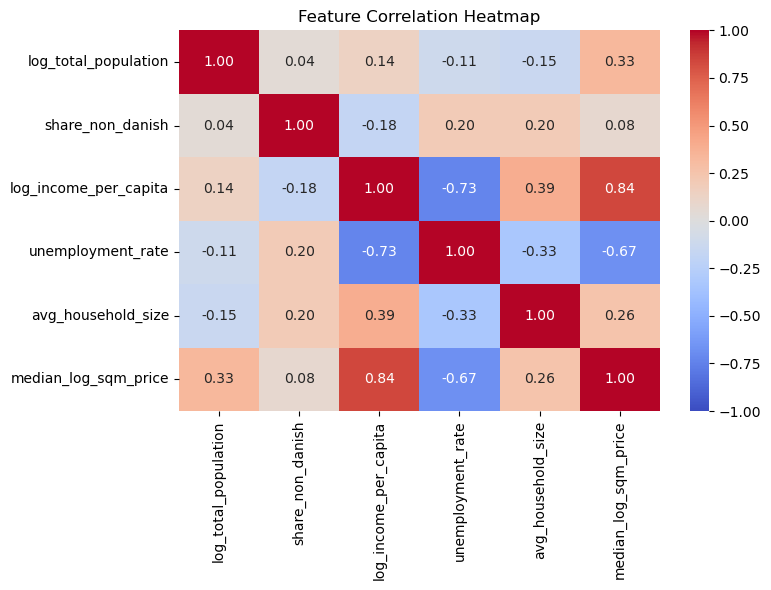

/var/folders/wk/m7pktryd2zn74ff2_s1nkg9r0000gn/T/ipykernel_13095/3200867831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/wk/m7pktryd2zn74ff2_s1nkg9r0000gn/T/ipykernel_13095/3200867831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/wk/m7pktryd2zn74ff2_s1nkg9r0000gn/T/ipykernel_13095/3200867831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/wk/m7pktryd2zn74ff2_s1nkg9r0000gn/T/ipykernel_13095/3200867831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

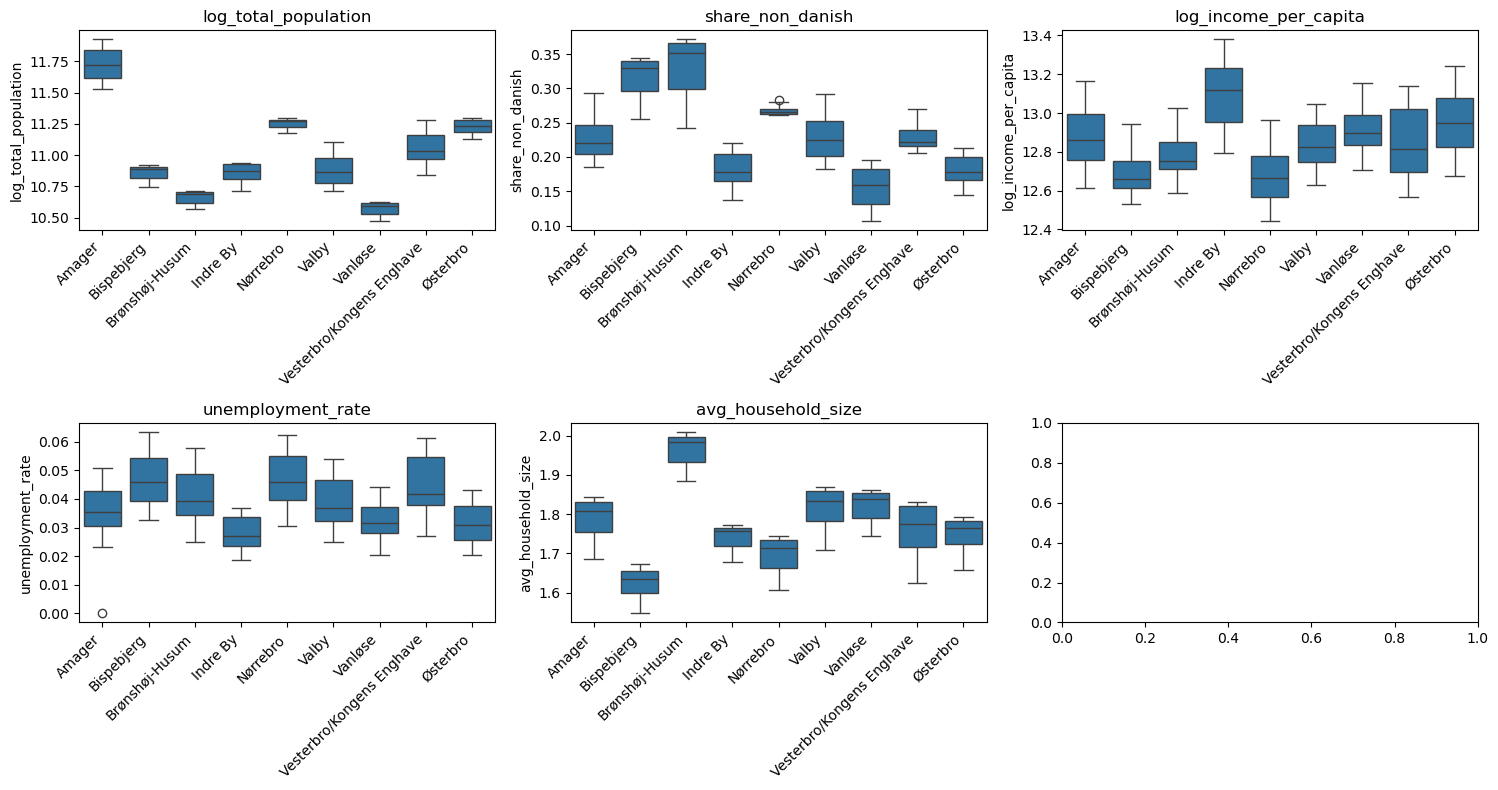

In [42]:
# 1. Correlation Heatmap
corr_cols = FEATURE_COLS + ['median_log_sqm_price']
corr_matrix = panel[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 2. Outlier Check (Boxplots)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), FEATURE_COLS):
    sns.boxplot(x='district', y=feat, data=panel, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(feat)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

#### Feature vs price over time per district

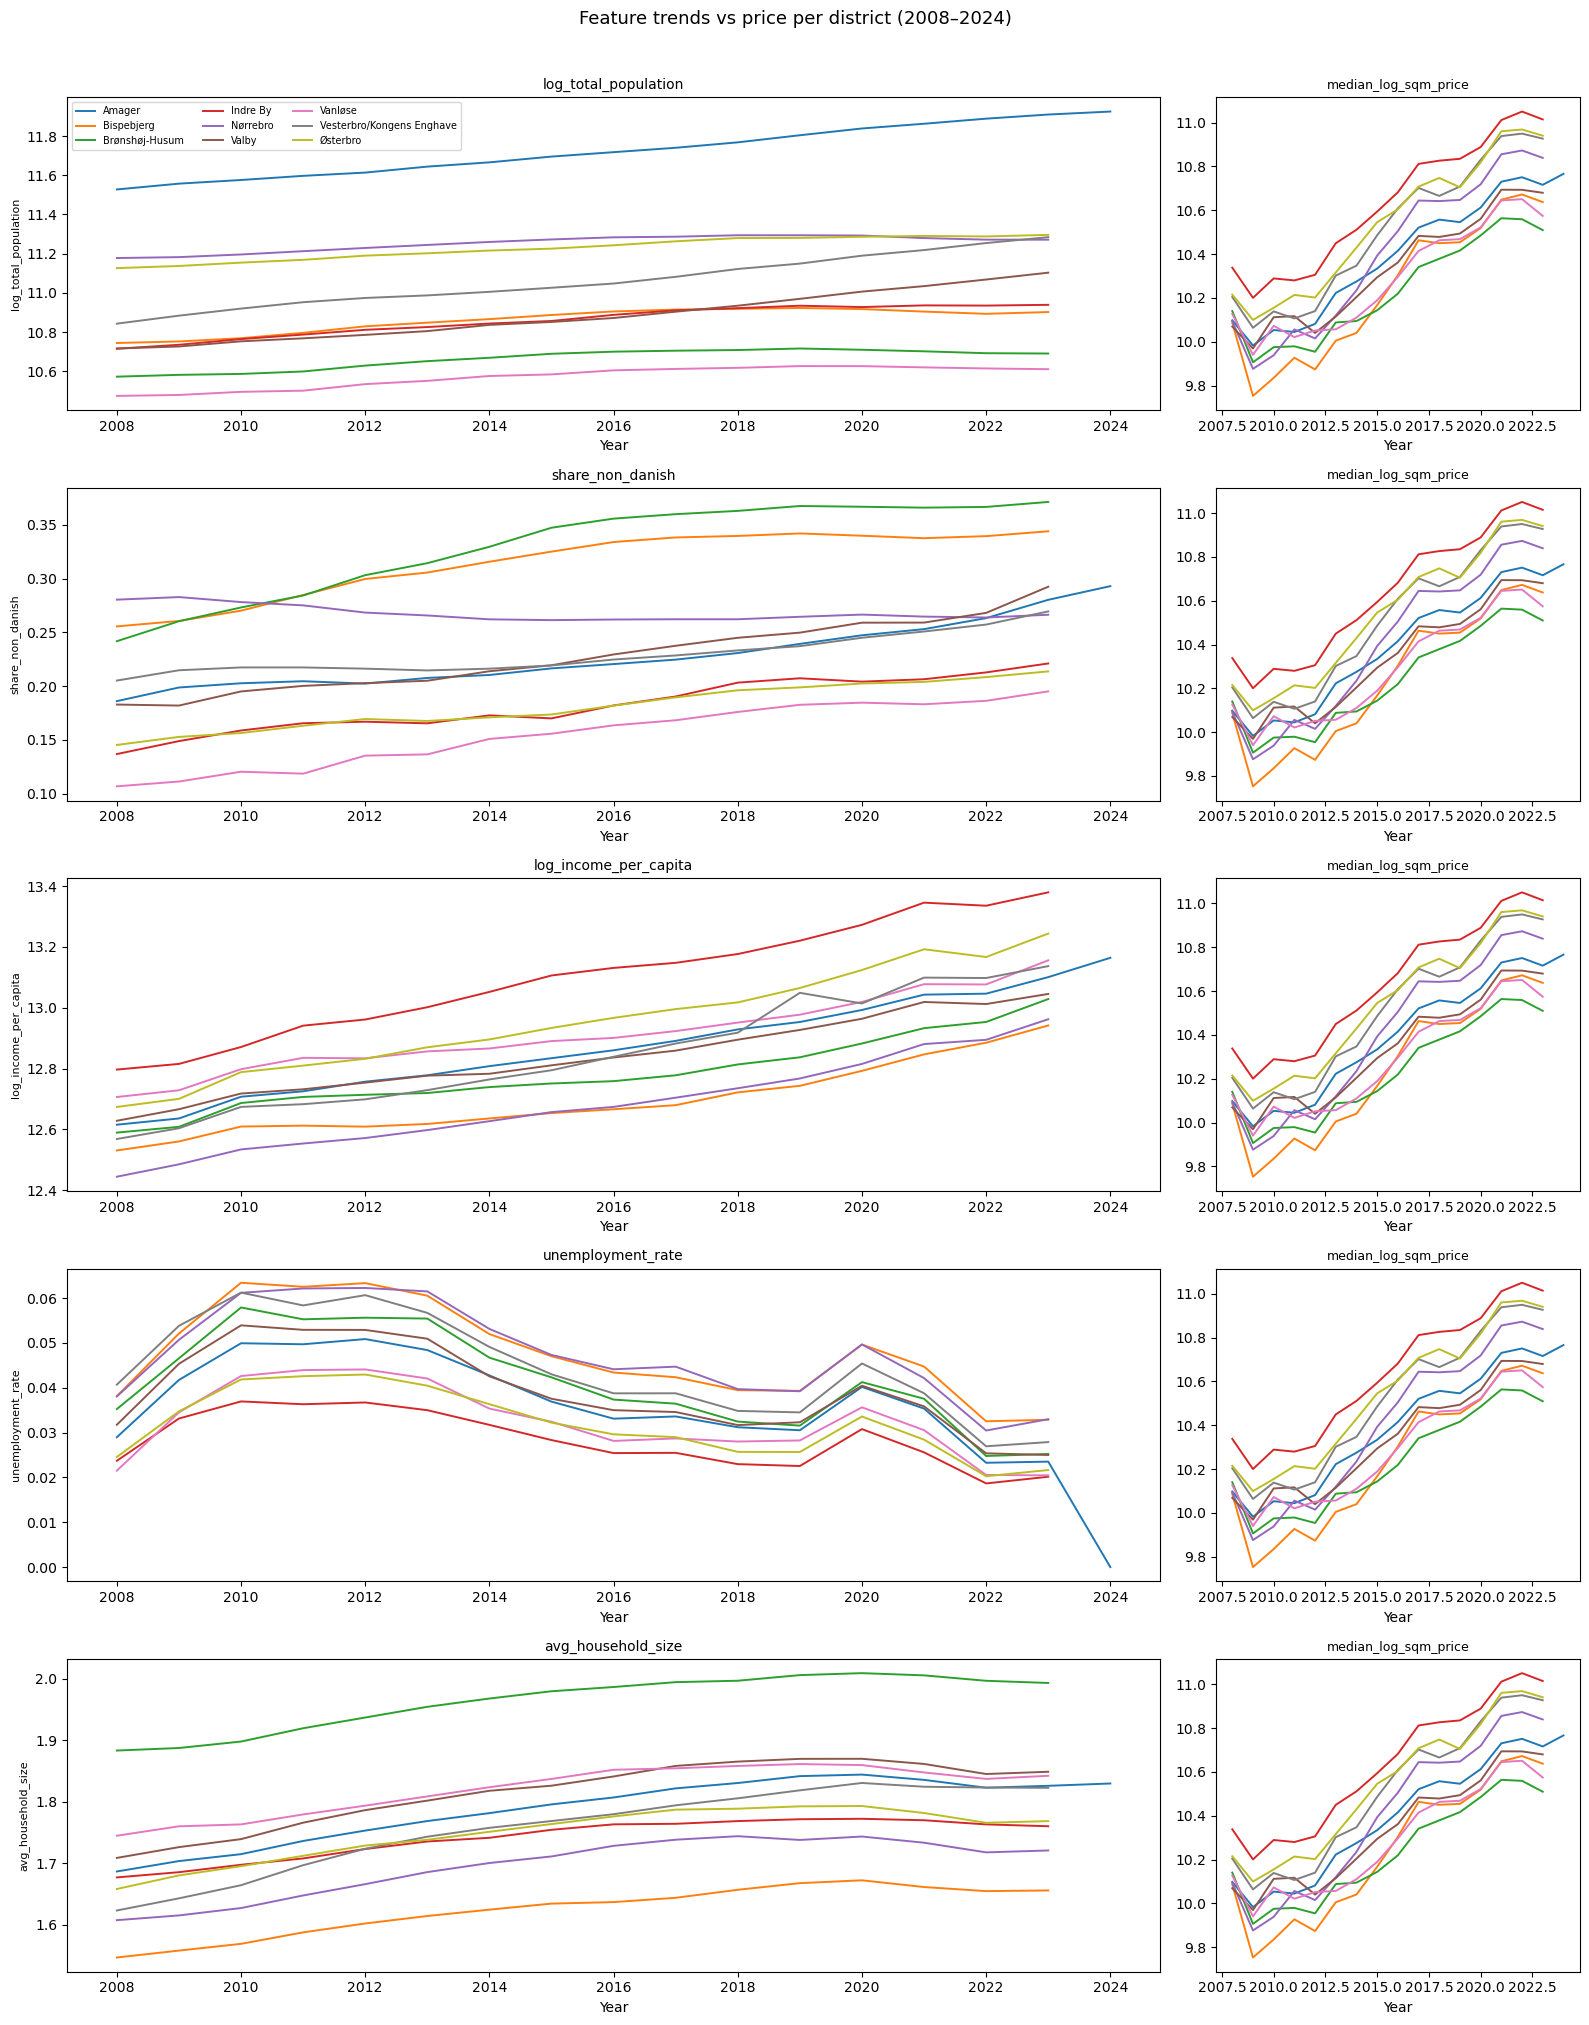

In [43]:
# 3. Feature vs price over time per district
# Left column: feature trend per district. Right column: price for the same districts.
# Lets you visually judge which features co-move with prices and which lead/lag.

districts = sorted(panel['district'].unique())
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(len(FEATURE_COLS), 2, figsize=(16, 4 * len(FEATURE_COLS)),
                         gridspec_kw={'width_ratios': [3, 1]})

for row, feat in enumerate(FEATURE_COLS):
    ax_feat = axes[row, 0]
    ax_price = axes[row, 1]

    for i, d_name in enumerate(districts):
        sub = panel[panel['district'] == d_name].sort_values('year')
        ax_feat.plot(sub['year'], sub[feat], label=d_name, color=colors[i % 10], linewidth=1.4)
        ax_price.plot(sub['year'], sub['median_log_sqm_price'], color=colors[i % 10], linewidth=1.4)

    ax_feat.set_title(feat, fontsize=10)
    ax_feat.set_ylabel(feat, fontsize=8)
    ax_feat.set_xlabel('Year')
    ax_price.set_title('median_log_sqm_price', fontsize=9)
    ax_price.set_xlabel('Year')

    if row == 0:
        ax_feat.legend(fontsize=7, ncol=3, loc='upper left')

plt.suptitle('Feature trends vs price per district (2008–2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 2.7 Analysis of independence of the features


#### VIF and PCA independence checks

Feature independence check
Rows used: 145
Features used: 5

Features:
['log_total_population', 'share_non_danish', 'log_income_per_capita', 'unemployment_rate', 'avg_household_size']


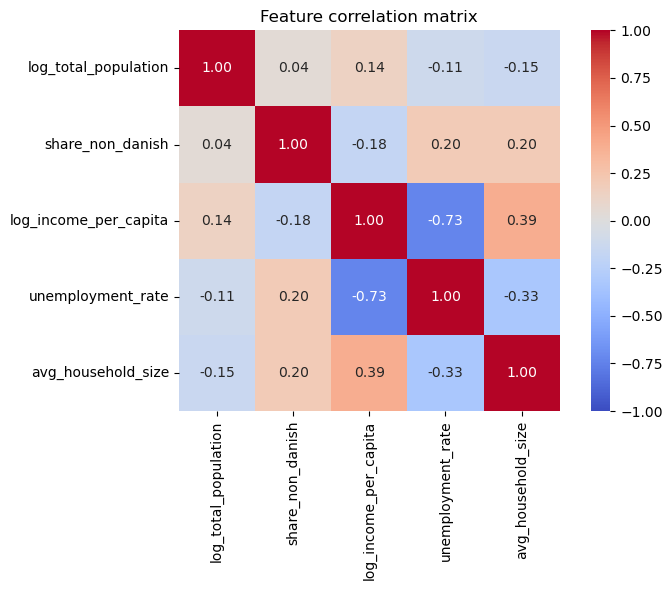


Strongest feature correlations:


,feature_1,feature_2,abs_correlation
7,log_income_per_capita,unemployment_rate,0.731120
8,log_income_per_capita,avg_household_size,0.393655
9,unemployment_rate,avg_household_size,0.332685
5,share_non_danish,unemployment_rate,0.199953
6,share_non_danish,avg_household_size,0.198242
4,share_non_danish,log_income_per_capita,0.177261
3,log_total_population,avg_household_size,0.146312
1,log_total_population,log_income_per_capita,0.138778
2,log_total_population,unemployment_rate,0.111890
0,log_total_population,share_non_danish,0.042018



Feature pairs with |correlation| >= 0.7:


,feature_1,feature_2,abs_correlation
7,log_income_per_capita,unemployment_rate,0.73112



Variance Inflation Factor (VIF):


,feature,VIF
2,log_income_per_capita,2.363238
3,unemployment_rate,2.203859
4,avg_household_size,1.405314
1,share_non_danish,1.178143
0,log_total_population,1.097395


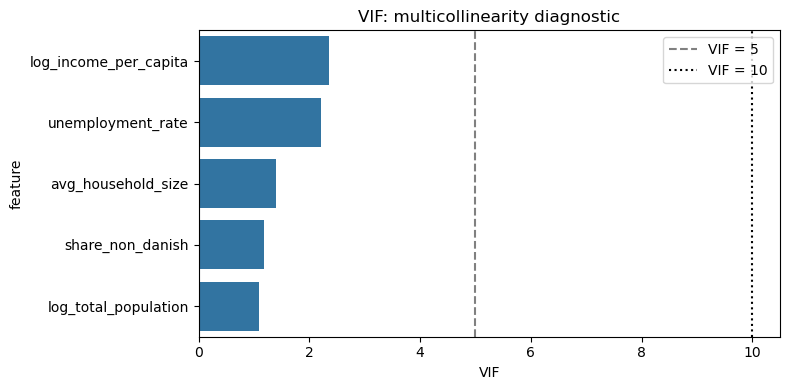


Condition number: 2.78
Interpretation: Low multicollinearity risk.

PCA explained variance:


,PC,explained_variance_ratio,cumulative_variance
0,PC1,0.405379,0.405379
1,PC2,0.241612,0.646990
2,PC3,0.207952,0.854942
3,PC4,0.092450,0.947392
4,PC5,0.052608,1.000000


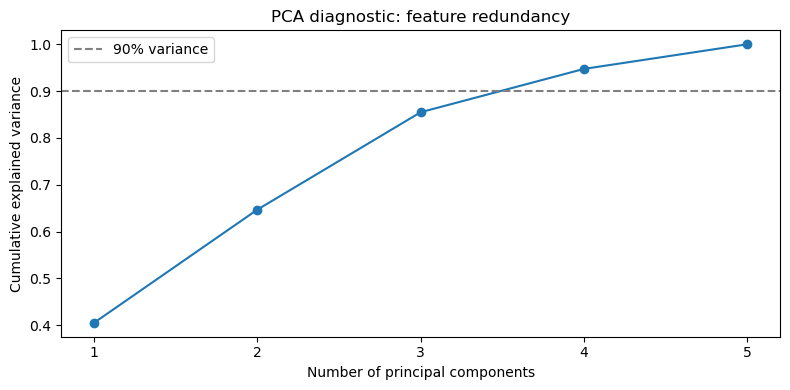


FEATURE INDEPENDENCE / MULTICOLLINEARITY SUMMARY
Maximum absolute pairwise correlation: 0.73
Maximum VIF: 2.36
Condition number: 2.78

Conclusion:
Some dependence between engineered features may be present.
Inspect the high-correlation pairs and VIF values above.
Consider removing, combining, or rethinking highly redundant features.


In [44]:
# -------------------------------------------------------------------
# 5. Feature independence / multicollinearity analysis
# -------------------------------------------------------------------
# Goal:
# Check whether the engineered features are too dependent/correlated.
# This matters because highly dependent features can make beta estimates
# unstable and harder to interpret in the Pyro PGM.



# Use the engineered feature columns from Phase 2.5
X_feat = panel[FEATURE_COLS].copy()

# Drop rows with missing values for this diagnostic
X_feat = X_feat.dropna()

print("Feature independence check")
print("Rows used:", X_feat.shape[0])
print("Features used:", X_feat.shape[1])
print("\nFeatures:")
print(FEATURE_COLS)

# -------------------------------------------------------------------
# A) Correlation matrix
# -------------------------------------------------------------------

corr = X_feat.corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# Flag strong pairwise correlations
corr_pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "abs_correlation"]
corr_pairs = corr_pairs.sort_values("abs_correlation", ascending=False)

print("\nStrongest feature correlations:")
display(corr_pairs.head(10))

high_corr_threshold = 0.70
high_corr_pairs = corr_pairs[corr_pairs["abs_correlation"] >= high_corr_threshold]

if high_corr_pairs.empty:
    print(f"\nNo feature pairs have |correlation| >= {high_corr_threshold}.")
else:
    print(f"\nFeature pairs with |correlation| >= {high_corr_threshold}:")
    display(high_corr_pairs)

# -------------------------------------------------------------------
# B) Variance Inflation Factor (VIF)
# -------------------------------------------------------------------
# VIF measures how much one feature can be explained by the others.
# Rule of thumb:
# VIF < 5  : usually acceptable
# VIF 5-10 : moderate multicollinearity
# VIF > 10 : serious multicollinearity

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_feat),
    columns=X_feat.columns,
    index=X_feat.index
)

vif_df = pd.DataFrame({
    "feature": X_scaled.columns,
    "VIF": [
        variance_inflation_factor(X_scaled.values, i)
        for i in range(X_scaled.shape[1])
    ]
}).sort_values("VIF", ascending=False)

print("\nVariance Inflation Factor (VIF):")
display(vif_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=vif_df, x="VIF", y="feature")
plt.axvline(5, linestyle="--", color="grey", label="VIF = 5")
plt.axvline(10, linestyle=":", color="black", label="VIF = 10")
plt.title("VIF: multicollinearity diagnostic")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# C) Condition number
# -------------------------------------------------------------------
# Large condition number means the design matrix is close to singular.
# Rule of thumb:
# < 30   : usually fine
# 30-100 : possible multicollinearity
# > 100  : strong multicollinearity

condition_number = np.linalg.cond(X_scaled.values)

print(f"\nCondition number: {condition_number:.2f}")

if condition_number < 30:
    print("Interpretation: Low multicollinearity risk.")
elif condition_number < 100:
    print("Interpretation: Moderate multicollinearity risk.")
else:
    print("Interpretation: High multicollinearity risk.")

# -------------------------------------------------------------------
# D) PCA diagnostic
# -------------------------------------------------------------------
# If very few principal components explain almost all variance,
# features may contain overlapping information.

pca = PCA()
pca.fit(X_scaled)

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(FEATURE_COLS))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

print("\nPCA explained variance:")
display(pca_summary)

plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(FEATURE_COLS) + 1),
    pca_summary["cumulative_variance"],
    marker="o"
)
plt.axhline(0.90, linestyle="--", color="grey", label="90% variance")
plt.xticks(range(1, len(FEATURE_COLS) + 1))
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA diagnostic: feature redundancy")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# E) Final automatic summary
# -------------------------------------------------------------------

print("\n" + "="*70)
print("FEATURE INDEPENDENCE / MULTICOLLINEARITY SUMMARY")
print("="*70)

max_corr = corr_pairs["abs_correlation"].max()
max_vif = vif_df["VIF"].max()

print(f"Maximum absolute pairwise correlation: {max_corr:.2f}")
print(f"Maximum VIF: {max_vif:.2f}")
print(f"Condition number: {condition_number:.2f}")

if max_corr < 0.70 and max_vif < 5 and condition_number < 30:
    print("\nConclusion:")
    print("The engineered features appear reasonably independent for the Pyro model.")
    print("No serious multicollinearity issues detected.")
else:
    print("\nConclusion:")
    print("Some dependence between engineered features may be present.")
    print("Inspect the high-correlation pairs and VIF values above.")
    print("Consider removing, combining, or rethinking highly redundant features.")

## Phase 4 - Modelling with Pyro Implementation


Modelling uses <span style="color:#1565c0">**`model_panel_restricted_withfeatures`**</span> dataframe which includes the following columns:

- **`district`**, **`year`**
- **Observed y values:** **`median_log_sqm_price`**
- **Features standardized:** **`log_total_population_std`**, **`share_non_danish_std`**, **`log_income_per_capita_std`**, **`unemployment_rate_std`**, **`avg_household_size_std`**, **`year_std_std`**



#### Inspect modelling panel

In [45]:
#Inspecting first 5 rows of dataframe
model_panel_restricted_withfeatures.head()

,district,year,median_log_sqm_price,sem_log_sqm_price,log_total_population_std,share_non_danish_std,log_income_per_capita_std,unemployment_rate_std,avg_household_size_std
0,Amager,2008,10.097778,0.029081,1.471293,-0.780718,-1.241473,-0.829394,-0.862627
1,Amager,2009,9.982737,0.027256,1.556671,-0.578022,-1.134374,0.267112,-0.692795
2,Amager,2010,10.053356,0.018934,1.610127,-0.515139,-0.761794,0.969382,-0.580365
3,Amager,2011,10.044393,0.020594,1.671023,-0.484895,-0.668767,0.949859,-0.365049
4,Amager,2012,10.081374,0.017929,1.718879,-0.520239,-0.503672,1.049203,-0.195558


#### Column name export and Pyro initialisation

In [46]:
# Save all column names to a text file
with open('data/cleaned/panel_columns.txt', 'w') as f:
    for i, col in enumerate(panel.columns, 1):
        f.write(f"{i:3d}. {col}\n")

### Model 1 — AR(1), Indre By, MCMC

Data preparation: filter Indre By, split train/test, compute centered first-differences `g'` and standardise the level series.

In [47]:
panel_df = model_panel_restricted_withfeatures

# Filtering for district Indre By
district = "Indre By"

ts = (
    panel_df.loc[panel_df["district"] == district, ["year", "median_log_sqm_price"]]
    .dropna()
    .sort_values("year")
    .reset_index(drop=True)
)

ts = ts[ts["year"] <= 2023].reset_index(drop=True)

years = ts["year"].to_numpy()
y = torch.tensor(ts["median_log_sqm_price"].to_numpy(), dtype=torch.float) 

# Train/test split sizes first — scaler fit on TRAIN only (to prevent data leakage we do this first)
T = len(y)
N_TEST = 5
T_train = max(5, T - N_TEST)

# Standardize using training-level mean/std only; apply same transform to full series
y_mean = y[:T_train].mean()
y_std = y[:T_train].std()
y_std = y_std if y_std > 0 else torch.tensor(1.0)
y_z = (y - y_mean) / y_std

years_train, years_test = years[:T_train], years[T_train:]
y_train_z, y_test_z = y_z[:T_train], y_z[T_train:]

def _info():
    print(f"District: {district}")
    print(f"Total length: {T} years ({years.min()}–{years.max()})")
    print(f"Train: {len(y_train_z)} years ({years_train.min()}–{years_train.max()})")
    if len(years_test):
        print(f"Test:  {len(y_test_z)} years ({years_test.min()}–{years_test.max()})")
    else:
        print("Test: 0 years (increase N_TEST or ensure longer series)")

_info()

# Difference + mean-center (on training data ONLY)
if len(y_train_z) < 3:
    raise ValueError("Need at least 3 training points.")

g_train = y_train_z[1:] - y_train_z[:-1]   # length T_train-1
g_mean = g_train.mean()                    # scalar
g_train_c = g_train - g_mean               # centered diffs
g0_c = g_train_c[-1]                       # last centered diff

h = len(y_test_z)                          # forecast horizon in LEVELS
print("Train mean diff (z-space):", float(g_mean))

District: Indre By
Total length: 16 years (2008–2023)
Train: 11 years (2008–2018)
Test:  5 years (2019–2023)
Train mean diff (z-space): 0.22040769457817078


#### Model 1 — AR(1) probabilistic model definition

In [48]:
#PGM for AR(1) on mean centered and differenced data defined below
def ar1_centered_diff_model(g_c_obs):
    T_ = g_c_obs.shape[0]
    if T_ < 2:
        raise ValueError("Need at least 2 diff observations to fit AR(1).")

    # constrain phi to (-1, 1)
    # prior for latent variables defined:
    phi_raw = pyro.sample("phi_raw", dist.Normal(0.0, 0.5))
    phi = pyro.deterministic("phi", torch.tanh(phi_raw))

    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    # likelihood
    # seperate for first observation
    pyro.sample("g0", dist.Normal(0.0, sigma_g), obs=g_c_obs[0])
    mean = phi * g_c_obs[:-1]
    pyro.sample("g1T", dist.Normal(mean, sigma_g).to_event(1), obs=g_c_obs[1:])


def simulate_centered_diffs(phi, sigma_g, g0_c, horizon):
    ys = []
    prev = g0_c
    for _ in range(horizon):
        mean = phi * prev
        prev = dist.Normal(mean, sigma_g).sample()
        ys.append(prev)
    return torch.stack(ys)


#### Model 1 — MCMC inference (NUTS)

In [49]:
# Fit AR(1) on centered diffs (TRAIN ONLY)
pyro.set_rng_seed(0)
pyro.clear_param_store()

nuts = NUTS(ar1_centered_diff_model, target_accept_prob=0.9)
mcmc = MCMC(nuts, num_samples=600, warmup_steps=400, num_chains=1)

mcmc.run(g_train_c)
posterior = mcmc.get_samples()

phi_raw_post = posterior["phi_raw"].detach().cpu().numpy()
phi_post = np.tanh(phi_raw_post)
sig_g_post = posterior["sigma_g"].detach().cpu().numpy()

print("Posterior summary (train fit)")
print("phi mean:", phi_post.mean(), "phi 5/95:", np.quantile(phi_post, [0.05, 0.95]))
print("sigma_g mean:", sig_g_post.mean())



Warmup:   0%|          | 0/1000 [00:00, ?it/s]

Sample: 100%|██████████| 1000/1000 [00:02, 444.28it/s, step size=5.96e-01, acc. prob=0.946]

Posterior summary (train fit)
phi mean: -0.05694725 phi 5/95: [-0.5764194   0.49086227]
sigma_g mean: 0.41622984


#### Model 1 — Posterior predictive forecast (z-space centered diffs)

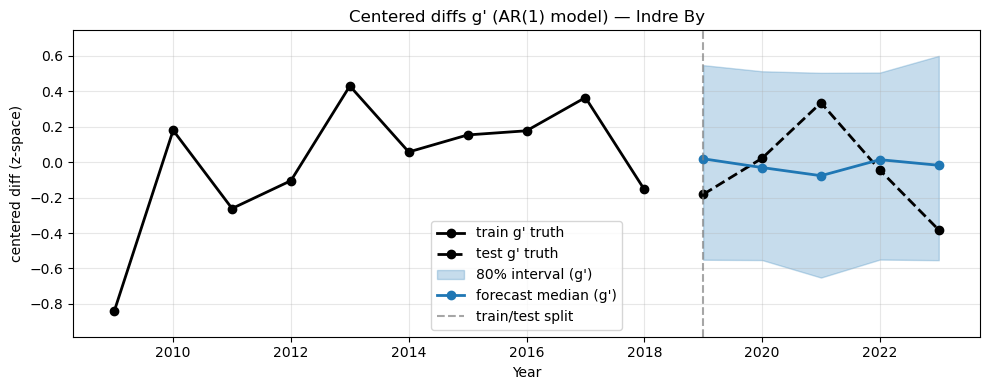

2019 centered-diff error (forecast - truth): +0.2009
2020 centered-diff error (forecast - truth): -0.0526
2021 centered-diff error (forecast - truth): -0.4117
2022 centered-diff error (forecast - truth): +0.0588
2023 centered-diff error (forecast - truth): +0.3649


In [50]:
# Plot the *modeled* series: centered differences g'
#   g_t  = y_t - y_{t-1}
#   g'_t = g_t - mean(g_train)

# Train centered diffs already computed as g_train_c
years_train_diff = years_train[1:]
g_train_c_np = g_train_c.detach().numpy()

# Build test centered diffs from held-out levels (z-space)
if len(y_test_z) == 0:
    raise ValueError("No test years. Reduce N_TEST or choose a district with more years.")

g_test = torch.empty_like(y_test_z)
# first test diff: from last train level -> first test level
g_test[0] = y_test_z[0] - y_train_z[-1]
if len(y_test_z) > 1:
    g_test[1:] = y_test_z[1:] - y_test_z[:-1]

g_test_c = g_test - g_mean
g_test_c_np = g_test_c.detach().numpy()

# Posterior predictive for centered diffs over test horizon
S = 300
paths_g = []
for s in range(min(S, len(phi_post))):
    phi_s = torch.tensor(phi_post[s], dtype=torch.float)
    sig_s = torch.tensor(sig_g_post[s], dtype=torch.float)
    paths_g.append(simulate_centered_diffs(phi_s, sig_s, g0_c=g0_c, horizon=len(y_test_z)))

paths_g = torch.stack(paths_g)  # [S, h] centered diffs

p10_g = paths_g.quantile(0.10, dim=0).detach().numpy()
p50_g = paths_g.quantile(0.50, dim=0).detach().numpy()
p90_g = paths_g.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 4))

# Keep identical y-scale across AR / ARX and avoid clipping
y_lo = float(min(g_train_c_np.min(), g_test_c_np.min(), p10_g.min()))
y_hi = float(max(g_train_c_np.max(), g_test_c_np.max(), p90_g.max()))
pad = 0.10 * (y_hi - y_lo + 1e-6)
plt.ylim(y_lo - pad, y_hi + pad)

plt.plot(years_train_diff, g_train_c_np, marker="o", color="black", linewidth=2, label="train g' truth")
plt.plot(years_test, g_test_c_np, marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")

plt.fill_between(years_test, p10_g, p90_g, alpha=0.25, color="C0", label="80% interval (g')")
plt.plot(years_test, p50_g, marker="o", linewidth=2, color="C0", label="forecast median (g')")

plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")

plt.title(f"Centered diffs g' (AR(1) model) — {district}")
plt.xlabel("Year")
plt.ylabel("centered diff (z-space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Per-year errors on centered diffs
err_g = p50_g - g_test_c_np
for yr, e in zip(years_test, err_g):
    print(f"{int(yr)} centered-diff error (forecast - truth): {e:+.4f}")

#### Model 1 — Back-transform forecast to DKK/m²

In [51]:
import os as _os
import csv as _csv

model_results = {}  # populated by each model's back-transform cell

_RESULTS_DIR = 'results/model_comparison'
_os.makedirs(_RESULTS_DIR, exist_ok=True)


def _model_fname(key):
    slug = (key.replace('/', '_').replace('(', '').replace(')', '')
               .replace('+', 'plus').replace(' ', '_').replace('-', '_'))
    return _os.path.join(_RESULTS_DIR, f'{slug}_results.csv')


def _save_results_csv(key, p10, p50, p90, observed, districts_arg, test_years_arg):
    rows = []
    if p50.ndim == 2:
        for d_idx, dname in enumerate(districts_arg):
            yrs = test_years_arg[d_idx] if isinstance(test_years_arg, list) else test_years_arg
            for t_idx, yr in enumerate(yrs):
                rows.append((dname, int(yr), float(p10[d_idx, t_idx]),
                             float(p50[d_idx, t_idx]), float(p90[d_idx, t_idx]),
                             float(observed[d_idx, t_idx])))
    else:
        dname = districts_arg if isinstance(districts_arg, str) else districts_arg[0]
        for t_idx, yr in enumerate(test_years_arg):
            rows.append((dname, int(yr), float(p10[t_idx]), float(p50[t_idx]),
                         float(p90[t_idx]), float(observed[t_idx])))
    fname = _model_fname(key)
    with open(fname, 'w', newline='') as f:
        w = _csv.writer(f)
        w.writerow(['district', 'year', 'p10', 'p50', 'p90', 'observed'])
        w.writerows(rows)
    print(f'  [CSV] {key} -> {fname} ({len(rows)} rows)')


def _load_results_csv(key, districts_arg=None):
    fname = _model_fname(key)
    if not _os.path.exists(fname):
        return None
    with open(fname, 'r', newline='') as f:
        rows = list(_csv.DictReader(f))
    if not rows:
        return None
    all_d = list(dict.fromkeys(r['district'] for r in rows))
    if len(all_d) == 1 and (districts_arg is None or isinstance(districts_arg, str)):
        return (np.array([float(r['p10'])      for r in rows]),
                np.array([float(r['p50'])      for r in rows]),
                np.array([float(r['p90'])      for r in rows]),
                np.array([float(r['observed']) for r in rows]))
    dlist = list(districts_arg) if districts_arg is not None else all_d
    by_d  = {d: [r for r in rows if r['district'] == d] for d in dlist}
    return (np.stack([np.array([float(r['p10'])      for r in by_d[d]]) for d in dlist]),
            np.stack([np.array([float(r['p50'])      for r in by_d[d]]) for d in dlist]),
            np.stack([np.array([float(r['p90'])      for r in by_d[d]]) for d in dlist]),
            np.stack([np.array([float(r['observed']) for r in by_d[d]]) for d in dlist]))


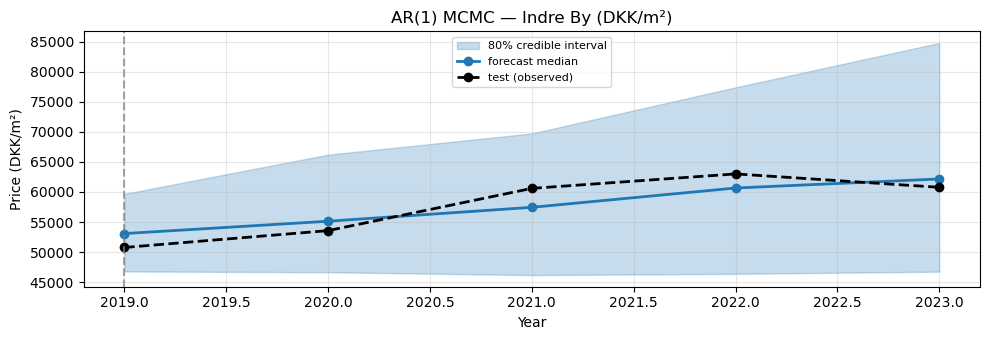

[AR(1)] Indre By 2019 median error (DKK/m²): +2312.7
[AR(1)] Indre By 2020 median error (DKK/m²): +1560.4
[AR(1)] Indre By 2021 median error (DKK/m²): -3148.8
[AR(1)] Indre By 2022 median error (DKK/m²): -2343.3
[AR(1)] Indre By 2023 median error (DKK/m²): +1385.4
  [CSV] AR(1) -> results/model_comparison/AR1_results.csv (5 rows)


In [52]:
# Back-transform: centered diffs → DKK/m²
# paths_g [S, h] and g_test_c already computed in the MCMC plot cell above

paths_unc   = paths_g + g_mean
paths_lev_z = y_train_z[-1] + torch.cumsum(paths_unc, dim=1)
paths_log   = paths_lev_z * y_std + y_mean
paths_price = torch.exp(paths_log)

g_test_raw   = g_test_c + g_mean
y_te_lev_z   = y_train_z[-1] + torch.cumsum(g_test_raw, dim=0)
y_te_log     = y_te_lev_z * y_std + y_mean
y_test_price = torch.exp(y_te_log).detach().numpy()

p10 = paths_price.quantile(0.10, dim=0).detach().numpy()
p50 = paths_price.quantile(0.50, dim=0).detach().numpy()
p90 = paths_price.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 3.5))
plt.fill_between(years_test, p10, p90, alpha=0.25, color='C0', label='80% credible interval')
plt.plot(years_test, p50, marker='o', linewidth=2, color='C0', label='forecast median')
plt.plot(years_test, y_test_price, marker='o', color='black', linestyle='--', linewidth=2, label='test (observed)')
plt.axvline(years_test[0], color='grey', linestyle='--', alpha=0.7)
plt.title(f'AR(1) MCMC — {district} (DKK/m²)')
plt.xlabel('Year')
plt.ylabel('Price (DKK/m²)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

for yr, e in zip(years_test, p50 - y_test_price):
    print(f'[AR(1)] {district} {int(yr)} median error (DKK/m²): {e:+.1f}')

model_results["AR(1)"] = (p10.copy(), p50.copy(), p90.copy(), y_test_price.copy())

_save_results_csv("AR(1)", p10.copy(), p50.copy(), p90.copy(), y_test_price.copy(), district, years_test)


##### **Methodological comparison — Variational Inference (SVI):** The cell below re-fits the same model using `AutoDiagonalNormal` SVI as a comparison against MCMC above. For a low-parameter model, NUTS gives exact posterior samples; SVI is a mean-field approximation. **This is not a main result — the MCMC forecast above is the primary inference.** Outputs are in z-space centered diffs only (no back-transformation).

SVI step     0  ELBO loss: 9.51
SVI step   500  ELBO loss: 5.99
SVI step  1000  ELBO loss: 6.07
SVI step  1500  ELBO loss: 5.66
SVI step  2000  ELBO loss: 5.96
SVI step  2500  ELBO loss: 5.87
SVI step  3000  ELBO loss: 5.99
SVI step  3500  ELBO loss: 6.01
SVI step  3999  ELBO loss: 6.20

VI posterior summary (train fit)
phi mean: -0.06833353 phi 5/95: [-0.53803445  0.39407479]
sigma_g mean: 0.38807404


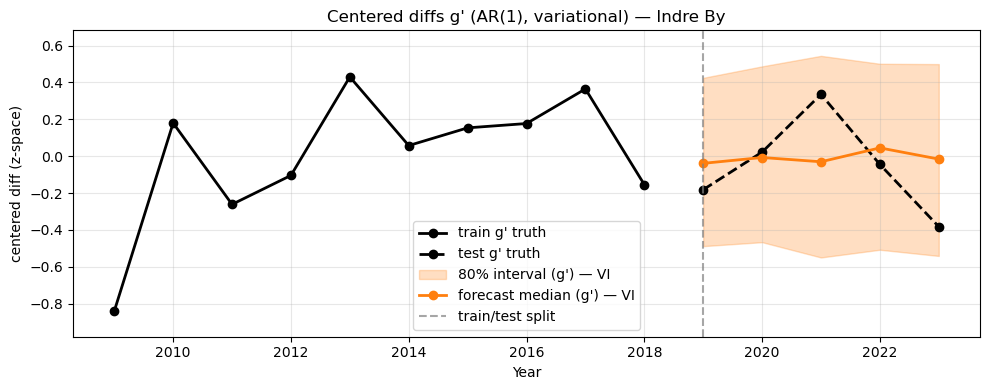

2019 centered-diff error VI (forecast - truth): +0.1429
2020 centered-diff error VI (forecast - truth): -0.0293
2021 centered-diff error VI (forecast - truth): -0.3656
2022 centered-diff error VI (forecast - truth): +0.0897
2023 centered-diff error VI (forecast - truth): +0.3667


In [53]:
# ---------- Variational inference (AR(1) on centered diffs) ----------
pyro.set_rng_seed(0)
pyro.clear_param_store()

guide_ar1 = AutoDiagonalNormal(ar1_centered_diff_model)
optimizer = Adam({"lr": 0.01})
elbo = Trace_ELBO()
svi = SVI(ar1_centered_diff_model, guide_ar1, optimizer, elbo)

num_steps = 4000
for step in range(num_steps):
    loss = svi.step(g_train_c)
    if step % 500 == 0 or step == num_steps - 1:
        print(f"SVI step {step:5d}  ELBO loss: {loss:.2f}")

# Posterior samples for globals (same sites as MCMC cell)
S_vi = 500
with torch.no_grad():
    pred = Predictive(
        ar1_centered_diff_model,
        guide=guide_ar1,
        num_samples=S_vi,
        return_sites=("phi_raw", "sigma_g"),
    )
    vi_samples = pred(g_train_c)

phi_raw_vi = vi_samples["phi_raw"].detach().cpu().numpy().reshape(-1)
phi_vi_post = np.tanh(phi_raw_vi)
sig_g_vi_post = vi_samples["sigma_g"].detach().cpu().numpy().reshape(-1)

print("\nVI posterior summary (train fit)")
print("phi mean:", phi_vi_post.mean(), "phi 5/95:", np.quantile(phi_vi_post, [0.05, 0.95]))
print("sigma_g mean:", sig_g_vi_post.mean())

# ---------- Same plot logic as your MCMC cell, using VI samples ----------
years_train_diff = years_train[1:]
g_train_c_np = g_train_c.detach().numpy()

if len(y_test_z) == 0:
    raise ValueError("No test years. Reduce N_TEST or choose a district with more years.")

g_test = torch.empty_like(y_test_z)
g_test[0] = y_test_z[0] - y_train_z[-1]
if len(y_test_z) > 1:
    g_test[1:] = y_test_z[1:] - y_test_z[:-1]

g_test_c = g_test - g_mean
g_test_c_np = g_test_c.detach().numpy()

S_plot = 300
paths_g_vi = []
for s in range(min(S_plot, len(phi_vi_post))):
    phi_s = torch.tensor(phi_vi_post[s], dtype=torch.float32)
    sig_s = torch.tensor(sig_g_vi_post[s], dtype=torch.float32)
    paths_g_vi.append(
        simulate_centered_diffs(phi_s, sig_s, g0_c=g0_c, horizon=len(y_test_z))
    )

paths_g_vi = torch.stack(paths_g_vi)
p10_g_vi = paths_g_vi.quantile(0.10, dim=0).detach().numpy()
p50_g_vi = paths_g_vi.quantile(0.50, dim=0).detach().numpy()
p90_g_vi = paths_g_vi.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 4))

y_lo = float(min(g_train_c_np.min(), g_test_c_np.min(), p10_g_vi.min()))
y_hi = float(max(g_train_c_np.max(), g_test_c_np.max(), p90_g_vi.max()))
pad = 0.10 * (y_hi - y_lo + 1e-6)
plt.ylim(y_lo - pad, y_hi + pad)

plt.plot(years_train_diff, g_train_c_np, marker="o", color="black", linewidth=2, label="train g' truth")
plt.plot(years_test, g_test_c_np, marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")

plt.fill_between(years_test, p10_g_vi, p90_g_vi, alpha=0.25, color="C1", label="80% interval (g') — VI")
plt.plot(years_test, p50_g_vi, marker="o", linewidth=2, color="C1", label="forecast median (g') — VI")

plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")

plt.title(f"Centered diffs g' (AR(1), variational) — {district}")
plt.xlabel("Year")
plt.ylabel("centered diff (z-space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

err_g_vi = p50_g_vi - g_test_c_np
for yr, e in zip(years_test, err_g_vi):
    print(f"{int(yr)} centered-diff error VI (forecast - truth): {e:+.4f}")

### Model 2 — ARX(1), Indre By, MCMC

Data preparation: filter Indre By, split train/test, compute centered first-differences `g'` and align feature matrix `X`.

In [54]:
# Same panel and district setup as the AR(1) cells above
panel_df = model_panel_restricted_withfeatures
district = "Indre By"  # <- change me (match AR block)
N_TEST = 5  # <- change me (match AR block)

feature_cols = FEATURE_COLS_STD

_keep = ["year", "median_log_sqm_price", *feature_cols]
_miss = [c for c in _keep if c not in panel_df.columns]
if _miss:
    raise KeyError(f"model_panel_restricted_withfeatures missing columns {_miss}")

ts = (
    panel_df.loc[panel_df["district"] == district, ["district", *_keep]]
    .dropna()
    .sort_values("year")
    .reset_index(drop=True)
)
ts = ts[ts["year"] <= 2023].reset_index(drop=True)

years = ts["year"].to_numpy()
y = torch.tensor(ts["median_log_sqm_price"].to_numpy(), dtype=torch.float)
X = torch.tensor(ts[feature_cols].to_numpy(), dtype=torch.float)

# Train/test sizes first; z-score y using TRAIN statistics only (matches AR(1), no test leakage)
T = len(y)
T_train = max(5, T - N_TEST)
h = T - T_train

y_mean = y[:T_train].mean()
y_std = y[:T_train].std()
y_std = y_std if y_std > 0 else torch.tensor(1.0)
y_z = (y - y_mean) / y_std

years_train, years_test = years[:T_train], years[T_train:]
y_train_z, y_test_z = y_z[:T_train], y_z[T_train:]


def _info_arx():
    print(f"[ARX] District: {district}")
    print(f"[ARX] Total length: {T} years ({years.min()}–{years.max()})")
    print(f"[ARX] Train: {len(y_train_z)} years ({years_train.min()}–{years_train.max()})")
    if len(years_test):
        print(f"[ARX] Test:  {len(y_test_z)} years ({years_test.min()}–{years_test.max()})")
    else:
        print("[ARX] Test: 0 years")
    print(f"[ARX] Feature cols ({len(feature_cols)}): {feature_cols}")


_info_arx()

if T_train < 3:
    raise ValueError("Need at least 3 training points.")

# First differences on full z-series; align X_g[t] = X[t+1] with g[t] = y_z[t+1]-y_z[t]
g = y_z[1:] - y_z[:-1]
X_g = X[1:]

g_train = g[: T_train - 1]
X_g_train = X_g[: T_train - 1]
g_mean = g_train.mean()
g_train_c = g_train - g_mean
g0_c = g_train_c[-1]

X_g_future = X_g[T_train - 1 : T_train - 1 + h]

print("[ARX] Train mean diff (z-space):", float(g_mean))



[ARX] District: Indre By
[ARX] Total length: 16 years (2008–2023)
[ARX] Train: 11 years (2008–2018)
[ARX] Test:  5 years (2019–2023)
[ARX] Feature cols (5): ['log_total_population_std', 'share_non_danish_std', 'log_income_per_capita_std', 'unemployment_rate_std', 'avg_household_size_std']
[ARX] Train mean diff (z-space): 0.22040769457817078


#### Model 2 — ARX(1) probabilistic model definition

In [55]:
def arx1_centered_diff_model(g_c_obs, X_obs):
    Tdiff, K = X_obs.shape
    if Tdiff < 2:
        raise ValueError("Need at least 2 diff observations to fit ARX(1).")
    

    #phi is AR(1) coefficient, constant across all years to assume stationarity 
    phi_raw = pyro.sample("phi_raw", dist.Normal(0.0, 0.5))
    phi = pyro.deterministic("phi", torch.tanh(phi_raw))

    #beta is coefficient for features(x), constant across all years 
    beta = pyro.sample("beta", dist.Normal(0.0, 0.5).expand([K]).to_event(1))
    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    mean0 = (X_obs[0] * beta).sum()
    pyro.sample("g0", dist.Normal(mean0, sigma_g), obs=g_c_obs[0])

    #mean is linear combination of phi*g_c_obs[:-1] and X_obs[1:] @ beta
    mean = phi * g_c_obs[:-1] + (X_obs[1:] @ beta)
    pyro.sample("g1T", dist.Normal(mean, sigma_g).to_event(1), obs=g_c_obs[1:])


def simulate_centered_diffs_arx(phi, beta, sigma_g, g0_c, X_future):
    ys = []
    prev = g0_c
    for t in range(X_future.shape[0]):
        mean = phi * prev + (X_future[t] * beta).sum()
        prev = dist.Normal(mean, sigma_g).sample()
        ys.append(prev)
    return torch.stack(ys) if ys else torch.empty((0,), dtype=torch.float)



#### Model 2 — MCMC inference (NUTS)

In [56]:
pyro.set_rng_seed(1)
pyro.clear_param_store()

nuts = NUTS(arx1_centered_diff_model, target_accept_prob=0.9)
mcmc = MCMC(nuts, num_samples=600, warmup_steps=400, num_chains=1)

mcmc.run(g_train_c, X_g_train)
post = mcmc.get_samples()

phi_arx = np.tanh(post["phi_raw"].detach().cpu().numpy())
beta_arx = post["beta"].detach().cpu().numpy()
sig_arx = post["sigma_g"].detach().cpu().numpy()

print("[ARX] Posterior summary (train fit)")
print("[ARX] phi mean:", float(phi_arx.mean()), "phi 5/95:", np.quantile(phi_arx, [0.05, 0.95]))
print("[ARX] sigma_g mean:", float(sig_arx.mean()))
print("[ARX] beta means:")
for name, m in zip(FEATURE_COLS_STD, beta_arx.mean(axis=0)):
    print(f"    {name}: {m:+.3f}")



Sample: 100%|██████████| 1000/1000 [00:17, 56.70it/s, step size=1.03e-01, acc. prob=0.961]

[ARX] Posterior summary (train fit)
[ARX] phi mean: -0.41097667813301086 phi 5/95: [-0.76124942  0.05693094]
[ARX] sigma_g mean: 0.2632870078086853
[ARX] beta means:
    log_total_population_std: +0.208
    share_non_danish_std: -0.090
    log_income_per_capita_std: +0.466
    unemployment_rate_std: +0.384
    avg_household_size_std: +0.348


#### Model 2 — Posterior predictive forecast (z-space centered diffs)

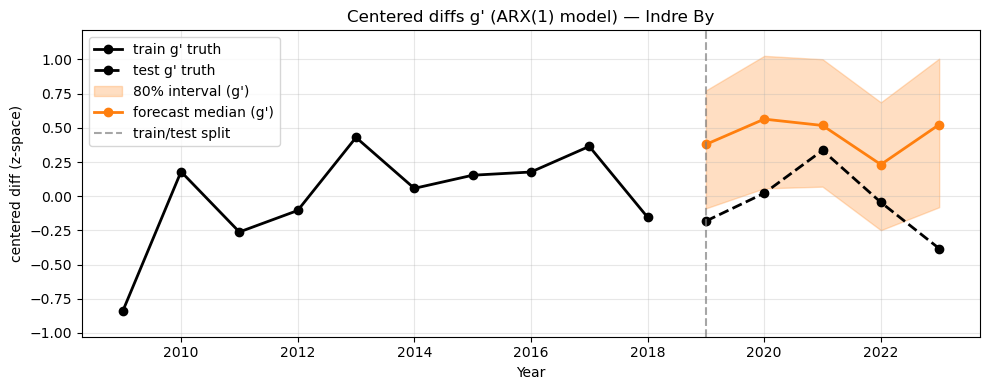

[ARX] 2019 centered-diff error (forecast - truth): +0.5609
[ARX] 2020 centered-diff error (forecast - truth): +0.5419
[ARX] 2021 centered-diff error (forecast - truth): +0.1823
[ARX] 2022 centered-diff error (forecast - truth): +0.2767
[ARX] 2023 centered-diff error (forecast - truth): +0.9064


In [57]:
if len(y_test_z) == 0:
    raise ValueError("No test years. Reduce N_TEST or choose a district with more years.")

years_train_diff = years_train[1:]
g_train_c_np = g_train_c.detach().numpy()

g_test = torch.empty_like(y_test_z)
g_test[0] = y_test_z[0] - y_train_z[-1]
if len(y_test_z) > 1:
    g_test[1:] = y_test_z[1:] - y_test_z[:-1]

g_test_c = g_test - g_mean
g_test_c_np = g_test_c.detach().numpy()

S = min(300, len(phi_arx))
paths_g = []
for s in range(S):
    phi_s = torch.tensor(phi_arx[s], dtype=torch.float)
    beta_s = torch.tensor(beta_arx[s], dtype=torch.float)
    sig_s = torch.tensor(sig_arx[s], dtype=torch.float)
    paths_g.append(simulate_centered_diffs_arx(phi_s, beta_s, sig_s, g0_c=g0_c, X_future=X_g_future))

paths_g = torch.stack(paths_g)
p10_g = paths_g.quantile(0.10, dim=0).detach().numpy()
p50_g = paths_g.quantile(0.50, dim=0).detach().numpy()
p90_g = paths_g.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 4))
y_lo = float(min(g_train_c_np.min(), g_test_c_np.min(), p10_g.min()))
y_hi = float(max(g_train_c_np.max(), g_test_c_np.max(), p90_g.max()))
pad = 0.10 * (y_hi - y_lo + 1e-6)
plt.ylim(y_lo - pad, y_hi + pad)

plt.plot(years_train_diff, g_train_c_np, marker="o", color="black", linewidth=2, label="train g' truth")
plt.plot(years_test, g_test_c_np, marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")
plt.fill_between(years_test, p10_g, p90_g, alpha=0.25, color="C1", label="80% interval (g')")
plt.plot(years_test, p50_g, marker="o", linewidth=2, color="C1", label="forecast median (g')")
plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")
plt.title(f"Centered diffs g' (ARX(1) model) — {district}")
plt.xlabel("Year")
plt.ylabel("centered diff (z-space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for yr, e in zip(years_test, p50_g - g_test_c_np):
    print(f"[ARX] {int(yr)} centered-diff error (forecast - truth): {e:+.4f}")



#### Model 2 — Back-transform forecast to DKK/m²

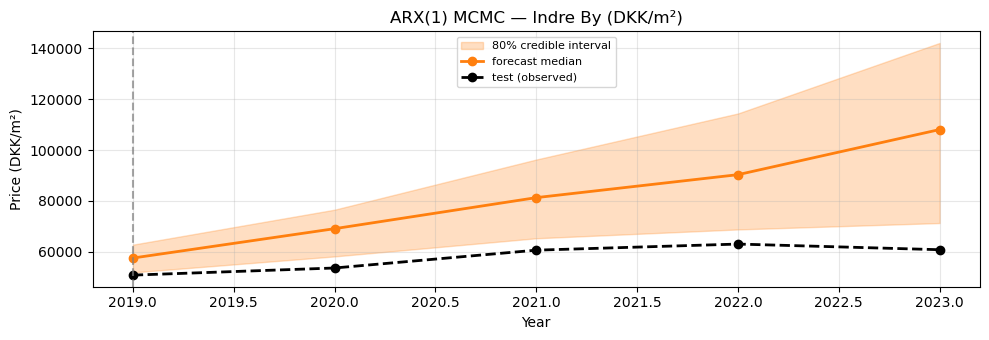

[ARX1] Indre By 2019 median error (DKK/m²): +6721.9
[ARX1] Indre By 2020 median error (DKK/m²): +15474.5
[ARX1] Indre By 2021 median error (DKK/m²): +20681.2
[ARX1] Indre By 2022 median error (DKK/m²): +27316.2
[ARX1] Indre By 2023 median error (DKK/m²): +47301.0
  [CSV] ARX(1) -> results/model_comparison/ARX1_results.csv (5 rows)


In [58]:
# Back-transform: centered diffs → DKK/m²
# paths_g [S, h] and g_test_c already computed in the MCMC plot cell above

paths_unc   = paths_g + g_mean
paths_lev_z = y_train_z[-1] + torch.cumsum(paths_unc, dim=1)
paths_log   = paths_lev_z * y_std + y_mean
paths_price = torch.exp(paths_log)

g_test_raw   = g_test_c + g_mean
y_te_lev_z   = y_train_z[-1] + torch.cumsum(g_test_raw, dim=0)
y_te_log     = y_te_lev_z * y_std + y_mean
y_test_price = torch.exp(y_te_log).detach().numpy()

p10 = paths_price.quantile(0.10, dim=0).detach().numpy()
p50 = paths_price.quantile(0.50, dim=0).detach().numpy()
p90 = paths_price.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 3.5))
plt.fill_between(years_test, p10, p90, alpha=0.25, color='C1', label='80% credible interval')
plt.plot(years_test, p50, marker='o', linewidth=2, color='C1', label='forecast median')
plt.plot(years_test, y_test_price, marker='o', color='black', linestyle='--', linewidth=2, label='test (observed)')
plt.axvline(years_test[0], color='grey', linestyle='--', alpha=0.7)
plt.title(f'ARX(1) MCMC — {district} (DKK/m²)')
plt.xlabel('Year')
plt.ylabel('Price (DKK/m²)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

for yr, e in zip(years_test, p50 - y_test_price):
    print(f'[ARX1] {district} {int(yr)} median error (DKK/m²): {e:+.1f}')

model_results["ARX(1)"] = (p10.copy(), p50.copy(), p90.copy(), y_test_price.copy())

_save_results_csv("ARX(1)", p10.copy(), p50.copy(), p90.copy(), y_test_price.copy(), district, years_test)


#### Note — Single-district ARX overshoot

The ARX(1) forecast drifts well above observed prices during the 2019–2023 test window. This is a structural limitation of fitting a single-district AR model with level features, not a code error.

**Why it happens.** The model is trained on centered first-differences of log prices (mean subtracted, so the training diffs are mean-zero). Features are standardised globally across all districts and years (mean 0, std 1 over the full panel). For Indre By specifically, income and population are persistently *above* the cross-district average, so their standardised values during the test period remain positive. The model learned during training that high-income years were associated with above-average price growth (the 2008–2023 Copenhagen boom). Projecting that association forward gives a positive mean to the centered diffs at every step, which accumulates through `cumsum` into exponential price growth.

Concretely: if `X_test @ beta / (1 - phi) ≈ 0.5` z-units per year, the five-year cumulative drift is `~2.5` z-units, which translates to roughly `exp(2.5 × y_std) ≈ 2×` price growth — matching the observed 107k forecast vs 61k actual.

This motivates the move to **Model 5 (hierarchical ARX(1))**, where partial pooling across all nine districts regularises the feature coefficients and prevents any single district's idiosyncratic feature levels from dominating the posterior.

##### **Methodological comparison — Variational Inference (SVI):** The cell below re-fits the same model using `AutoDiagonalNormal` SVI as a comparison against MCMC above. For a low-parameter model, NUTS gives exact posterior samples; SVI is a mean-field approximation. **This is not a main result — the MCMC forecast above is the primary inference.** Outputs are in z-space centered diffs only (no back-transformation).

[ARX] SVI step     0  ELBO loss: 15.50


[ARX] SVI step   500  ELBO loss: 5.90
[ARX] SVI step  1000  ELBO loss: 9.33
[ARX] SVI step  1500  ELBO loss: 9.45
[ARX] SVI step  2000  ELBO loss: 6.90
[ARX] SVI step  2500  ELBO loss: 12.49
[ARX] SVI step  3000  ELBO loss: 9.21
[ARX] SVI step  3500  ELBO loss: 11.13
[ARX] SVI step  3999  ELBO loss: 10.30

[ARX] VI posterior summary (train fit)
[ARX] phi mean: -0.309541255235672 phi 5/95: [-0.69504923  0.15329449]
[ARX] sigma_g mean: 0.3655681014060974
[ARX] beta means (VI):
    log_total_population_std: +0.129
    share_non_danish_std: +0.009
    log_income_per_capita_std: +0.374
    unemployment_rate_std: +0.306
    avg_household_size_std: +0.262


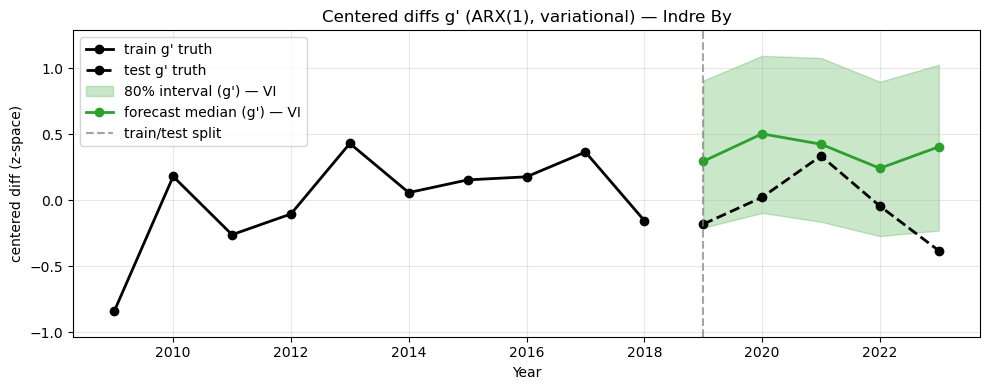

[ARX] 2019 centered-diff error VI (forecast - truth): +0.4762
[ARX] 2020 centered-diff error VI (forecast - truth): +0.4804
[ARX] 2021 centered-diff error VI (forecast - truth): +0.0890
[ARX] 2022 centered-diff error VI (forecast - truth): +0.2865
[ARX] 2023 centered-diff error VI (forecast - truth): +0.7867


In [59]:
# Variational inference: ARX(1) on centered diffs
pyro.set_rng_seed(1)
pyro.clear_param_store()

guide_arx = AutoDiagonalNormal(arx1_centered_diff_model)
optimizer = Adam({"lr": 0.01})
elbo = Trace_ELBO()
svi = SVI(arx1_centered_diff_model, guide_arx, optimizer, elbo)

num_steps = 4000
for step in range(num_steps):
    loss = svi.step(g_train_c, X_g_train)
    if step % 500 == 0 or step == num_steps - 1:
        print(f"[ARX] SVI step {step:5d}  ELBO loss: {loss:.2f}")

S_vi = 500
with torch.no_grad():
    pred = Predictive(
        arx1_centered_diff_model,
        guide=guide_arx,
        num_samples=S_vi,
        return_sites=("phi_raw", "beta", "sigma_g"),
    )
    vi_samples = pred(g_train_c, X_g_train)

phi_raw_vi = vi_samples["phi_raw"].detach().cpu().numpy().reshape(-1)
phi_arx_vi = np.tanh(phi_raw_vi)
sig_arx_vi = vi_samples["sigma_g"].detach().cpu().numpy().reshape(-1)
beta_arx_vi = vi_samples["beta"].detach().cpu().numpy()
if beta_arx_vi.ndim == 3:
    beta_arx_vi = beta_arx_vi.squeeze(1)

print("\n[ARX] VI posterior summary (train fit)")
print("[ARX] phi mean:", float(phi_arx_vi.mean()), "phi 5/95:", np.quantile(phi_arx_vi, [0.05, 0.95]))
print("[ARX] sigma_g mean:", float(sig_arx_vi.mean()))
print("[ARX] beta means (VI):")
for name, m in zip(FEATURE_COLS_STD, beta_arx_vi.mean(axis=0)):
    print(f"    {name}: {m:+.3f}")

# Plot centered diffs g' from VI samples (same logic as MCMC plot)
if len(y_test_z) == 0:
    raise ValueError("No test years. Reduce N_TEST or choose a district with more years.")

years_train_diff = years_train[1:]
g_train_c_np = g_train_c.detach().numpy()

g_test = torch.empty_like(y_test_z)
g_test[0] = y_test_z[0] - y_train_z[-1]
if len(y_test_z) > 1:
    g_test[1:] = y_test_z[1:] - y_test_z[:-1]

g_test_c = g_test - g_mean
g_test_c_np = g_test_c.detach().numpy()

S_plot = min(300, len(phi_arx_vi))
paths_g_vi = []
for s in range(S_plot):
    phi_s = torch.tensor(phi_arx_vi[s], dtype=torch.float32)
    beta_s = torch.tensor(beta_arx_vi[s], dtype=torch.float32)
    sig_s = torch.tensor(sig_arx_vi[s], dtype=torch.float32)
    paths_g_vi.append(
        simulate_centered_diffs_arx(phi_s, beta_s, sig_s, g0_c=g0_c, X_future=X_g_future)
    )

paths_g_vi = torch.stack(paths_g_vi)
p10_g_vi = paths_g_vi.quantile(0.10, dim=0).detach().numpy()
p50_g_vi = paths_g_vi.quantile(0.50, dim=0).detach().numpy()
p90_g_vi = paths_g_vi.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 4))
y_lo = float(min(g_train_c_np.min(), g_test_c_np.min(), p10_g_vi.min()))
y_hi = float(max(g_train_c_np.max(), g_test_c_np.max(), p90_g_vi.max()))
pad = 0.10 * (y_hi - y_lo + 1e-6)
plt.ylim(y_lo - pad, y_hi + pad)

plt.plot(years_train_diff, g_train_c_np, marker="o", color="black", linewidth=2, label="train g' truth")
plt.plot(years_test, g_test_c_np, marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")
plt.fill_between(years_test, p10_g_vi, p90_g_vi, alpha=0.25, color="C2", label="80% interval (g') — VI")
plt.plot(years_test, p50_g_vi, marker="o", linewidth=2, color="C2", label="forecast median (g') — VI")
plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")
plt.title(f"Centered diffs g' (ARX(1), variational) — {district}")
plt.xlabel("Year")
plt.ylabel("centered diff (z-space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for yr, e in zip(years_test, p50_g_vi - g_test_c_np):
    print(f"[ARX] {int(yr)} centered-diff error VI (forecast - truth): {e:+.4f}")


#### Model 2 — Posterior KDE visualisation (phi, beta, sigma_g)

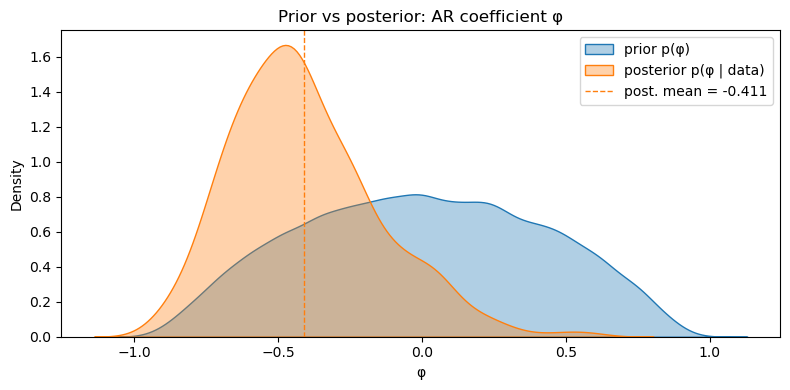

In [60]:
# Prior: phi_raw ~ Normal(0, 0.5), phi = tanh(phi_raw)  (matches Pyro)
rng = np.random.default_rng(42)
n_prior = 50_000
phi_raw_prior = rng.normal(0.0, 0.5, size=n_prior)
phi_prior = np.tanh(phi_raw_prior)

# Posterior draws (ARX: phi_arx; for AR(1) block use phi_post instead)
phi_post = np.asarray(phi_arx, dtype=float).ravel()

plt.figure(figsize=(8, 4))
sns.kdeplot(phi_prior, fill=True, alpha=0.35, color="C0", label="prior p(φ)")
sns.kdeplot(phi_post, fill=True, alpha=0.35, color="C1", label="posterior p(φ | data)")
plt.axvline(float(phi_post.mean()), color="C1", linestyle="--", linewidth=1, label=f"post. mean = {phi_post.mean():.3f}")
plt.xlabel("φ")
plt.title("Prior vs posterior: AR coefficient φ")
plt.legend()
plt.tight_layout()
plt.show()

### Model 3 — ARX(2), Indre By, MCMC

Data preparation: filter Indre By, split train/test, compute centered first-differences `g'` and align feature matrix `X`. ARX(2) uses two lagged diffs.

In [61]:
# Self-contained copy of ARX(2) prep so this block runs standalone at the bottom
panel_df = model_panel_restricted_withfeatures
district = "Indre By"
N_TEST = 5

feature_cols = FEATURE_COLS_STD

_keep = ["year", "median_log_sqm_price", *feature_cols]
_miss = [c for c in _keep if c not in panel_df.columns]
if _miss:
    raise KeyError(f"model_panel_restricted_withfeatures missing columns {_miss}")

ts = (
    panel_df.loc[panel_df["district"] == district, ["district", *_keep]]
    .dropna()
    .sort_values("year")
    .reset_index(drop=True)
)
ts = ts[ts["year"] <= 2023].reset_index(drop=True)

years = ts["year"].to_numpy()
y = torch.tensor(ts["median_log_sqm_price"].to_numpy(), dtype=torch.float)
X = torch.tensor(ts[feature_cols].to_numpy(), dtype=torch.float)

# Train/test sizes first; z-score y using TRAIN statistics only (matches AR(1), no test leakage)
T = len(y)
T_train = max(5, T - N_TEST)
h = T - T_train

y_mean = y[:T_train].mean()
y_std = y[:T_train].std()
y_std = y_std if y_std > 0 else torch.tensor(1.0)
y_z = (y - y_mean) / y_std

years_train, years_test = years[:T_train], years[T_train:]
y_train_z, y_test_z = y_z[:T_train], y_z[T_train:]

print(
    f"[ARX2] Train years: {years_train.min()}–{years_train.max()} | Test: {years_test.min()}–{years_test.max()}"
    if len(years_test)
    else "[ARX2] no test years"
)
print(f"[ARX2] Feature cols ({len(feature_cols)}): {feature_cols}")

if T_train < 4:
    raise ValueError("ARX(2) needs a longer train window (try smaller N_TEST).")

g = y_z[1:] - y_z[:-1]
X_g = X[1:]

g_train = g[: T_train - 1]
X_g_train = X_g[: T_train - 1]
g_mean = g_train.mean()
g_train_c = g_train - g_mean

if len(g_train_c) < 3:
    raise ValueError("ARX(2) needs at least 3 train diffs after centering.")

g0_c = g_train_c[-1]
g_lm2_c = g_train_c[-2]

X_g_future = X_g[T_train - 1 : T_train - 1 + h]
print("[ARX2] Train mean diff (z-space):", float(g_mean))


[ARX2] Train years: 2008–2018 | Test: 2019–2023
[ARX2] Feature cols (5): ['log_total_population_std', 'share_non_danish_std', 'log_income_per_capita_std', 'unemployment_rate_std', 'avg_household_size_std']
[ARX2] Train mean diff (z-space): 0.22040769457817078


#### Model 3 — ARX(2) probabilistic model definition

In [62]:
def arx2_centered_diff_model(g_c_obs, X_obs):
    """g_c_obs: [Tdiff], X_obs: [Tdiff, K] — centered train diffs, features aligned like ARX(1)."""
    Tdiff, K = X_obs.shape
    if Tdiff < 3:
        raise ValueError("Need at least 3 train diff points for ARX(2).")

    phi1_raw = pyro.sample("phi1_raw", dist.Normal(0.0, 0.3))  # lag-1: wider prior
    phi2_raw = pyro.sample("phi2_raw", dist.Normal(0.0, 0.2))  # lag-2: tighter prior
    phi1 = pyro.deterministic("phi1", torch.tanh(phi1_raw))
    phi2 = pyro.deterministic("phi2", torch.tanh(phi2_raw))
    beta = pyro.sample("beta", dist.Normal(0.0, 0.5).expand([K]).to_event(1))
    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    mean0 = (X_obs[0] * beta).sum()
    pyro.sample("g0", dist.Normal(mean0, sigma_g), obs=g_c_obs[0])

    mean1 = phi1 * g_c_obs[0] + (X_obs[1] * beta).sum()
    pyro.sample("g1", dist.Normal(mean1, sigma_g), obs=g_c_obs[1])

    mean_rest = phi1 * g_c_obs[1:-1] + phi2 * g_c_obs[:-2] + (X_obs[2:] @ beta)
    pyro.sample("g2T", dist.Normal(mean_rest, sigma_g).to_event(1), obs=g_c_obs[2:])


def simulate_centered_diffs_arx2(phi1, phi2, beta, sigma_g, prev1, prev2, X_future):
    """Roll forward centered diffs; prev1 = g'_{t-1}, prev2 = g'_{t-2} at start."""
    ys = []
    p1, p2 = prev1, prev2
    for t in range(X_future.shape[0]):
        mean = phi1 * p1 + phi2 * p2 + (X_future[t] * beta).sum()
        new = dist.Normal(mean, sigma_g).sample()
        p2, p1 = p1, new
        ys.append(new)
    return torch.stack(ys) if ys else torch.empty((0,), dtype=torch.float)



#### Model 3 — MCMC inference (NUTS)

In [63]:
pyro.set_rng_seed(2)
pyro.clear_param_store()

nuts = NUTS(arx2_centered_diff_model, target_accept_prob=0.9)
mcmc = MCMC(nuts, num_samples=600, warmup_steps=400, num_chains=1)
mcmc.run(g_train_c, X_g_train)
post2 = mcmc.get_samples()

phi1_arx2 = np.tanh(post2["phi1_raw"].detach().cpu().numpy())
phi2_arx2 = np.tanh(post2["phi2_raw"].detach().cpu().numpy())
beta_arx2 = post2["beta"].detach().cpu().numpy()
sig_arx2 = post2["sigma_g"].detach().cpu().numpy()

print("[ARX2] phi1 mean:", float(phi1_arx2.mean()), "  phi2 mean:", float(phi2_arx2.mean()))
print("[ARX2] sigma_g mean:", float(sig_arx2.mean()))



Sample: 100%|██████████| 1000/1000 [00:18, 52.68it/s, step size=1.27e-01, acc. prob=0.947]

[ARX2] phi1 mean: -0.28801125288009644   phi2 mean: -0.02270538918673992
[ARX2] sigma_g mean: 0.28197458386421204


#### Model 3 — Posterior predictive forecast (z-space centered diffs)

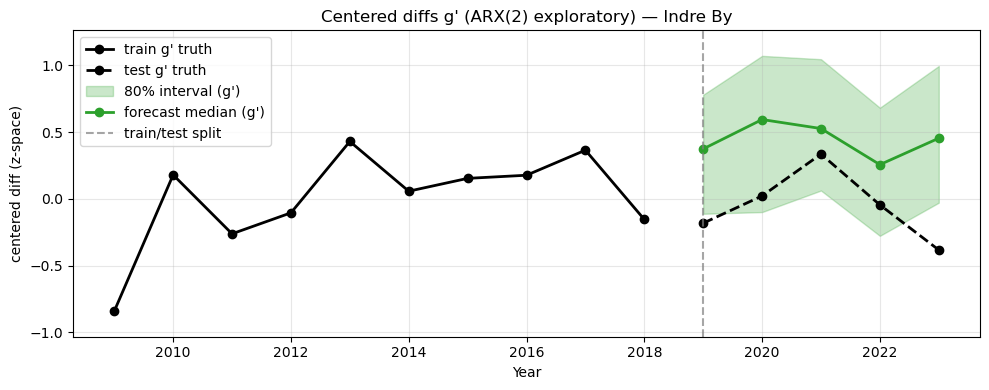

[ARX2] 2019 centered-diff error (forecast - truth): +0.5560
[ARX2] 2020 centered-diff error (forecast - truth): +0.5721
[ARX2] 2021 centered-diff error (forecast - truth): +0.1915
[ARX2] 2022 centered-diff error (forecast - truth): +0.3012
[ARX2] 2023 centered-diff error (forecast - truth): +0.8368


In [64]:
if len(y_test_z) == 0:
    raise ValueError("No test years.")

years_train_diff = years_train[1:]
g_train_c_np = g_train_c.detach().numpy()

g_test = torch.empty_like(y_test_z)
g_test[0] = y_test_z[0] - y_train_z[-1]
if len(y_test_z) > 1:
    g_test[1:] = y_test_z[1:] - y_test_z[:-1]
g_test_c = g_test - g_mean
g_test_c_np = g_test_c.detach().numpy()

S = min(300, len(phi1_arx2))
paths_g = []
for s in range(S):
    p1 = torch.tensor(phi1_arx2[s], dtype=torch.float)
    p2 = torch.tensor(phi2_arx2[s], dtype=torch.float)
    b = torch.tensor(beta_arx2[s], dtype=torch.float)
    sg = torch.tensor(sig_arx2[s], dtype=torch.float)
    paths_g.append(
        simulate_centered_diffs_arx2(p1, p2, b, sg, prev1=g0_c, prev2=g_lm2_c, X_future=X_g_future)
    )

paths_g = torch.stack(paths_g)
p10_g = paths_g.quantile(0.10, dim=0).detach().numpy()
p50_g = paths_g.quantile(0.50, dim=0).detach().numpy()
p90_g = paths_g.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 4))
y_lo = float(min(g_train_c_np.min(), g_test_c_np.min(), p10_g.min()))
y_hi = float(max(g_train_c_np.max(), g_test_c_np.max(), p90_g.max()))
pad = 0.10 * (y_hi - y_lo + 1e-6)
plt.ylim(y_lo - pad, y_hi + pad)

plt.plot(years_train_diff, g_train_c_np, marker="o", color="black", linewidth=2, label="train g' truth")
plt.plot(years_test, g_test_c_np, marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")
plt.fill_between(years_test, p10_g, p90_g, alpha=0.25, color="C2", label="80% interval (g')")
plt.plot(years_test, p50_g, marker="o", linewidth=2, color="C2", label="forecast median (g')")
plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")
plt.title(f"Centered diffs g' (ARX(2) exploratory) — {district}")
plt.xlabel("Year")
plt.ylabel("centered diff (z-space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for yr, e in zip(years_test, p50_g - g_test_c_np):
    print(f"[ARX2] {int(yr)} centered-diff error (forecast - truth): {e:+.4f}")



#### Model 3 — Back-transform forecast to DKK/m²

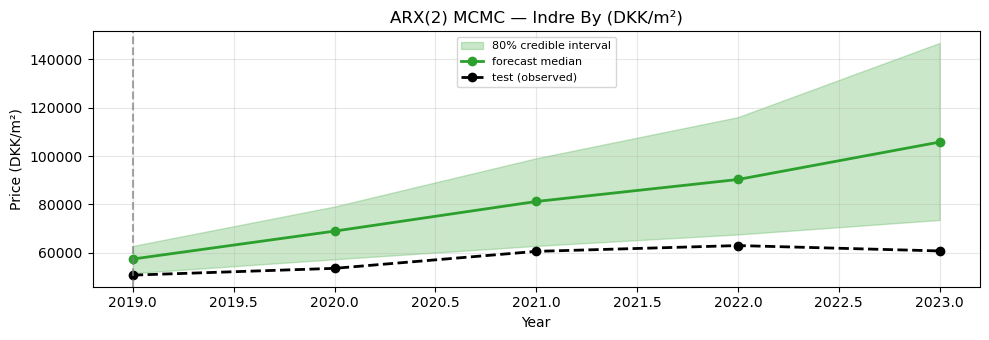

[ARX2] Indre By 2019 median error (DKK/m²): +6659.7
[ARX2] Indre By 2020 median error (DKK/m²): +15397.0
[ARX2] Indre By 2021 median error (DKK/m²): +20638.7
[ARX2] Indre By 2022 median error (DKK/m²): +27334.5
[ARX2] Indre By 2023 median error (DKK/m²): +45041.8
  [CSV] ARX(2) -> results/model_comparison/ARX2_results.csv (5 rows)


In [65]:
# Back-transform: centered diffs → DKK/m²
# paths_g [S, h] and g_test_c already computed in the MCMC plot cell above

paths_unc   = paths_g + g_mean
paths_lev_z = y_train_z[-1] + torch.cumsum(paths_unc, dim=1)
paths_log   = paths_lev_z * y_std + y_mean
paths_price = torch.exp(paths_log)

g_test_raw   = g_test_c + g_mean
y_te_lev_z   = y_train_z[-1] + torch.cumsum(g_test_raw, dim=0)
y_te_log     = y_te_lev_z * y_std + y_mean
y_test_price = torch.exp(y_te_log).detach().numpy()

p10 = paths_price.quantile(0.10, dim=0).detach().numpy()
p50 = paths_price.quantile(0.50, dim=0).detach().numpy()
p90 = paths_price.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 3.5))
plt.fill_between(years_test, p10, p90, alpha=0.25, color='C2', label='80% credible interval')
plt.plot(years_test, p50, marker='o', linewidth=2, color='C2', label='forecast median')
plt.plot(years_test, y_test_price, marker='o', color='black', linestyle='--', linewidth=2, label='test (observed)')
plt.axvline(years_test[0], color='grey', linestyle='--', alpha=0.7)
plt.title(f'ARX(2) MCMC — {district} (DKK/m²)')
plt.xlabel('Year')
plt.ylabel('Price (DKK/m²)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

for yr, e in zip(years_test, p50 - y_test_price):
    print(f'[ARX2] {district} {int(yr)} median error (DKK/m²): {e:+.1f}')

model_results["ARX(2)"] = (p10.copy(), p50.copy(), p90.copy(), y_test_price.copy())

_save_results_csv("ARX(2)", p10.copy(), p50.copy(), p90.copy(), y_test_price.copy(), district, years_test)


##### **Methodological comparison — Variational Inference (SVI):** The cell below re-fits the same model using `AutoDiagonalNormal` SVI as a comparison against MCMC above. For a low-parameter model, NUTS gives exact posterior samples; SVI is a mean-field approximation. **This is not a main result — the MCMC forecast above is the primary inference.** Outputs are in z-space centered diffs only (no back-transformation).

[ARX2] SVI step     0  ELBO loss: 15.85


[ARX2] SVI step   500  ELBO loss: 11.02
[ARX2] SVI step  1000  ELBO loss: 8.52
[ARX2] SVI step  1500  ELBO loss: 7.31
[ARX2] SVI step  2000  ELBO loss: 10.90
[ARX2] SVI step  2500  ELBO loss: 8.77
[ARX2] SVI step  3000  ELBO loss: 10.46
[ARX2] SVI step  3500  ELBO loss: 8.66
[ARX2] SVI step  3999  ELBO loss: 5.99

[ARX2] VI posterior summary (train fit)
[ARX2] phi1 mean: -0.13812030851840973   phi2 mean: -0.035094305872917175
[ARX2] sigma_g mean: 0.3985427916049957


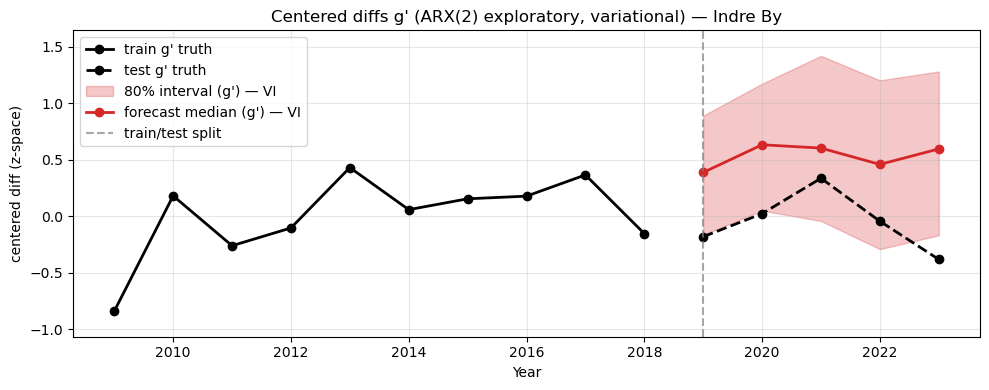

[ARX2] 2019 centered-diff error VI (forecast - truth): +0.5686
[ARX2] 2020 centered-diff error VI (forecast - truth): +0.6097
[ARX2] 2021 centered-diff error VI (forecast - truth): +0.2672
[ARX2] 2022 centered-diff error VI (forecast - truth): +0.5027
[ARX2] 2023 centered-diff error VI (forecast - truth): +0.9774


In [66]:
# Variational inference: ARX(2) on centered diffs
pyro.set_rng_seed(2)
pyro.clear_param_store()

guide_arx2 = AutoDiagonalNormal(arx2_centered_diff_model)
optimizer = Adam({"lr": 0.01})
elbo = Trace_ELBO()
svi = SVI(arx2_centered_diff_model, guide_arx2, optimizer, elbo)

num_steps = 4000
for step in range(num_steps):
    loss = svi.step(g_train_c, X_g_train)
    if step % 500 == 0 or step == num_steps - 1:
        print(f"[ARX2] SVI step {step:5d}  ELBO loss: {loss:.2f}")

S_vi = 500
with torch.no_grad():
    pred = Predictive(
        arx2_centered_diff_model,
        guide=guide_arx2,
        num_samples=S_vi,
        return_sites=("phi1_raw", "phi2_raw", "beta", "sigma_g"),
    )
    vi_samples = pred(g_train_c, X_g_train)

phi1_arx2_vi = np.tanh(vi_samples["phi1_raw"].detach().cpu().numpy().reshape(-1))
phi2_arx2_vi = np.tanh(vi_samples["phi2_raw"].detach().cpu().numpy().reshape(-1))
sig_arx2_vi = vi_samples["sigma_g"].detach().cpu().numpy().reshape(-1)
beta_arx2_vi = vi_samples["beta"].detach().cpu().numpy()
if beta_arx2_vi.ndim == 3:
    beta_arx2_vi = beta_arx2_vi.squeeze(1)

print("\n[ARX2] VI posterior summary (train fit)")
print("[ARX2] phi1 mean:", float(phi1_arx2_vi.mean()), "  phi2 mean:", float(phi2_arx2_vi.mean()))
print("[ARX2] sigma_g mean:", float(sig_arx2_vi.mean()))

# Plot centered diffs g' from VI samples
if len(y_test_z) == 0:
    raise ValueError("No test years.")

years_train_diff = years_train[1:]
g_train_c_np = g_train_c.detach().numpy()

g_test = torch.empty_like(y_test_z)
g_test[0] = y_test_z[0] - y_train_z[-1]
if len(y_test_z) > 1:
    g_test[1:] = y_test_z[1:] - y_test_z[:-1]
g_test_c = g_test - g_mean
g_test_c_np = g_test_c.detach().numpy()

S_plot = min(300, len(phi1_arx2_vi))
paths_g_vi = []
for s in range(S_plot):
    p1 = torch.tensor(phi1_arx2_vi[s], dtype=torch.float32)
    p2 = torch.tensor(phi2_arx2_vi[s], dtype=torch.float32)
    b = torch.tensor(beta_arx2_vi[s], dtype=torch.float32)
    sg = torch.tensor(sig_arx2_vi[s], dtype=torch.float32)
    paths_g_vi.append(
        simulate_centered_diffs_arx2(p1, p2, b, sg, prev1=g0_c, prev2=g_lm2_c, X_future=X_g_future)
    )

paths_g_vi = torch.stack(paths_g_vi)
p10_g_vi = paths_g_vi.quantile(0.10, dim=0).detach().numpy()
p50_g_vi = paths_g_vi.quantile(0.50, dim=0).detach().numpy()
p90_g_vi = paths_g_vi.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 4))
y_lo = float(min(g_train_c_np.min(), g_test_c_np.min(), p10_g_vi.min()))
y_hi = float(max(g_train_c_np.max(), g_test_c_np.max(), p90_g_vi.max()))
pad = 0.10 * (y_hi - y_lo + 1e-6)
plt.ylim(y_lo - pad, y_hi + pad)

plt.plot(years_train_diff, g_train_c_np, marker="o", color="black", linewidth=2, label="train g' truth")
plt.plot(years_test, g_test_c_np, marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")
plt.fill_between(years_test, p10_g_vi, p90_g_vi, alpha=0.25, color="C3", label="80% interval (g') — VI")
plt.plot(years_test, p50_g_vi, marker="o", linewidth=2, color="C3", label="forecast median (g') — VI")
plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")
plt.title(f"Centered diffs g' (ARX(2) exploratory, variational) — {district}")
plt.xlabel("Year")
plt.ylabel("centered diff (z-space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for yr, e in zip(years_test, p50_g_vi - g_test_c_np):
    print(f"[ARX2] {int(yr)} centered-diff error VI (forecast - truth): {e:+.4f}")

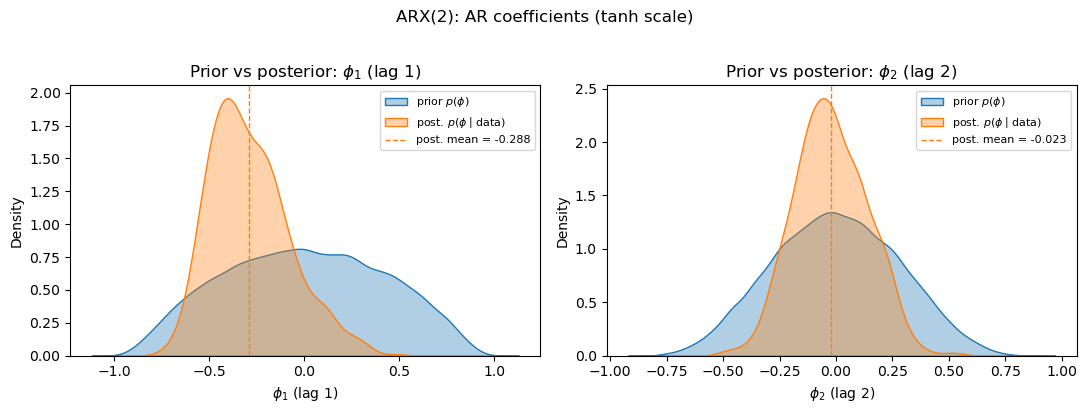

In [67]:
# ── Prior vs posterior: ARX(2) AR coefficients ──────────────────────────────
# Priors match the model definition above (change SDs here if you change them there)
SD_PHI1_RAW = 0.5
SD_PHI2_RAW = 0.3

rng = np.random.default_rng(42)
n_prior = 50_000
phi1_raw_prior = rng.normal(0.0, SD_PHI1_RAW, size=n_prior)
phi2_raw_prior = rng.normal(0.0, SD_PHI2_RAW, size=n_prior)
phi1_prior = np.tanh(phi1_raw_prior)
phi2_prior = np.tanh(phi2_raw_prior)

# Posterior on constrained phi scale from MCMC
phi1_post = np.asarray(phi1_arx2, dtype=float).ravel()
phi2_post = np.asarray(phi2_arx2, dtype=float).ravel()
# For VI posteriors instead, swap in phi1_arx2_vi / phi2_arx2_vi

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, p_prior, p_post, title in zip(
    axes,
    (phi1_prior, phi2_prior),
    (phi1_post, phi2_post),
    (r"$\phi_1$ (lag 1)", r"$\phi_2$ (lag 2)"),
):
    sns.kdeplot(p_prior, fill=True, alpha=0.35, color="C0", ax=ax, label=r"prior $p(\phi)$")
    sns.kdeplot(p_post,  fill=True, alpha=0.35, color="C1", ax=ax, label=r"post. $p(\phi \mid \mathrm{data})$")
    ax.axvline(float(np.mean(p_post)), color="C1", linestyle="--", linewidth=1,
               label=f"post. mean = {np.mean(p_post):.3f}")
    ax.set_xlabel(title)
    ax.set_title(f"Prior vs posterior: {title}")
    ax.legend(fontsize=8)

plt.suptitle("ARX(2): AR coefficients (tanh scale)", y=1.02)
plt.tight_layout()
plt.show()


### Model 4 — ARX(2) + Bayesian MLP, Indre By, MCMC

Model definition, data preparation, and MCMC inference. The non-linear feature contribution is modelled by a shallow Bayesian MLP with PyroSample weights.

[ARX2+NN PyroModule] district=Indre By, T=16, T_train=11, test=5, K=5, H=8
[ARX2+NN PyroModule] feature_cols (5): ['log_total_population_std', 'share_non_danish_std', 'log_income_per_capita_std', 'unemployment_rate_std', 'avg_household_size_std']


Sample: 100%|██████████| 1000/1000 [01:28, 11.34it/s, step size=4.26e-02, acc. prob=0.965]

[ARX2+NN PyroModule] posterior sample sites: ['hidden.bias', 'hidden.weight', 'phi1_raw', 'phi2_raw', 'readout.bias', 'readout.weight', 'sigma_g']


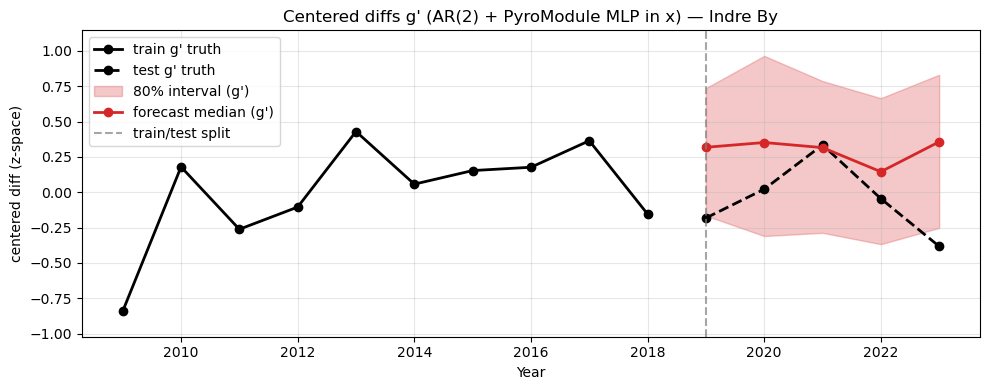

[ARX2+NN PyroModule] 2019 centered-diff error (forecast - truth): +0.5001
[ARX2+NN PyroModule] 2020 centered-diff error (forecast - truth): +0.3300
[ARX2+NN PyroModule] 2021 centered-diff error (forecast - truth): -0.0192
[ARX2+NN PyroModule] 2022 centered-diff error (forecast - truth): +0.1903
[ARX2+NN PyroModule] 2023 centered-diff error (forecast - truth): +0.7396


In [68]:
# AR(2) on centered diffs g' + nonlinear x — MLP via PyroModule + PyroSample
# g'_t = phi1 * g'_{t-1} + phi2 * g'_{t-2} + f(x_t) + eps,  f = readout(tanh(hidden(x)))


class ShallowBayesianMLP(PyroModule):
    """One hidden layer, tanh, scalar output — matches W1,b1,w2,b2 structure."""

    def __init__(self, n_in: int, n_hidden: int):
        super().__init__()
        self.hidden = PyroModule[nn.Linear](n_in, n_hidden)
        self.hidden.weight = PyroSample(
            dist.Normal(0.0, 0.5).expand([n_hidden, n_in]).to_event(2)
        )
        self.hidden.bias = PyroSample(
            dist.Normal(0.0, 0.5).expand([n_hidden]).to_event(1)
        )
        self.readout = PyroModule[nn.Linear](n_hidden, 1)
        self.readout.weight = PyroSample(
            dist.Normal(0.0, 0.5).expand([1, n_hidden]).to_event(2)
        )
        self.readout.bias = PyroSample(
            dist.Normal(0.0, 0.5).expand([1]).to_event(1)
        )
        self.act = nn.Tanh()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.readout(self.act(self.hidden(x))).squeeze(-1)


# --- settings ---
panel_df = model_panel_restricted_withfeatures
district = "Indre By"
N_TEST = 5
H_HIDDEN = 8

feature_cols = FEATURE_COLS_STD

_keep = ["year", "median_log_sqm_price", *feature_cols]
_miss = [c for c in _keep if c not in panel_df.columns]
if _miss:
    raise KeyError(f"model_panel_restricted_withfeatures missing columns {_miss}")

ts = (
    panel_df.loc[panel_df["district"] == district, ["district", *_keep]]
    .dropna()
    .sort_values("year")
    .reset_index(drop=True)
)
ts = ts[ts["year"] <= 2023].reset_index(drop=True)

years = ts["year"].to_numpy()
y = torch.tensor(ts["median_log_sqm_price"].to_numpy(), dtype=torch.float)
X = torch.tensor(ts[feature_cols].to_numpy(), dtype=torch.float)

T = len(y)
T_train = max(5, T - N_TEST)
h = T - T_train

y_mean = y[:T_train].mean()
y_std = y[:T_train].std()
y_std = y_std if y_std > 0 else torch.tensor(1.0)
y_z = (y - y_mean) / y_std

years_train, years_test = years[:T_train], years[T_train:]
y_train_z, y_test_z = y_z[:T_train], y_z[T_train:]
K = len(feature_cols)

if T_train < 4:
    raise ValueError("ARX(2) needs a longer train window (try smaller N_TEST).")

g = y_z[1:] - y_z[:-1]
X_g = X[1:]
g_train = g[: T_train - 1]
X_g_train = X_g[: T_train - 1]
g_mean = g_train.mean()
g_train_c = g_train - g_mean

if len(g_train_c) < 3:
    raise ValueError("ARX(2) needs at least 3 train diffs after centering.")

g0_c = g_train_c[-1]
g_lm2_c = g_train_c[-2]
X_g_future = X_g[T_train - 1 : T_train - 1 + h]

print(
    f"[ARX2+NN PyroModule] district={district}, T={T}, T_train={T_train}, "
    f"test={len(years_test)}, K={K}, H={H_HIDDEN}"
)
print(f"[ARX2+NN PyroModule] feature_cols ({K}): {feature_cols}")


def mlp_forward(x, W1, b1, w2, b2):
    """x [K]; W1 [H,K]; b1 [H]; w2 [H]; b2 scalar."""
    hh = torch.tanh(W1 @ x + b1)
    return (w2 * hh).sum() + b2


def arx2_mlp_model_pyromodule(g_c_obs, X_obs, mlp_net: ShallowBayesianMLP):
    Tdiff, Kloc = X_obs.shape
    if Tdiff < 3:
        raise ValueError("Need at least 3 train diff points for ARX(2).")
    
    phi1_raw = pyro.sample("phi1_raw", dist.Normal(0.0, 0.3))  # lag-1: wider prior
    phi1 = pyro.deterministic("phi1", torch.tanh(phi1_raw))
    phi2_raw = pyro.sample("phi2_raw", dist.Normal(0.0, 0.2))  # lag-2: tighter prior
    phi2 = pyro.deterministic("phi2", torch.tanh(phi2_raw))
    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    eta_all = mlp_net(X_obs).reshape(-1)

    means = torch.empty_like(eta_all)
    means[0] = eta_all[0]
    means[1] = phi1 * g_c_obs[0] + eta_all[1]
    means[2:] = phi1 * g_c_obs[1:-1] + phi2 * g_c_obs[:-2] + eta_all[2:]

    pyro.sample("g_all", dist.Normal(means, sigma_g).to_event(1), obs=g_c_obs)


def simulate_centered_diffs_arx2_mlp(phi1, phi2, W1, b1, w2, b2, sigma_g, g0_c, g_lm2_c, X_future):
    out = []
    prev1 = g0_c
    prev2 = g_lm2_c
    for t in range(X_future.shape[0]):
        mean = phi1 * prev1 + phi2 * prev2 + mlp_forward(X_future[t], W1, b1, w2, b2)
        g_new = dist.Normal(mean, sigma_g).sample()
        out.append(g_new)
        prev2, prev1 = prev1, g_new
    return torch.stack(out) if out else torch.empty((0,), dtype=torch.float)


def _post_to_wb(post_dict, s: int):
    # Find the exact keys once
    key_W1 = next(k for k in post_dict if "hidden.weight" in k)
    key_b1 = next(k for k in post_dict if "hidden.bias" in k)
    key_rw = next(k for k in post_dict if "readout.weight" in k)
    key_rb = next(k for k in post_dict if "readout.bias" in k)
    
    W1 = post_dict[key_W1][s]
    b1 = post_dict[key_b1][s]
    w2 = post_dict[key_rw][s].squeeze(0)
    b2 = post_dict[key_rb][s].squeeze()
    return W1, b1, w2, b2

mlp_net = ShallowBayesianMLP(n_in=K, n_hidden=H_HIDDEN)

pyro.set_rng_seed(3)
pyro.clear_param_store()

nuts = NUTS(partial(arx2_mlp_model_pyromodule, mlp_net=mlp_net), target_accept_prob=0.9)
mcmc = MCMC(nuts, num_samples=600, warmup_steps=400, num_chains=1)
mcmc.run(g_train_c, X_g_train)
post_nn = mcmc.get_samples()

print("[ARX2+NN PyroModule] posterior sample sites:", list(post_nn.keys()))

phi1_nn = torch.tanh(post_nn["phi1_raw"]).detach().cpu().numpy()
phi2_nn = torch.tanh(post_nn["phi2_raw"]).detach().cpu().numpy()
sig_nn = post_nn["sigma_g"].detach().cpu().numpy()

S = min(200, len(phi1_nn))
paths_g = []
for s in range(S):
    phi1_s = torch.tensor(phi1_nn[s], dtype=torch.float)
    phi2_s = torch.tensor(phi2_nn[s], dtype=torch.float)
    W1s, b1s, w2s, b2s = _post_to_wb(post_nn, s)
    W1s = W1s.to(dtype=torch.float)
    b1s = b1s.to(dtype=torch.float)
    w2s = w2s.to(dtype=torch.float)
    b2s = b2s.to(dtype=torch.float)
    sig_s = torch.tensor(sig_nn[s], dtype=torch.float)
    paths_g.append(
        simulate_centered_diffs_arx2_mlp(
            phi1_s, phi2_s, W1s, b1s, w2s, b2s, sig_s, g0_c=g0_c, g_lm2_c=g_lm2_c, X_future=X_g_future
        )
    )

paths_g = torch.stack(paths_g)
p10_g = paths_g.quantile(0.10, dim=0).detach().numpy()
p50_g = paths_g.quantile(0.50, dim=0).detach().numpy()
p90_g = paths_g.quantile(0.90, dim=0).detach().numpy()

if len(y_test_z) == 0:
    raise ValueError("No test years.")

years_train_diff = years_train[1:]
g_train_c_np = g_train_c.detach().numpy()

g_test = torch.empty_like(y_test_z)
g_test[0] = y_test_z[0] - y_train_z[-1]
if len(y_test_z) > 1:
    g_test[1:] = y_test_z[1:] - y_test_z[:-1]
g_test_c = g_test - g_mean
g_test_c_np = g_test_c.detach().numpy()

plt.figure(figsize=(10, 4))
y_lo = float(min(g_train_c_np.min(), g_test_c_np.min(), p10_g.min()))
y_hi = float(max(g_train_c_np.max(), g_test_c_np.max(), p90_g.max()))
pad = 0.10 * (y_hi - y_lo + 1e-6)
plt.ylim(y_lo - pad, y_hi + pad)
plt.plot(
    years_train_diff,
    g_train_c_np,
    marker="o",
    color="black",
    linewidth=2,
    label="train g' truth",
)
plt.plot(
    years_test,
    g_test_c_np,
    marker="o",
    color="black",
    linestyle="--",
    linewidth=2,
    label="test g' truth",
)
plt.fill_between(years_test, p10_g, p90_g, alpha=0.25, color="C3", label="80% interval (g')")
plt.plot(years_test, p50_g, marker="o", linewidth=2, color="C3", label="forecast median (g')")
plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")
plt.title(f"Centered diffs g' (AR(2) + PyroModule MLP in x) — {district}")
plt.xlabel("Year")
plt.ylabel("centered diff (z-space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for yr, e in zip(years_test, p50_g - g_test_c_np):
    print(f"[ARX2+NN PyroModule] {int(yr)} centered-diff error (forecast - truth): {e:+.4f}")

#### Model 4 — Back-transform forecast to DKK/m²

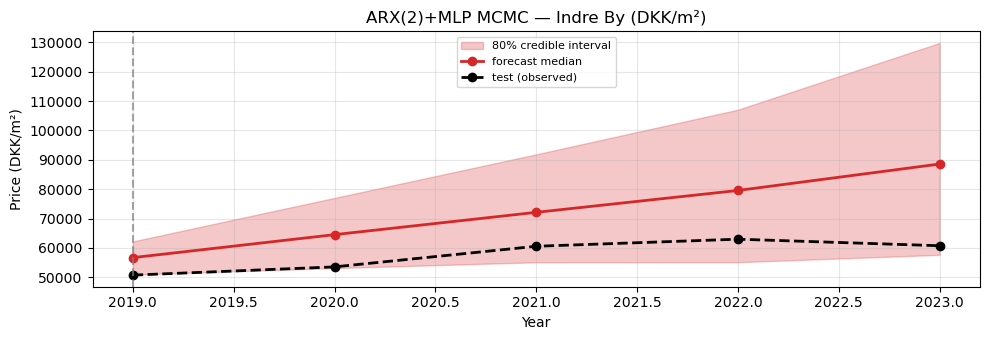

[ARX2+MLP] Indre By 2019 median error (DKK/m²): +5952.3
[ARX2+MLP] Indre By 2020 median error (DKK/m²): +10972.1
[ARX2+MLP] Indre By 2021 median error (DKK/m²): +11549.8
[ARX2+MLP] Indre By 2022 median error (DKK/m²): +16586.7
[ARX2+MLP] Indre By 2023 median error (DKK/m²): +27809.3
  [CSV] ARX(2)+NN -> results/model_comparison/ARX2plusNN_results.csv (5 rows)


In [69]:
# Back-transform: centered diffs → DKK/m²
# paths_g [S, h] and g_test_c already computed in the MCMC cell above

paths_unc   = paths_g + g_mean
paths_lev_z = y_train_z[-1] + torch.cumsum(paths_unc, dim=1)
paths_log   = paths_lev_z * y_std + y_mean
paths_price = torch.exp(paths_log)

g_test_raw   = g_test_c + g_mean
y_te_lev_z   = y_train_z[-1] + torch.cumsum(g_test_raw, dim=0)
y_te_log     = y_te_lev_z * y_std + y_mean
y_test_price = torch.exp(y_te_log).detach().numpy()

p10 = paths_price.quantile(0.10, dim=0).detach().numpy()
p50 = paths_price.quantile(0.50, dim=0).detach().numpy()
p90 = paths_price.quantile(0.90, dim=0).detach().numpy()

plt.figure(figsize=(10, 3.5))
plt.fill_between(years_test, p10, p90, alpha=0.25, color='C3', label='80% credible interval')
plt.plot(years_test, p50, marker='o', linewidth=2, color='C3', label='forecast median')
plt.plot(years_test, y_test_price, marker='o', color='black', linestyle='--', linewidth=2, label='test (observed)')
plt.axvline(years_test[0], color='grey', linestyle='--', alpha=0.7)
plt.title(f'ARX(2)+MLP MCMC — {district} (DKK/m²)')
plt.xlabel('Year')
plt.ylabel('Price (DKK/m²)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

for yr, e in zip(years_test, p50 - y_test_price):
    print(f'[ARX2+MLP] {district} {int(yr)} median error (DKK/m²): {e:+.1f}')

model_results["ARX(2)+NN"] = (p10.copy(), p50.copy(), p90.copy(), y_test_price.copy())

_save_results_csv("ARX(2)+NN", p10.copy(), p50.copy(), p90.copy(), y_test_price.copy(), district, years_test)


##### **Methodological comparison — Variational Inference (SVI):** The cell below re-fits the same model using `AutoDiagonalNormal` SVI as a comparison against MCMC above. For a low-parameter model, NUTS gives exact posterior samples; SVI is a mean-field approximation. **This is not a main result — the MCMC forecast above is the primary inference.** Outputs are in z-space centered diffs only (no back-transformation).

In [70]:
class ShallowBayesianMLP(PyroModule):
    """One hidden layer, tanh, scalar output — matches W1,b1,w2,b2 structure."""

    def __init__(self, n_in: int, n_hidden: int):
        super().__init__()
        self.hidden = PyroModule[nn.Linear](n_in, n_hidden)
        self.hidden.weight = PyroSample(
            dist.Normal(0.0, 0.5).expand([n_hidden, n_in]).to_event(2)
        )
        self.hidden.bias = PyroSample(
            dist.Normal(0.0, 0.5).expand([n_hidden]).to_event(1)
        )
        self.readout = PyroModule[nn.Linear](n_hidden, 1)
        self.readout.weight = PyroSample(
            dist.Normal(0.0, 0.5).expand([1, n_hidden]).to_event(2)
        )
        self.readout.bias = PyroSample(
            dist.Normal(0.0, 0.5).expand([1]).to_event(1)
        )
        self.act = nn.Tanh()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.readout(self.act(self.hidden(x))).squeeze(-1)


# --- settings ---
panel_df = model_panel_restricted_withfeatures
district = "Indre By"
N_TEST = 5
H_HIDDEN = 8

feature_cols = FEATURE_COLS_STD

_keep = ["year", "median_log_sqm_price", *feature_cols]
_miss = [c for c in _keep if c not in panel_df.columns]
if _miss:
    raise KeyError(f"model_panel_restricted_withfeatures missing columns {_miss}")

ts = (
    panel_df.loc[panel_df["district"] == district, ["district", *_keep]]
    .dropna()
    .sort_values("year")
    .reset_index(drop=True)
)
ts = ts[ts["year"] <= 2023].reset_index(drop=True)

years = ts["year"].to_numpy()
y = torch.tensor(ts["median_log_sqm_price"].to_numpy(), dtype=torch.float)
X = torch.tensor(ts[feature_cols].to_numpy(), dtype=torch.float)

T = len(y)
T_train = max(5, T - N_TEST)
h = T - T_train

y_mean = y[:T_train].mean()
y_std = y[:T_train].std()
y_std = y_std if y_std > 0 else torch.tensor(1.0)
y_z = (y - y_mean) / y_std

years_train, years_test = years[:T_train], years[T_train:]
y_train_z, y_test_z = y_z[:T_train], y_z[T_train:]
K = len(feature_cols)

if T_train < 4:
    raise ValueError("ARX(2) needs a longer train window (try smaller N_TEST).")

g = y_z[1:] - y_z[:-1]
X_g = X[1:]
g_train = g[: T_train - 1]
X_g_train = X_g[: T_train - 1]
g_mean = g_train.mean()
g_train_c = g_train - g_mean

if len(g_train_c) < 3:
    raise ValueError("ARX(2) needs at least 3 train diffs after centering.")

g0_c = g_train_c[-1]
g_lm2_c = g_train_c[-2]
X_g_future = X_g[T_train - 1 : T_train - 1 + h]

print(
    f"[ARX2+NN VI] district={district}, T={T}, T_train={T_train}, "
    f"test={len(years_test)}, K={K}, H={H_HIDDEN}"
)
print(f"[ARX2+NN VI] feature_cols ({K}): {feature_cols}")


def mlp_forward(x, W1, b1, w2, b2):
    """x [K]; W1 [H,K]; b1 [H]; w2 [H]; b2 scalar."""
    hh = torch.tanh(W1 @ x + b1)
    return (w2 * hh).sum() + b2


def arx2_mlp_model_pyromodule(g_c_obs, X_obs, mlp_net: ShallowBayesianMLP):
    Tdiff, Kloc = X_obs.shape
    if Tdiff < 3:
        raise ValueError("Need at least 3 train diff points for ARX(2).")
    
    phi1_raw = pyro.sample("phi1_raw", dist.Normal(0.0, 0.5))
    phi1 = pyro.deterministic("phi1", torch.tanh(phi1_raw))
    phi2_raw = pyro.sample("phi2_raw", dist.Normal(0.0, 0.3))
    phi2 = pyro.deterministic("phi2", torch.tanh(phi2_raw))
    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(.0))

    eta_all = mlp_net(X_obs).reshape(-1)

    means = torch.empty_like(eta_all)
    means[0] = eta_all[0]
    means[1] = phi1 * g_c_obs[0] + eta_all[1]
    means[2:] = phi1 * g_c_obs[1:-1] + phi2 * g_c_obs[:-2] + eta_all[2:]

    pyro.sample("g_all", dist.Normal(means, sigma_g).to_event(1), obs=g_c_obs)


def simulate_centered_diffs_arx2_mlp(phi1, phi2, W1, b1, w2, b2, sigma_g, g0_c, g_lm2_c, X_future):
    out = []
    prev1 = g0_c
    prev2 = g_lm2_c
    for t in range(X_future.shape[0]):
        mean = phi1 * prev1 + phi2 * prev2 + mlp_forward(X_future[t], W1, b1, w2, b2)
        g_new = dist.Normal(mean, sigma_g).sample()
        out.append(g_new)
        prev2, prev1 = prev1, g_new
    return torch.stack(out) if out else torch.empty((0,), dtype=torch.float)


def _post_to_wb(post_dict, s: int):
    W1 = next(v[s] for k, v in post_dict.items() if k.endswith("hidden.weight"))
    b1 = next(v[s] for k, v in post_dict.items() if k.endswith("hidden.bias"))
    rw = next(v[s] for k, v in post_dict.items() if k.endswith("readout.weight"))
    rb = next(v[s] for k, v in post_dict.items() if k.endswith("readout.bias"))
    w2 = rw.squeeze(0)
    b2 = rb.squeeze()
    return W1, b1, w2, b2


mlp_net = ShallowBayesianMLP(n_in=K, n_hidden=H_HIDDEN)

pyro.set_rng_seed(3)
pyro.clear_param_store()

model_fn = partial(arx2_mlp_model_pyromodule, mlp_net=mlp_net)

guide_nn = AutoDiagonalNormal(model_fn)
optimizer = Adam({"lr": 0.01})
elbo = Trace_ELBO()
svi = SVI(model_fn, guide_nn, optimizer, elbo)

num_steps = 4000
for step in range(num_steps):
    loss = svi.step(g_train_c, X_g_train)
    if step % 500 == 0 or step == num_steps - 1:
        print(f"[ARX2+NN VI] SVI step {step:5d}  ELBO loss: {loss:.2f}")

# Discover site names (PyroModule naming can vary by version)
with torch.no_grad():
    probe = Predictive(
        model_fn,
        guide=guide_nn,
        num_samples=1,
        return_sites=None,
        parallel=False,
    )(g_train_c, X_g_train)

print("[ARX2+NN VI] Predictive probe keys:", sorted(probe.keys()))

wanted = ("phi1_raw", "phi2_raw", "sigma_g")
mlp_keys = [
    k
    for k in probe.keys()
    if k.endswith(("hidden.weight", "hidden.bias", "readout.weight", "readout.bias"))
]
return_sites = tuple(dict.fromkeys([*wanted, *mlp_keys]))

missing = [s for s in wanted if s not in probe]
if missing:
    raise KeyError(f"Missing required sites {missing}. Inspect probe keys printed above.")

S_vi = 500
with torch.no_grad():
    pred = Predictive(
        model_fn,
        guide=guide_nn,
        num_samples=S_vi,
        return_sites=return_sites,
        parallel=False,
    )
    post_nn = pred(g_train_c, X_g_train)

print("[ARX2+NN VI] predictive sites:", list(post_nn.keys()))

phi1_nn = torch.tanh(post_nn["phi1_raw"].reshape(-1)).detach().cpu().numpy()
phi2_nn = torch.tanh(post_nn["phi2_raw"].reshape(-1)).detach().cpu().numpy()
sig_nn = post_nn["sigma_g"].reshape(-1).detach().cpu().numpy()

S = min(200, len(phi1_nn))
paths_g = []
for s in range(S):
    phi1_s = torch.tensor(phi1_nn[s], dtype=torch.float)
    phi2_s = torch.tensor(phi2_nn[s], dtype=torch.float)
    W1s, b1s, w2s, b2s = _post_to_wb(post_nn, s)
    W1s = W1s.to(dtype=torch.float)
    b1s = b1s.to(dtype=torch.float)
    w2s = w2s.to(dtype=torch.float)
    b2s = b2s.to(dtype=torch.float)
    sig_s = torch.tensor(sig_nn[s], dtype=torch.float)
    paths_g.append(
        simulate_centered_diffs_arx2_mlp(
            phi1_s, phi2_s, W1s, b1s, w2s, b2s, sig_s, g0_c=g0_c, g_lm2_c=g_lm2_c, X_future=X_g_future
        )
    )

paths_g = torch.stack(paths_g)
p10_g = paths_g.quantile(0.10, dim=0).detach().numpy()
p50_g = paths_g.quantile(0.50, dim=0).detach().numpy()
p90_g = paths_g.quantile(0.90, dim=0).detach().numpy()

if len(y_test_z) == 0:
    raise ValueError("No test years.")

years_train_diff = years_train[1:]
g_train_c_np = g_train_c.detach().numpy()

g_test = torch.empty_like(y_test_z)
g_test[0] = y_test_z[0] - y_train_z[-1]
if len(y_test_z) > 1:
    g_test[1:] = y_test_z[1:] - y_test_z[:-1]
g_test_c = g_test - g_mean
g_test_c_np = g_test_c.detach().numpy()

plt.figure(figsize=(10, 4))
y_lo = float(min(g_train_c_np.min(), g_test_c_np.min(), p10_g.min()))
y_hi = float(max(g_train_c_np.max(), g_test_c_np.max(), p90_g.max()))
pad = 0.10 * (y_hi - y_lo + 1e-6)
plt.ylim(y_lo - pad, y_hi + pad)
plt.plot(
    years_train_diff,
    g_train_c_np,
    marker="o",
    color="black",
    linewidth=2,
    label="train g' truth",
)
plt.plot(
    years_test,
    g_test_c_np,
    marker="o",
    color="black",
    linestyle="--",
    linewidth=2,
    label="test g' truth",
)
plt.fill_between(years_test, p10_g, p90_g, alpha=0.25, color="C3", label="80% interval (g') VI")
plt.plot(years_test, p50_g, marker="o", linewidth=2, color="C3", label="forecast median (g') VI")
plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")
plt.title(f"Centered diffs g' (AR(2) + PyroModule MLP, VI) — {district}")
plt.xlabel("Year")
plt.ylabel("centered diff (z-space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for yr, e in zip(years_test, p50_g - g_test_c_np):
    print(f"[ARX2+NN VI] {int(yr)} centered-diff error (forecast - truth): {e:+.4f}")

[ARX2+NN VI] district=Indre By, T=16, T_train=11, test=5, K=5, H=8
[ARX2+NN VI] feature_cols (5): ['log_total_population_std', 'share_non_danish_std', 'log_income_per_capita_std', 'unemployment_rate_std', 'avg_household_size_std']


ValueError: Expected parameter scale (Tensor of shape ()) of distribution HalfNormal() to satisfy the constraint GreaterThan(lower_bound=0.0), but found invalid values:
0.0
Trace Shapes:  
 Param Sites:  
Sample Sites:  
phi1_raw dist |
        value |
phi2_raw dist |
        value |
Trace Shapes:
 Param Sites:
Sample Sites:

### Model 5 — Hierarchical ARX(1) Linear, All Districts, NUTS

#### Model 5 — Hierarchical ARX(1) linear, no SEM — data preparation, model definition, NUTS inference, and forecast

[HARX-linear] D=9, T=16, T_train=11, L=10, h=5, K=5


Sample: 100%|██████████| 1000/1000 [00:42, 23.31it/s, step size=1.59e-01, acc. prob=0.793]


[HARX-linear] sigma_g mean: 0.4122597575187683
[HARX-linear] tau_phi mean: 0.1348911076784134
[HARX-linear] phi_d posterior means: [-0.158 -0.125 -0.146 -0.195 -0.123 -0.165 -0.194 -0.135 -0.166]
[HARX-linear] beta posterior means:
    log_total_population_std: +0.062
    share_non_danish_std: +0.139
    log_income_per_capita_std: +0.410
    unemployment_rate_std: +0.217
    avg_household_size_std: +0.059


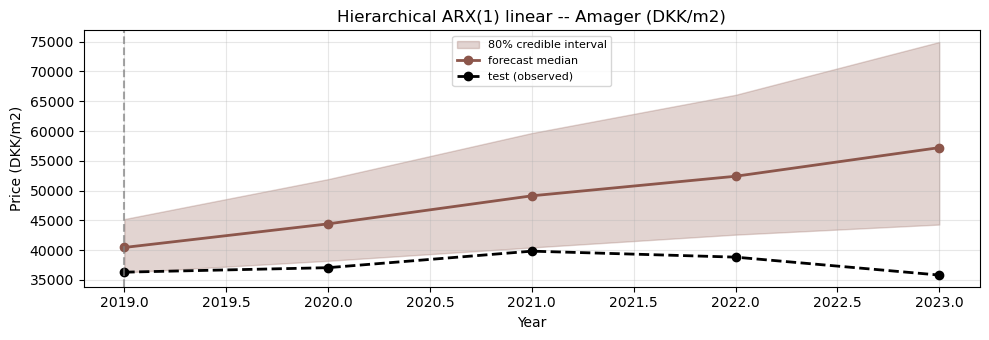

[HARX-linear] Amager 2019 median error (DKK/m2): +4147.0
[HARX-linear] Amager 2020 median error (DKK/m2): +7352.3
[HARX-linear] Amager 2021 median error (DKK/m2): +9287.7
[HARX-linear] Amager 2022 median error (DKK/m2): +13574.7
[HARX-linear] Amager 2023 median error (DKK/m2): +21388.2


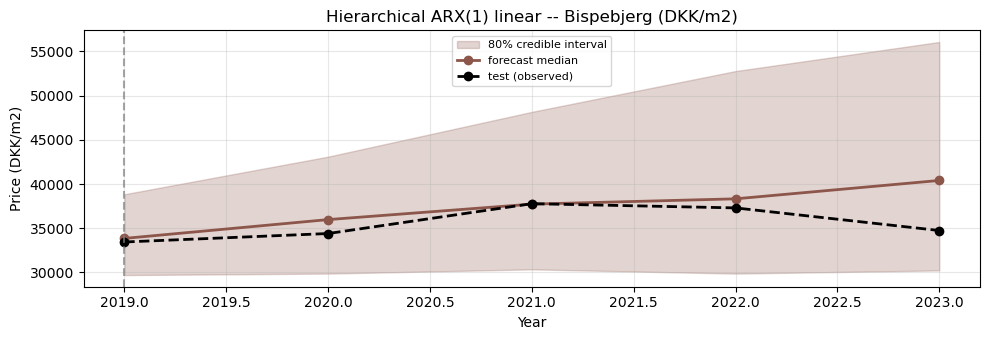

[HARX-linear] Bispebjerg 2019 median error (DKK/m2): +405.4
[HARX-linear] Bispebjerg 2020 median error (DKK/m2): +1576.0
[HARX-linear] Bispebjerg 2021 median error (DKK/m2): -51.0
[HARX-linear] Bispebjerg 2022 median error (DKK/m2): +1027.8
[HARX-linear] Bispebjerg 2023 median error (DKK/m2): +5662.5


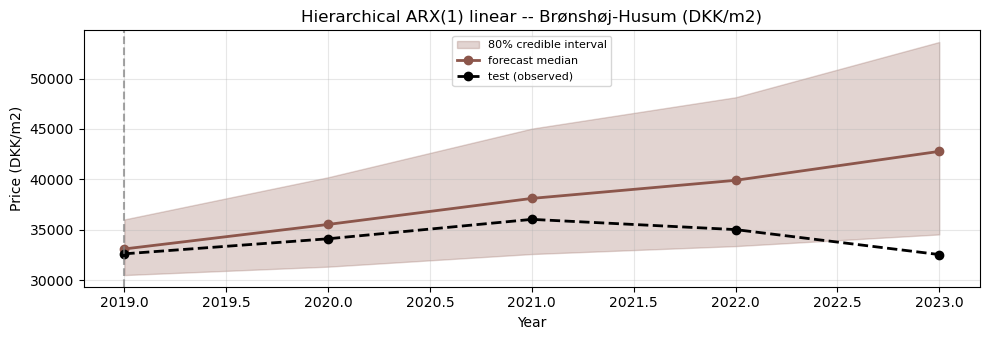

[HARX-linear] Brønshøj-Husum 2019 median error (DKK/m2): +483.3
[HARX-linear] Brønshøj-Husum 2020 median error (DKK/m2): +1421.8
[HARX-linear] Brønshøj-Husum 2021 median error (DKK/m2): +2079.1
[HARX-linear] Brønshøj-Husum 2022 median error (DKK/m2): +4886.3
[HARX-linear] Brønshøj-Husum 2023 median error (DKK/m2): +10231.2


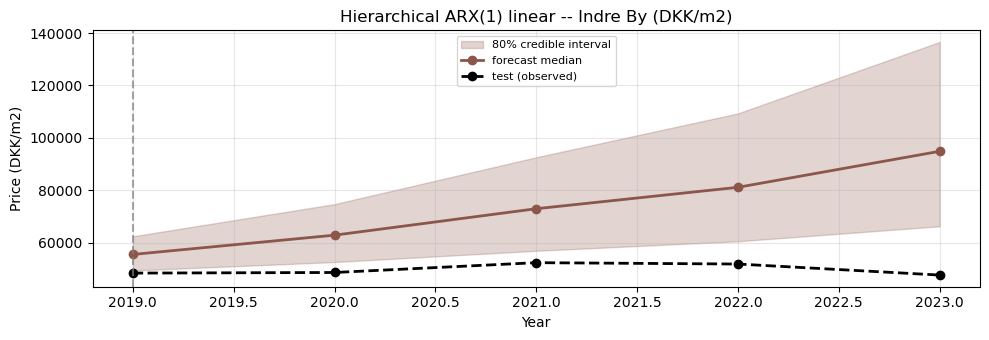

[HARX-linear] Indre By 2019 median error (DKK/m2): +7131.0
[HARX-linear] Indre By 2020 median error (DKK/m2): +14254.0
[HARX-linear] Indre By 2021 median error (DKK/m2): +20609.7
[HARX-linear] Indre By 2022 median error (DKK/m2): +29307.5
[HARX-linear] Indre By 2023 median error (DKK/m2): +47269.1


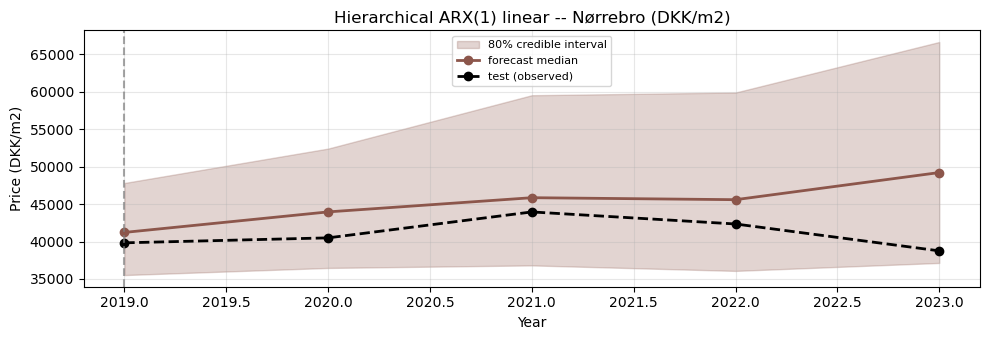

[HARX-linear] Nørrebro 2019 median error (DKK/m2): +1389.8
[HARX-linear] Nørrebro 2020 median error (DKK/m2): +3470.4
[HARX-linear] Nørrebro 2021 median error (DKK/m2): +1902.2
[HARX-linear] Nørrebro 2022 median error (DKK/m2): +3248.2
[HARX-linear] Nørrebro 2023 median error (DKK/m2): +10464.6


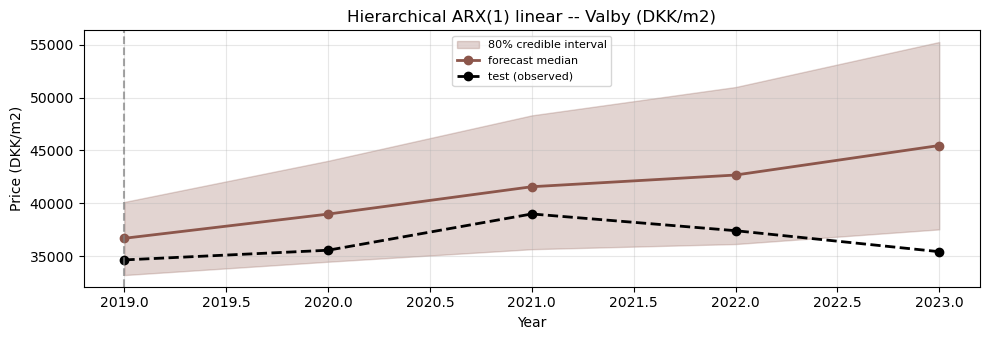

[HARX-linear] Valby 2019 median error (DKK/m2): +2046.7
[HARX-linear] Valby 2020 median error (DKK/m2): +3419.4
[HARX-linear] Valby 2021 median error (DKK/m2): +2575.4
[HARX-linear] Valby 2022 median error (DKK/m2): +5265.4
[HARX-linear] Valby 2023 median error (DKK/m2): +10044.6


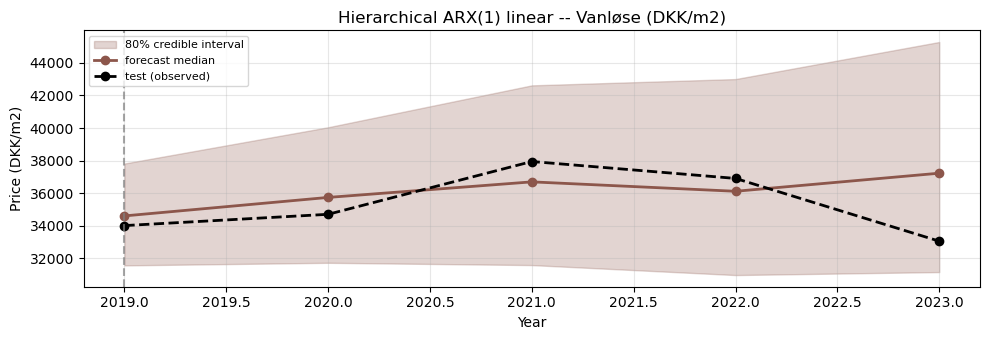

[HARX-linear] Vanløse 2019 median error (DKK/m2): +593.3
[HARX-linear] Vanløse 2020 median error (DKK/m2): +1035.6
[HARX-linear] Vanløse 2021 median error (DKK/m2): -1248.6
[HARX-linear] Vanløse 2022 median error (DKK/m2): -788.3
[HARX-linear] Vanløse 2023 median error (DKK/m2): +4169.1


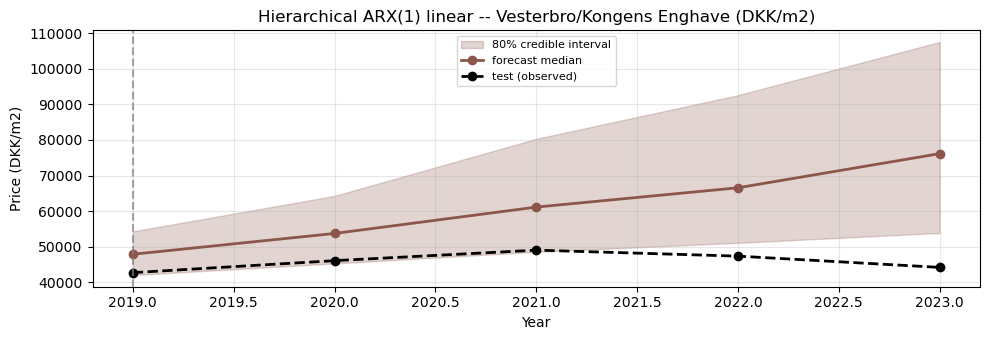

[HARX-linear] Vesterbro/Kongens Enghave 2019 median error (DKK/m2): +5168.8
[HARX-linear] Vesterbro/Kongens Enghave 2020 median error (DKK/m2): +7643.6
[HARX-linear] Vesterbro/Kongens Enghave 2021 median error (DKK/m2): +12095.5
[HARX-linear] Vesterbro/Kongens Enghave 2022 median error (DKK/m2): +19211.7
[HARX-linear] Vesterbro/Kongens Enghave 2023 median error (DKK/m2): +31961.1


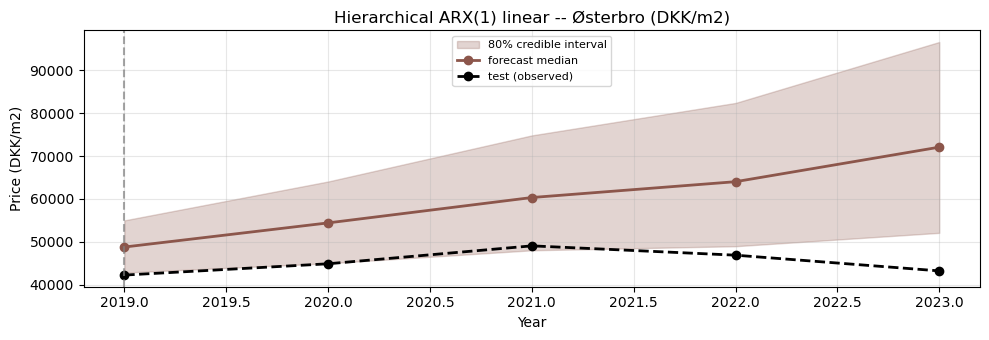

[HARX-linear] Østerbro 2019 median error (DKK/m2): +6538.5
[HARX-linear] Østerbro 2020 median error (DKK/m2): +9534.3
[HARX-linear] Østerbro 2021 median error (DKK/m2): +11270.0
[HARX-linear] Østerbro 2022 median error (DKK/m2): +17137.0
[HARX-linear] Østerbro 2023 median error (DKK/m2): +28852.0
[HARX-linear no-SEM] posterior saved as _nosem variables


In [ ]:
# Hierarchical ARX(1) on g' — district-specific phi_d, shared linear beta
# Hyperpriors: mu_phi_raw, tau_phi (partial pooling on AR coefficient)
# Shared: beta [K], sigma_g

N_TEST = 5

panel_df = model_panel_restricted_withfeatures

FEATURE_COLS_STD = [
    "log_total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
]

_keep = ["district", "year", "median_log_sqm_price", *FEATURE_COLS_STD]
_miss = [c for c in _keep if c not in panel_df.columns]
if _miss:
    raise KeyError(f"model_panel_restricted_withfeatures missing columns {_miss}")

years_all = np.sort(panel_df.loc[panel_df["year"] <= 2023, "year"].unique())
districts = sorted(panel_df["district"].unique())
D = len(districts)
T = len(years_all)
T_train = max(5, T - N_TEST)
h = T - T_train
L = T_train - 1
K = len(FEATURE_COLS_STD)

if L < 2:
    raise ValueError("Need L >= 2 train diffs per district.")

years_train = years_all[:T_train]
years_test  = years_all[T_train:]


def _block_one_district(dname):
    sub = (
        panel_df.loc[panel_df["district"] == dname, _keep]
        .dropna()
        .sort_values("year")
    )
    sub = sub[sub["year"].isin(years_all)].copy()
    if sub["year"].nunique() != T:
        miss = sorted(set(years_all) - set(sub["year"].unique()))
        raise ValueError(f"District {dname!r} missing years: {miss}")
    sub = sub.set_index("year").loc[years_all].reset_index()

    y = torch.tensor(sub["median_log_sqm_price"].to_numpy(), dtype=torch.float)
    X = torch.tensor(sub[FEATURE_COLS_STD].to_numpy(), dtype=torch.float)

    # Standardise using TRAIN statistics only
    y_mean = y[:T_train].mean()
    y_std  = y[:T_train].std()
    y_std  = y_std if y_std > 0 else torch.tensor(1.0)
    y_z = (y - y_mean) / y_std

    y_train_z = y_z[:T_train]
    y_test_z  = y_z[T_train:]

    g    = y_z[1:] - y_z[:-1]
    X_g  = X[1:]

    g_train   = g[:L]
    X_g_train = X_g[:L]
    g_mean    = g_train.mean()
    g_train_c = g_train - g_mean
    g0_c      = g_train_c[-1]

    X_g_future = X_g[T_train - 1 : T_train - 1 + h]

    g_test = torch.empty_like(y_test_z)
    if len(y_test_z):
        g_test[0] = y_test_z[0] - y_train_z[-1]
        if len(y_test_z) > 1:
            g_test[1:] = y_test_z[1:] - y_test_z[:-1]
    g_test_c = g_test - g_mean if len(y_test_z) else torch.empty(0)

    return {
        "g_train_c":  g_train_c,
        "X_g_train":  X_g_train,
        "g0_c":       g0_c,
        "X_g_future": X_g_future,
        "g_test_c":   g_test_c,
        "g_mean":     g_mean,
        "y_mean":     y_mean,
        "y_std":      y_std,
        "y_last_z":   y_train_z[-1],
    }


blocks = [_block_one_district(d) for d in districts]

g_train_c_D  = torch.stack([b["g_train_c"]  for b in blocks], dim=0)  # [D, L]
X_g_train_D  = torch.stack([b["X_g_train"]  for b in blocks], dim=0)  # [D, L, K]
g0_c_D       = torch.stack([b["g0_c"]       for b in blocks], dim=0)  # [D]
X_g_future_D = torch.stack([b["X_g_future"] for b in blocks], dim=0)  # [D, h, K]
g_test_c_D   = torch.stack([b["g_test_c"]   for b in blocks], dim=0)  # [D, h]
g_mean_D     = torch.stack([b["g_mean"]     for b in blocks])          # [D]
y_mean_D     = torch.stack([b["y_mean"]     for b in blocks])          # [D]
y_std_D      = torch.stack([b["y_std"]      for b in blocks])          # [D]
y_last_z_D   = torch.stack([b["y_last_z"]   for b in blocks])          # [D]

print(f"[HARX-linear] D={D}, T={T}, T_train={T_train}, L={L}, h={h}, K={K}")


# Model: district-specific phi_d (partial pooling), shared beta and sigma_g
def hierarchical_arx1_linear_model(g_obs, X_obs):
    D_, L_, K_ = X_obs.shape

    mu_phi_raw = pyro.sample("mu_phi_raw", dist.Normal(0.0, 0.5))
    tau_phi    = pyro.sample("tau_phi",    dist.HalfNormal(2.0))

    with pyro.plate("districts", D_):
        phi_raw_d = pyro.sample("phi_raw_d", dist.Normal(mu_phi_raw, tau_phi))
    phi_d = torch.tanh(phi_raw_d)  # [D], constrained to (-1, 1)

    beta    = pyro.sample("beta",    dist.Normal(0.0, 0.5).expand([K_]).to_event(1))
    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    for d in range(D_):
        mean0 = X_obs[d, 0, :] @ beta
        pyro.sample(f"g0_{d}", dist.Normal(mean0, sigma_g), obs=g_obs[d, 0])

        mean_rest = phi_d[d] * g_obs[d, :-1] + X_obs[d, 1:, :] @ beta
        pyro.sample(f"g_rest_{d}",
                    dist.Normal(mean_rest, sigma_g).to_event(1),
                    obs=g_obs[d, 1:])


# Inference
pyro.set_rng_seed(21)
pyro.clear_param_store()

nuts = NUTS(hierarchical_arx1_linear_model, target_accept_prob=0.85)
mcmc = MCMC(nuts, num_samples=600, warmup_steps=400, num_chains=1)
mcmc.run(g_train_c_D, X_g_train_D)
post_h = mcmc.get_samples()

phi_d_s = np.tanh(post_h["phi_raw_d"].detach().cpu().numpy())  # [S, D]
beta_s  = post_h["beta"].detach().cpu().numpy()                 # [S, K]
sig_s   = post_h["sigma_g"].detach().cpu().numpy()              # [S]

print("[HARX-linear] sigma_g mean:", float(sig_s.mean()))
print("[HARX-linear] tau_phi mean:", float(post_h["tau_phi"].mean()))
print("[HARX-linear] phi_d posterior means:", np.round(phi_d_s.mean(axis=0), 3))
print("[HARX-linear] beta posterior means:")
for name, m in zip(FEATURE_COLS_STD, beta_s.mean(axis=0)):
    print(f"    {name}: {m:+.3f}")


# Posterior predictive + back-transformation to DKK/m2
if h == 0:
    raise ValueError("No test years.")

S = min(600, phi_d_s.shape[0])

p10_all_nosem, p50_all_nosem, p90_all_nosem, obs_all_nosem = [], [], [], []
for d_idx, dname in enumerate(districts):
    paths = []
    for s in range(S):
        ph = torch.tensor(phi_d_s[s, d_idx], dtype=torch.float)
        b  = torch.tensor(beta_s[s],          dtype=torch.float)
        sg = torch.tensor(sig_s[s],            dtype=torch.float)

        out  = []
        prev = g0_c_D[d_idx]
        for t in range(X_g_future_D[d_idx].shape[0]):
            mean = ph * prev + X_g_future_D[d_idx][t] @ b
            prev = dist.Normal(mean, sg).sample()
            out.append(prev)
        paths.append(torch.stack(out))

    paths_g = torch.stack(paths)  # [S, h]

    paths_unc   = paths_g  # no g_mean: forecast relative to 2023 level
    paths_lev_z = y_last_z_D[d_idx] + torch.cumsum(paths_unc, dim=1)
    paths_log   = paths_lev_z * y_std_D[d_idx] + y_mean_D[d_idx]
    paths_price = torch.exp(paths_log)

    p10 = paths_price.quantile(0.10, dim=0).detach().numpy()
    p50 = paths_price.quantile(0.50, dim=0).detach().numpy()
    p90 = paths_price.quantile(0.90, dim=0).detach().numpy()

    g_te_raw     = g_test_c_D[d_idx]  # no g_mean: consistent with forecast convention
    y_te_lev_z   = y_last_z_D[d_idx] + torch.cumsum(g_te_raw, dim=0)
    y_te_log     = y_te_lev_z * y_std_D[d_idx] + y_mean_D[d_idx]
    y_test_price = torch.exp(y_te_log).detach().numpy()
    p10_all_nosem.append(p10); p50_all_nosem.append(p50)
    p90_all_nosem.append(p90); obs_all_nosem.append(y_test_price)

    plt.figure(figsize=(10, 3.5))
    plt.fill_between(years_test, p10, p90, alpha=0.25, color="C5",
                     label="80% credible interval")
    plt.plot(years_test, p50, marker="o", linewidth=2, color="C5",
             label="forecast median")
    plt.plot(years_test, y_test_price, marker="o", color="black",
             linestyle="--", linewidth=2, label="test (observed)")
    plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7)
    plt.title(f"Hierarchical ARX(1) linear -- {dname} (DKK/m2)")
    plt.xlabel("Year")
    plt.ylabel("Price (DKK/m2)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    for yr, e in zip(years_test, p50 - y_test_price):
        print(f"[HARX-linear] {dname} {int(yr)} median error (DKK/m2): {e:+.1f}")

model_results["H-ARX(1)"] = (
    np.stack(p10_all_nosem), np.stack(p50_all_nosem),
    np.stack(p90_all_nosem), np.stack(obs_all_nosem),
)

# ── Save no-SEM posterior for comparison table ───────────────────────────────
phi_d_s_nosem      = phi_d_s.copy()
beta_s_nosem       = beta_s.copy()
sig_s_nosem        = sig_s.copy()
g0_c_D_nosem       = g0_c_D.clone()
X_g_future_D_nosem = X_g_future_D.clone()
g_test_c_D_nosem   = g_test_c_D.clone()
g_mean_D_nosem     = g_mean_D.clone()
y_last_z_D_nosem   = y_last_z_D.clone()
y_std_D_nosem      = y_std_D.clone()
y_mean_D_nosem     = y_mean_D.clone()
print("[HARX-linear no-SEM] posterior saved as _nosem variables")

_save_results_csv("H-ARX(1)", *model_results["H-ARX(1)"], list(districts), years_test)


#### Model 5 — Hierarchical ARX(1) linear with SEM observation noise — data preparation, model definition, NUTS inference, and forecast

[HARX-linear] D=9, T=16, T_train=11, L=10, h=5, K=5
[HARX-linear] SEM range across all district-years: 0.0087 -- 0.0698


Warmup:   0%|          | 0/1000 [00:00, ?it/s]

Sample: 100%|██████████| 1000/1000 [00:50, 19.85it/s, step size=1.33e-01, acc. prob=0.797]


[HARX-linear] sigma_g mean: 0.4082449674606323
[HARX-linear] tau_phi mean: 0.121563620865345
[HARX-linear] phi_d posterior means: [-0.172 -0.14  -0.163 -0.202 -0.138 -0.169 -0.195 -0.154 -0.162]
[HARX-linear] beta posterior means:
    log_total_population_std: +0.055
    share_non_danish_std: +0.138
    log_income_per_capita_std: +0.407
    unemployment_rate_std: +0.208
    avg_household_size_std: +0.057


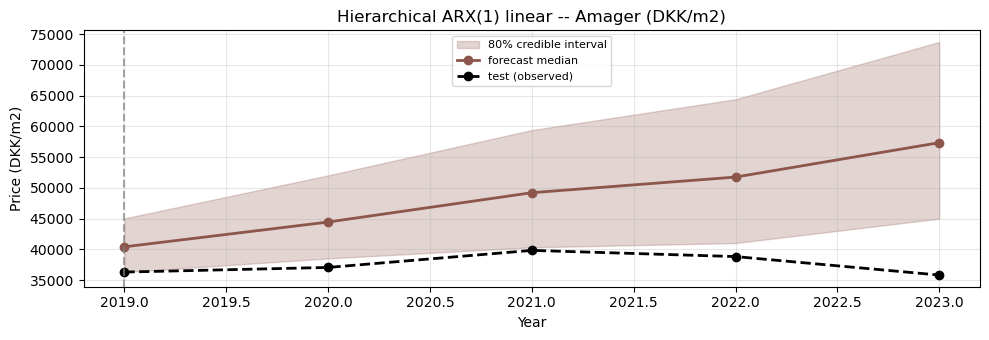

[HARX-linear] Amager 2019 median error (DKK/m2): +4107.4
[HARX-linear] Amager 2020 median error (DKK/m2): +7385.0
[HARX-linear] Amager 2021 median error (DKK/m2): +9383.8
[HARX-linear] Amager 2022 median error (DKK/m2): +12931.9
[HARX-linear] Amager 2023 median error (DKK/m2): +21538.1


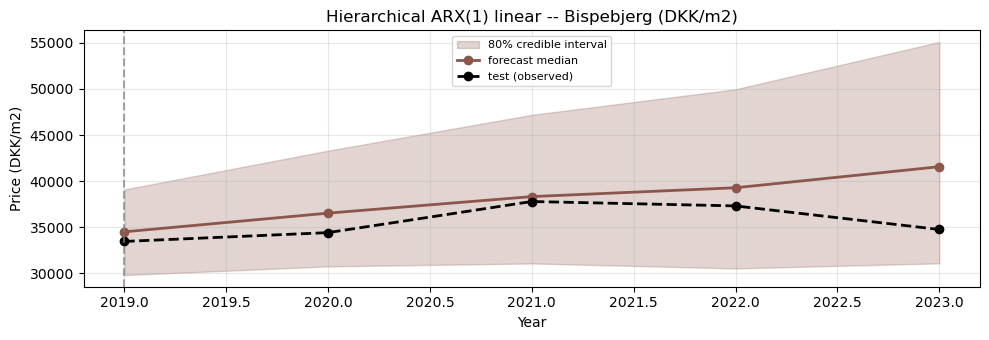

[HARX-linear] Bispebjerg 2019 median error (DKK/m2): +1044.8
[HARX-linear] Bispebjerg 2020 median error (DKK/m2): +2114.5
[HARX-linear] Bispebjerg 2021 median error (DKK/m2): +534.5
[HARX-linear] Bispebjerg 2022 median error (DKK/m2): +1971.9
[HARX-linear] Bispebjerg 2023 median error (DKK/m2): +6813.0


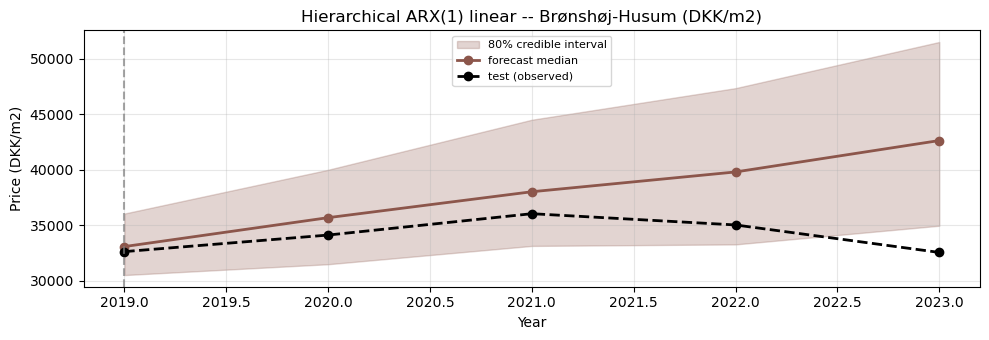

[HARX-linear] Brønshøj-Husum 2019 median error (DKK/m2): +454.2
[HARX-linear] Brønshøj-Husum 2020 median error (DKK/m2): +1567.1
[HARX-linear] Brønshøj-Husum 2021 median error (DKK/m2): +1978.5
[HARX-linear] Brønshøj-Husum 2022 median error (DKK/m2): +4776.0
[HARX-linear] Brønshøj-Husum 2023 median error (DKK/m2): +10082.3


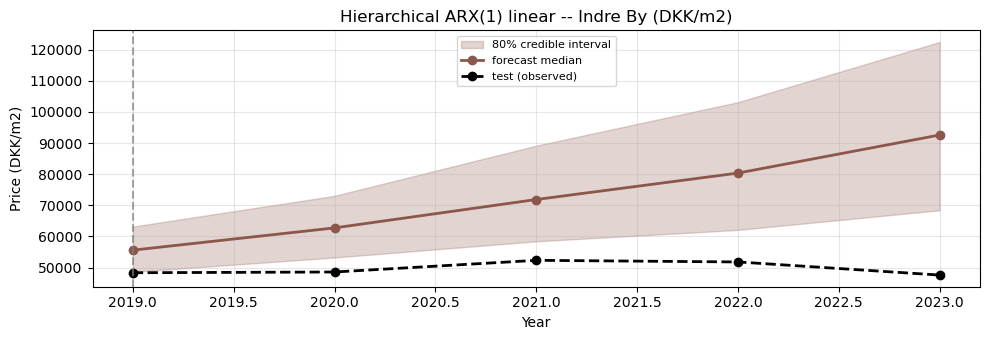

[HARX-linear] Indre By 2019 median error (DKK/m2): +7252.9
[HARX-linear] Indre By 2020 median error (DKK/m2): +14162.4
[HARX-linear] Indre By 2021 median error (DKK/m2): +19527.1
[HARX-linear] Indre By 2022 median error (DKK/m2): +28534.4
[HARX-linear] Indre By 2023 median error (DKK/m2): +44973.1


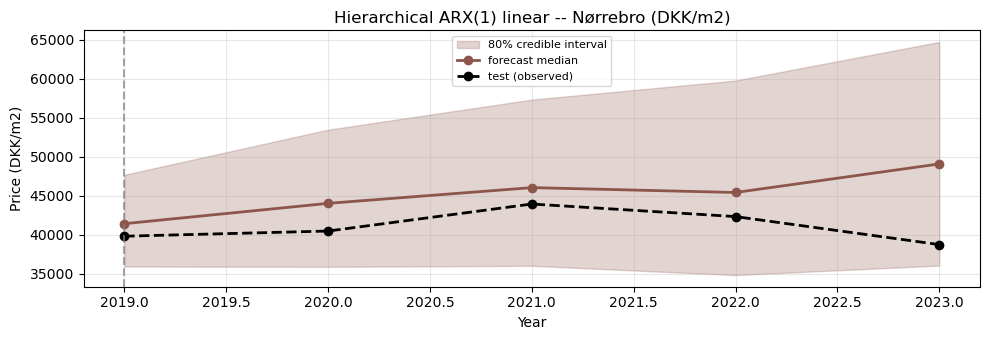

[HARX-linear] Nørrebro 2019 median error (DKK/m2): +1606.0
[HARX-linear] Nørrebro 2020 median error (DKK/m2): +3552.7
[HARX-linear] Nørrebro 2021 median error (DKK/m2): +2103.5
[HARX-linear] Nørrebro 2022 median error (DKK/m2): +3088.9
[HARX-linear] Nørrebro 2023 median error (DKK/m2): +10341.6


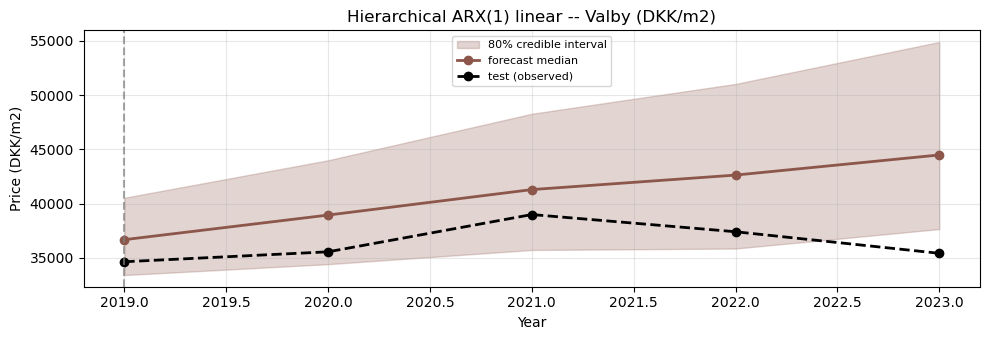

[HARX-linear] Valby 2019 median error (DKK/m2): +2034.6
[HARX-linear] Valby 2020 median error (DKK/m2): +3384.1
[HARX-linear] Valby 2021 median error (DKK/m2): +2299.8
[HARX-linear] Valby 2022 median error (DKK/m2): +5219.5
[HARX-linear] Valby 2023 median error (DKK/m2): +9060.4


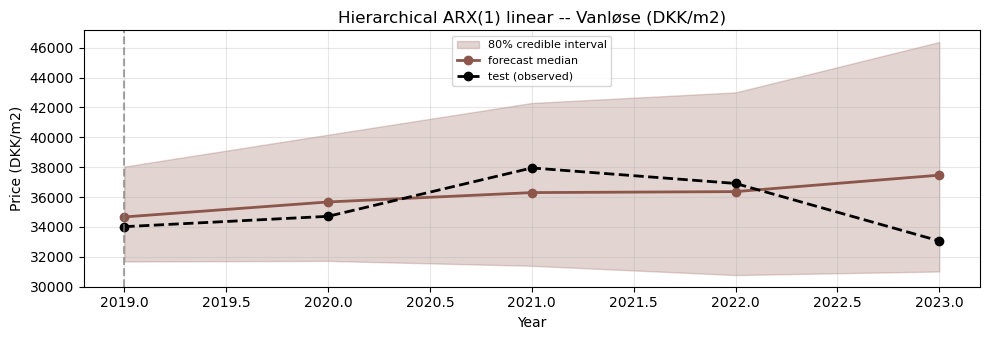

[HARX-linear] Vanløse 2019 median error (DKK/m2): +651.5
[HARX-linear] Vanløse 2020 median error (DKK/m2): +961.2
[HARX-linear] Vanløse 2021 median error (DKK/m2): -1650.5
[HARX-linear] Vanløse 2022 median error (DKK/m2): -546.9
[HARX-linear] Vanløse 2023 median error (DKK/m2): +4402.8


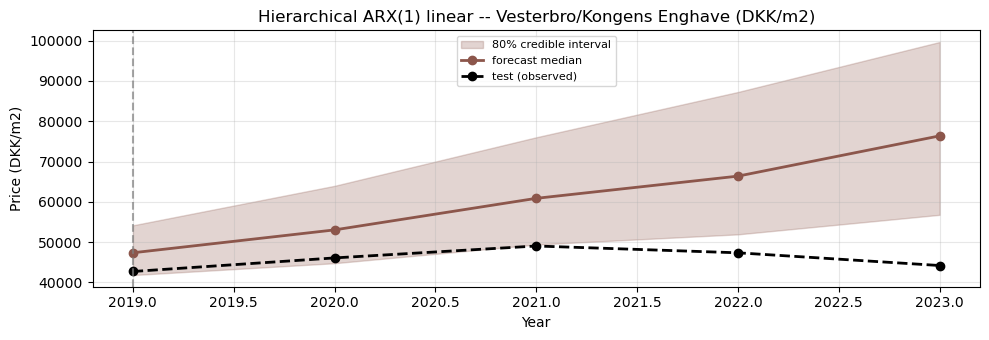

[HARX-linear] Vesterbro/Kongens Enghave 2019 median error (DKK/m2): +4643.0
[HARX-linear] Vesterbro/Kongens Enghave 2020 median error (DKK/m2): +6950.7
[HARX-linear] Vesterbro/Kongens Enghave 2021 median error (DKK/m2): +11827.2
[HARX-linear] Vesterbro/Kongens Enghave 2022 median error (DKK/m2): +19021.3
[HARX-linear] Vesterbro/Kongens Enghave 2023 median error (DKK/m2): +32165.1


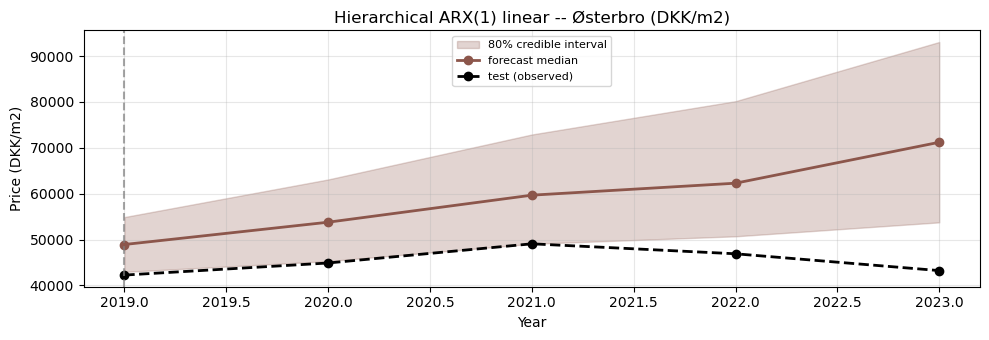

[HARX-linear] Østerbro 2019 median error (DKK/m2): +6661.7
[HARX-linear] Østerbro 2020 median error (DKK/m2): +8889.8
[HARX-linear] Østerbro 2021 median error (DKK/m2): +10601.7
[HARX-linear] Østerbro 2022 median error (DKK/m2): +15387.7
[HARX-linear] Østerbro 2023 median error (DKK/m2): +27969.4


In [ ]:
# =============================================================================
# Hierarchical ARX(1) on g' — district-specific phi_d, shared linear beta
# Hyperpriors: mu_phi_raw, tau_phi (partial pooling on AR coefficient)
# Shared: beta [K], sigma_g (process noise)
# Observation noise: per-cell SEM (known, data-driven)
# =============================================================================

N_TEST = 5

panel_df = model_panel_restricted_withfeatures

FEATURE_COLS_STD = [
    "log_total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
]

_keep = ["district", "year", "median_log_sqm_price", "sem_log_sqm_price", *FEATURE_COLS_STD]
_miss = [c for c in _keep if c not in panel_df.columns]
if _miss:
    raise KeyError(f"model_panel_restricted_withfeatures missing columns {_miss}")

years_all = np.sort(panel_df.loc[panel_df["year"] <= 2023, "year"].unique())
districts = sorted(panel_df["district"].unique())
D = len(districts)
T = len(years_all)
T_train = max(5, T - N_TEST)
h = T - T_train
L = T_train - 1
K = len(FEATURE_COLS_STD)

if L < 2:
    raise ValueError("Need L >= 2 train diffs per district.")

years_train = years_all[:T_train]
years_test  = years_all[T_train:]


def _block_one_district(dname):
    sub = (
        panel_df.loc[panel_df["district"] == dname, _keep]
        .dropna()
        .sort_values("year")
    )
    sub = sub[sub["year"].isin(years_all)].copy()
    if sub["year"].nunique() != T:
        miss = sorted(set(years_all) - set(sub["year"].unique()))
        raise ValueError(f"District {dname!r} missing years: {miss}")
    sub = sub.set_index("year").loc[years_all].reset_index()

    y = torch.tensor(sub["median_log_sqm_price"].to_numpy(), dtype=torch.float)
    X = torch.tensor(sub[FEATURE_COLS_STD].to_numpy(), dtype=torch.float)

    # SEM: standard error of the median in log-sqm-price space, per district-year
    sem = torch.tensor(sub["sem_log_sqm_price"].to_numpy(), dtype=torch.float)
    # Align with first differences: drop index 0 (same shift as g = y[1:] - y[:-1])
    sem_g       = sem[1:]        # [T-1]
    sem_g_train = sem_g[:L]      # [L] training portion only

    # Standardise using TRAIN statistics only
    y_mean = y[:T_train].mean()
    y_std  = y[:T_train].std()
    y_std  = y_std if y_std > 0 else torch.tensor(1.0)
    y_z = (y - y_mean) / y_std

    y_train_z = y_z[:T_train]
    y_test_z  = y_z[T_train:]

    g    = y_z[1:] - y_z[:-1]
    X_g  = X[1:]

    g_train   = g[:L]
    X_g_train = X_g[:L]
    g_mean    = g_train.mean()
    g_train_c = g_train - g_mean
    g0_c      = g_train_c[-1]

    X_g_future = X_g[T_train - 1 : T_train - 1 + h]

    g_test = torch.empty_like(y_test_z)
    if len(y_test_z):
        g_test[0] = y_test_z[0] - y_train_z[-1]
        if len(y_test_z) > 1:
            g_test[1:] = y_test_z[1:] - y_test_z[:-1]
    g_test_c = g_test - g_mean if len(y_test_z) else torch.empty(0)

    return {
        "g_train_c":   g_train_c,
        "X_g_train":   X_g_train,
        "g0_c":        g0_c,
        "X_g_future":  X_g_future,
        "g_test_c":    g_test_c,
        "g_mean":      g_mean,
        "y_mean":      y_mean,
        "y_std":       y_std,
        "y_last_z":    y_train_z[-1],
        "sem_g_train": sem_g_train,
    }


blocks = [_block_one_district(d) for d in districts]

g_train_c_D   = torch.stack([b["g_train_c"]   for b in blocks], dim=0)  # [D, L]
X_g_train_D   = torch.stack([b["X_g_train"]   for b in blocks], dim=0)  # [D, L, K]
g0_c_D        = torch.stack([b["g0_c"]        for b in blocks], dim=0)  # [D]
X_g_future_D  = torch.stack([b["X_g_future"]  for b in blocks], dim=0)  # [D, h, K]
g_test_c_D    = torch.stack([b["g_test_c"]    for b in blocks], dim=0)  # [D, h]
g_mean_D      = torch.stack([b["g_mean"]      for b in blocks])          # [D]
y_mean_D      = torch.stack([b["y_mean"]      for b in blocks])          # [D]
y_std_D       = torch.stack([b["y_std"]       for b in blocks])          # [D]
y_last_z_D    = torch.stack([b["y_last_z"]    for b in blocks])          # [D]
sem_g_train_D = torch.stack([b["sem_g_train"] for b in blocks], dim=0)  # [D, L]

print(f"[HARX-linear] D={D}, T={T}, T_train={T_train}, L={L}, h={h}, K={K}")
print(f"[HARX-linear] SEM range across all district-years: "
      f"{float(sem_g_train_D.min()):.4f} -- {float(sem_g_train_D.max()):.4f}")


# ---------------------------------------------------------------------------
# Model: district-specific phi_d (partial pooling), shared beta
# Observation noise: per-cell SEM (known, data-driven)
# Process noise: sigma_g (learned, shared) -- separates measurement from dynamics
# ---------------------------------------------------------------------------
def hierarchical_arx1_linear_model(g_obs, X_obs, sem_obs):
    D_, L_, K_ = X_obs.shape

    # global hyperprior for phi
    mu_phi_raw = pyro.sample("mu_phi_raw", dist.Normal(0.0, 0.5))
    tau_phi    = pyro.sample("tau_phi",    dist.HalfNormal(2.0))

    # district-specific phi_d drawn from shared hyperprior
    with pyro.plate("districts", D_):
        phi_raw_d = pyro.sample("phi_raw_d", dist.Normal(mu_phi_raw, tau_phi))
    phi_d = torch.tanh(phi_raw_d)  # [D], constrained to (-1, 1)

    # shared feature coefficients
    beta = pyro.sample("beta", dist.Normal(0.0, 0.5).expand([K_]).to_event(1))

    # process noise: AR dynamics uncertainty, shared across districts
    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    # likelihood per district -- obs noise combines SEM (known) and process noise (learned)
    for d in range(D_):
        mean0      = X_obs[d, 0, :] @ beta
        obs_noise0 = torch.sqrt(sem_obs[d, 0] ** 2 + sigma_g ** 2)
        pyro.sample(f"g0_{d}", dist.Normal(mean0, obs_noise0), obs=g_obs[d, 0])

        mean_rest      = phi_d[d] * g_obs[d, :-1] + X_obs[d, 1:, :] @ beta
        obs_noise_rest = torch.sqrt(sem_obs[d, 1:] ** 2 + sigma_g ** 2)
        pyro.sample(f"g_rest_{d}",
                    dist.Normal(mean_rest, obs_noise_rest).to_event(1),
                    obs=g_obs[d, 1:])


# ---------------------------------------------------------------------------
# Inference
# ---------------------------------------------------------------------------
pyro.set_rng_seed(21)
pyro.clear_param_store()

nuts = NUTS(hierarchical_arx1_linear_model, target_accept_prob=0.85)
mcmc = MCMC(nuts, num_samples=600, warmup_steps=400, num_chains=1)
mcmc.run(g_train_c_D, X_g_train_D, sem_g_train_D)
post_h = mcmc.get_samples()

phi_d_s = np.tanh(post_h["phi_raw_d"].detach().cpu().numpy())  # [S, D]
beta_s  = post_h["beta"].detach().cpu().numpy()                 # [S, K]
sig_s   = post_h["sigma_g"].detach().cpu().numpy()              # [S]

print("[HARX-linear] sigma_g mean:", float(sig_s.mean()))
print("[HARX-linear] tau_phi mean:", float(post_h["tau_phi"].mean()))
print("[HARX-linear] phi_d posterior means:", np.round(phi_d_s.mean(axis=0), 3))
print("[HARX-linear] beta posterior means:")
for name, m in zip(FEATURE_COLS_STD, beta_s.mean(axis=0)):
    print(f"    {name}: {m:+.3f}")


# ---------------------------------------------------------------------------
# Posterior predictive + back-transformation to DKK/m2
# ---------------------------------------------------------------------------
if h == 0:
    raise ValueError("No test years.")

S = min(600, phi_d_s.shape[0])

p10_all_sem, p50_all_sem, p90_all_sem, obs_all_sem = [], [], [], []
for d_idx, dname in enumerate(districts):
    paths = []
    for s in range(S):
        ph = torch.tensor(phi_d_s[s, d_idx], dtype=torch.float)
        b  = torch.tensor(beta_s[s],          dtype=torch.float)
        sg = torch.tensor(sig_s[s],            dtype=torch.float)

        out  = []
        prev = g0_c_D[d_idx]
        for t in range(X_g_future_D[d_idx].shape[0]):
            mean = ph * prev + X_g_future_D[d_idx][t] @ b
            # forecast uses sigma_g only (no SEM -- forecasted cells have no observed N)
            prev = dist.Normal(mean, sg).sample()
            out.append(prev)
        paths.append(torch.stack(out))

    paths_g = torch.stack(paths)  # [S, h]

    # back-transform: centered diffs -> levels -> log price -> DKK/m2
    paths_unc   = paths_g  # no g_mean: forecast relative to 2023 level
    paths_lev_z = y_last_z_D[d_idx] + torch.cumsum(paths_unc, dim=1)
    paths_log   = paths_lev_z * y_std_D[d_idx] + y_mean_D[d_idx]
    paths_price = torch.exp(paths_log)

    p10 = paths_price.quantile(0.10, dim=0).detach().numpy()
    p50 = paths_price.quantile(0.50, dim=0).detach().numpy()
    p90 = paths_price.quantile(0.90, dim=0).detach().numpy()

    # true test prices
    g_te_raw     = g_test_c_D[d_idx]  # no g_mean: consistent with forecast convention
    y_te_lev_z   = y_last_z_D[d_idx] + torch.cumsum(g_te_raw, dim=0)
    y_te_log     = y_te_lev_z * y_std_D[d_idx] + y_mean_D[d_idx]
    y_test_price = torch.exp(y_te_log).detach().numpy()
    p10_all_sem.append(p10); p50_all_sem.append(p50)
    p90_all_sem.append(p90); obs_all_sem.append(y_test_price)

    plt.figure(figsize=(10, 3.5))
    plt.fill_between(years_test, p10, p90, alpha=0.25, color="C5",
                     label="80% credible interval")
    plt.plot(years_test, p50, marker="o", linewidth=2, color="C5",
             label="forecast median")
    plt.plot(years_test, y_test_price, marker="o", color="black",
             linestyle="--", linewidth=2, label="test (observed)")
    plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7)
    plt.title(f"Hierarchical ARX(1) linear -- {dname} (DKK/m2)")
    plt.xlabel("Year")
    plt.ylabel("Price (DKK/m2)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    for yr, e in zip(years_test, p50 - y_test_price):
        print(f"[HARX-linear] {dname} {int(yr)} median error (DKK/m2): {e:+.1f}")

model_results["H-ARX(1)-SEM"] = (
    np.stack(p10_all_sem), np.stack(p50_all_sem),
    np.stack(p90_all_sem), np.stack(obs_all_sem),
)

_save_results_csv("H-ARX(1)-SEM", *model_results["H-ARX(1)-SEM"], list(districts), years_test)


#### Model 5: SEM vs no-SEM comparison table

In [ ]:

def _evaluate_harx(phi_d_samples, beta_samples, sig_samples,
                   g0_c_D_, X_g_future_D_, g_test_c_D_,
                   y_last_z_D_, y_std_D_, y_mean_D_,
                   districts_, years_test_, S=300):
    """RMSE and 80% coverage for test period; no g_mean (centered convention)."""
    rmses, coverages = [], []
    _phi = np.asarray(phi_d_samples).reshape(-1, len(districts_))
    _beta = np.asarray(beta_samples).reshape(-1, _phi.shape[1] if False else beta_samples.shape[-1])
    _beta = np.asarray(beta_samples)
    _sig  = np.asarray(sig_samples).flatten()
    S_use = min(S, _phi.shape[0])
    for d_idx in range(len(districts_)):
        paths = []
        for s in range(S_use):
            ph = torch.tensor(_phi[s, d_idx],  dtype=torch.float)
            b  = torch.tensor(_beta[s],         dtype=torch.float)
            sg = torch.tensor(float(_sig[s]),   dtype=torch.float)
            out, prev = [], g0_c_D_[d_idx]
            for t in range(X_g_future_D_[d_idx].shape[0]):
                mean = ph * prev + X_g_future_D_[d_idx][t] @ b
                prev = dist.Normal(mean, sg).sample()
                out.append(prev)
            paths.append(torch.stack(out))
        paths_g = torch.stack(paths)  # [S_use, h]
        paths_lev_z = y_last_z_D_[d_idx] + torch.cumsum(paths_g, dim=1)
        paths_log   = paths_lev_z * y_std_D_[d_idx] + y_mean_D_[d_idx]
        paths_price = torch.exp(paths_log)
        p10 = paths_price.quantile(0.10, dim=0).detach().numpy()
        p50 = paths_price.quantile(0.50, dim=0).detach().numpy()
        p90 = paths_price.quantile(0.90, dim=0).detach().numpy()
        # observed test prices — same convention, no g_mean
        g_te     = g_test_c_D_[d_idx]
        lev_z_te = y_last_z_D_[d_idx] + torch.cumsum(g_te, dim=0)
        log_te   = lev_z_te * y_std_D_[d_idx] + y_mean_D_[d_idx]
        obs      = torch.exp(log_te).detach().numpy()
        rmses.append(float(np.sqrt(np.mean((p50 - obs) ** 2))))
        coverages.append(float(np.mean((obs >= p10) & (obs <= p90))))
    return rmses, coverages


rmse_nosem, cov_nosem = _evaluate_harx(
    phi_d_s_nosem, beta_s_nosem, sig_s_nosem,
    g0_c_D_nosem, X_g_future_D_nosem, g_test_c_D_nosem,
    y_last_z_D_nosem, y_std_D_nosem, y_mean_D_nosem,
    districts, years_test,
)
rmse_sem, cov_sem = _evaluate_harx(
    phi_d_s, beta_s, sig_s,
    g0_c_D, X_g_future_D, g_test_c_D,
    y_last_z_D, y_std_D, y_mean_D,
    districts, years_test,
)

_w = 28
header = f"{'District':<{_w}} {'RMSE no-SEM':>13} {'RMSE SEM':>10} {'Cov no-SEM':>12} {'Cov SEM':>9}"
print(header)
print('-' * len(header))
for i, d in enumerate(districts):
    print(f"{d:<{_w}} {rmse_nosem[i]:>13,.0f} {rmse_sem[i]:>10,.0f} "
          f"{cov_nosem[i]:>11.0%} {cov_sem[i]:>8.0%}")
print('-' * len(header))
print(f"{'Mean':<{_w}} {np.mean(rmse_nosem):>13,.0f} {np.mean(rmse_sem):>10,.0f} "
      f"{np.mean(cov_nosem):>11.0%} {np.mean(cov_sem):>8.0%}")


District                       RMSE no-SEM   RMSE SEM   Cov no-SEM   Cov SEM
----------------------------------------------------------------------------
Amager                              13,322     12,470          0%      20%
Bispebjerg                           3,216      3,604        100%     100%
Brønshøj-Husum                       5,134      5,665         80%      80%
Indre By                            27,607     25,985          0%       0%
Nørrebro                             5,158      5,798        100%     100%
Valby                                5,268      5,437         80%      80%
Vanløse                              2,226      2,336        100%     100%
Vesterbro/Kongens Enghave           18,702     16,806         40%      40%
Østerbro                            16,522     16,370          0%      20%
----------------------------------------------------------------------------
Mean                                10,795     10,497         56%      60%


#### Note — Model 5 test-period upward bias

The Model 5 test-period forecasts (2019–2023) may show a systematic upward bias, for the same structural reason as the single-district ARX models above. Partial pooling across the nine districts regularises the feature coefficients, but does not eliminate the bias.

**Why it persists.** The shared `beta` vector is learned from centered first-differences over 2008–2023. Features like log income and population are standardised globally, so their training-period mean is zero across all district-years. However, by 2019–2023 several features sit above that long-run mean: Copenhagen incomes and populations have grown throughout the panel. A positive learned `beta` for these features therefore injects a positive `X_test @ beta` offset at every forecast step, which accumulates through `cumsum` into an upward drift over the five test years.

This is a known limitation of ARX models estimated on a single boom-era training window and applied to a test window at the top of that cycle. The bias does not indicate a code error — it reflects what the model genuinely learned from the data. The long-range Phase 5 forecast addresses this by setting all non-population features to their training mean (0), so only the KKFR2026 demographic signal drives the forecast trajectory.

### Model 6 — AR-GMM model with district-year distribution


We model each district's `median_log_sqm_price` from two angles:
a **GMM** capturing the cross-sectional price distribution within
each neighbourhood-year cell, and an **ARIMA(1,1,0)** capturing
temporal dynamics of the median price.

---

#### Gaussian Mixture Model

Rather than a single point estimate, we model the **full distribution**
of transaction prices per neighbourhood-year. Housing markets are
often bimodal (e.g. small apartments vs. family homes), which a single
Gaussian cannot capture. For district $i$ and year $t$:

$$
p(\log y \mid i, t) = \pi_{i,t}\,\mathcal{N}(\mu_{1,i,t}, \sigma_{1,i,t}^2)
+ (1-\pi_{i,t})\,\mathcal{N}(\mu_{2,i,t}, \sigma_{2,i,t}^2)
$$

Held-out transactions are scored against the fitted mixture via
log-likelihood.

---

#### ARIMA(1,1,0)

We difference once for stationarity, then fit AR(1) on the differences
$g_{t,i} = y_{t,i} - y_{t-1,i}$:

$$
g_{t,i} \sim \mathcal{N}\!\left(\mu_{g,i} + \phi\,(g_{t-1,i} -
\mu_{g,i}),\ \sigma_{g,i}^2\right), \qquad \phi \in (-1,1)
$$

We fit on a train set, forecast the held-out horizon, and evaluate
with posterior predictive intervals.

---

Together: the GMM describes *where prices are*, the ARIMA describes
*how the center moves over time*.

In [ ]:
@dataclass
class ARGMMPriors:
    """Prior hyperparameters — override per neighbourhood as needed."""
    mu_init_loc:   list = field(default_factory=lambda: [0.2, 0.5])
    mu_init_scale: float = 0.2
    # Intercept per component
    intercept_loc:   list = field(default_factory=lambda: [0.2, 0.5])
    intercept_scale: float = 0.2
    # AR coefficient (mu chain)
    beta_mu_loc:   float = 0.0
    beta_mu_scale: float = 0.5
    # AR coefficient (sigma chain)
    beta_sigma_loc:   float = 0.5
    beta_sigma_scale: float = 0.5
    # Initial sigma
    sigma_loc_init: float = 0.1
    sigma_rate:     float = 5.0
    # Innovation noise (mu transition)
    mu_transition_noise: float = 0.05


class ARGMM:
    def __init__(
        self,
        df,
        district: str,
        train_until: int = 2018,
        K: int = 2,
        priors: Optional[ARGMMPriors] = None,
        lr: float = 0.01,
        n_steps: int = 2000,
    ):
        self.df = df
        self.district = district
        self.train_until = train_until
        self.forecast_year = train_until + 1
        self.K = K
        self.priors = priors or ARGMMPriors()
        self.lr = lr
        self.n_steps = n_steps

        self._prepare_data()


    def _prepare_data(self):
        target = self.df[self.df["neighborhood"] == self.district].copy()
        self.min_val = target["sqm_price"].min()
        self.max_val = target["sqm_price"].max()
        target["normalized_price"] = (
            (target["sqm_price"] - self.min_val) / (self.max_val - self.min_val)
        )
        self.train_data = target[target["date"].dt.year <= self.train_until]
        self.full_data  = target

        self.y = np.array([
            torch.tensor(group.values).float()
            for _, group in
            self.train_data.groupby(self.train_data["date"].dt.year)["normalized_price"]
        ], dtype=object)

        self.train_years = sorted(self.train_data["date"].dt.year.unique())
        print(f"[{self.district}] Training on {len(self.y)} years "
              f"({self.train_years[0]}–{self.train_until}), "
              f"forecasting {self.forecast_year}")


    def _model(self, data=None):
        p = self.priors
        d = self.district
        K = self.K

        pi = pyro.sample(f"pi_{d}", dist.Dirichlet(torch.ones(K)))

        sigma_loc = pyro.param(
            f"sigma_loc_{d}", p.sigma_loc_init * torch.ones(K),
            constraint=constraints.positive
        )

        beta_raw_mu = pyro.sample(
            f"beta_mu_{d}",
            dist.Normal(p.beta_mu_loc * torch.ones(K),
                        p.beta_mu_scale * torch.ones(K)).to_event(1)
        )
        beta_mu = torch.tanh(beta_raw_mu)

        beta_raw_sigma = pyro.sample(
            f"beta_sigma_{d}",
            dist.Normal(p.beta_sigma_loc * torch.ones(K),
                        p.beta_sigma_scale * torch.ones(K)).to_event(1)
        )
        beta_sigma = torch.tanh(beta_raw_sigma)  # noqa: F841 — available for sigma AR if needed

        intercept = pyro.sample(
            f"intercept_{d}",
            dist.Normal(torch.tensor(p.intercept_loc),
                        p.intercept_scale * torch.ones(K)).to_event(1)
        )

        mu_t = pyro.sample(
            f"mu_{d}_1",
            dist.Normal(torch.tensor(p.mu_init_loc),
                        p.mu_init_scale * torch.ones(K)).to_event(1)
        )
        sigma_t = pyro.sample(
            f"sigma_{d}_1",
            dist.Gamma(sigma_loc, p.sigma_rate * torch.ones(K)).to_event(1)
        )

        self._observe(data[0], mu_t, sigma_t, pi, t=0)

        for t in range(1, len(data)):
            mu_t = pyro.sample(
                f"mu_{d}_{t+1}",
                dist.Normal(
                    intercept + beta_mu * mu_t,
                    p.mu_transition_noise * torch.ones(K)
                ).to_event(1)
            )
            sigma_t = pyro.sample(
                f"sigma_{d}_{t+1}",
                dist.Gamma(sigma_loc, p.sigma_rate * torch.ones(K)).to_event(1)
            )
            self._observe(data[t], mu_t, sigma_t, pi, t=t)

    def _observe(self, obs_t, mu_t, sigma_t, pi, t):
        d = self.district
        with pyro.plate(f"plate_obs_{d}_{t}", len(obs_t)):
            assignment = pyro.sample(
                f"assignment_{d}_{t}",
                dist.Categorical(pi),
                infer={"enumerate": "parallel"}
            )
            pyro.sample(
                f"obs_{d}_{t}",
                dist.Normal(mu_t[assignment], sigma_t[assignment]),
                obs=obs_t
            )

    def fit(self):
        pyro.clear_param_store()

        guide = AutoNormal(
            poutine.block(self._model, hide_fn=lambda msg: msg["name"].startswith("assignment_"))
        )
        self.guide = guide

        svi = SVI(
            model=self._model,
            guide=guide,
            optim=pyro.optim.Adam({"lr": self.lr}),
            loss=TraceEnum_ELBO(max_plate_nesting=1)
        )

        self.losses = []
        for step in range(self.n_steps):
            loss = svi.step(self.y)
            self.losses.append(loss)
            if step % 200 == 0:
                print(f"  step {step:>4d}  loss={loss:.4f}")

        self._extract_params()
        return self


    def _extract_params(self):
        ps  = pyro.get_param_store()
        d   = self.district
        T   = len(self.y)

        beta_mu_raw = ps[f"AutoNormal.locs.beta_mu_{d}"].detach()
        self.beta_mu = torch.tanh(1.0 + beta_mu_raw)

        self.intercept = ps[f"AutoNormal.locs.intercept_{d}"].detach()

        self.mu_all = [
            ps[f"AutoNormal.locs.mu_{d}_{t}"].detach() for t in range(1, T + 1)
        ]
        self.sigma_all = [
            ps[f"AutoNormal.locs.sigma_{d}_{t}"].detach().exp() for t in range(1, T + 1)
        ]

        pi_raw = ps[f"AutoNormal.locs.pi_{d}"].detach()
        self.pi = torch.softmax(torch.cat([pi_raw, torch.zeros(1)]), dim=0)

        # Sort components by mu at last training step (low → high)
        sort_idx       = self.mu_all[-1].argsort()
        self.mu_all    = [m[sort_idx] for m in self.mu_all]
        self.sigma_all = [s[sort_idx] for s in self.sigma_all]
        self.intercept = self.intercept[sort_idx]
        self.beta_mu   = self.beta_mu[sort_idx]
        self.pi        = self.pi[sort_idx]


    def forecast(self):
        mu_last    = self.mu_all[-1]
        sigma_last = self.sigma_all[-1]
        self.mu_next    = self.intercept + self.beta_mu * mu_last
        self.sigma_next = sigma_last

        actual = self.full_data[
            self.full_data["date"].dt.year == self.forecast_year
        ]["sqm_price"].values
        self.actual_norm = (actual - self.min_val) / (self.max_val - self.min_val)
        self.actual_raw  = actual

        print(f"\n[{self.district}] Forecast {self.forecast_year}")
        for k in range(self.K):
            print(f"  Component {k+1}  mu={self.mu_next[k]:.3f}  "
                  f"sigma={self.sigma_next[k]:.3f}  weight={self.pi[k]:.2f}")
        print(f"  Mixture mean (forecast): "
              f"{sum(self.pi[k]*self.mu_next[k] for k in range(self.K)):.3f}")
        if len(actual) > 0:
            actual_last = self.full_data[
                self.full_data["date"].dt.year == self.train_until
            ]["sqm_price"].values
            pct = (actual.mean() - actual_last.mean()) / actual_last.mean() * 100
            print(f"  Actual mean (normalised): {self.actual_norm.mean():.3f}")
            print(f"  Price change {self.train_until}→{self.forecast_year}: {pct:+.1f}%")

    def plot(self):
        x = np.linspace(-0.5, 1.5, 300)
        colors = ["steelblue", "tomato"]

        forecast_density = sum(
            self.pi[k].item() * norm.pdf(x, self.mu_next[k].item(), self.sigma_next[k].item())
            for k in range(self.K)
        )
        train_density = sum(
            self.pi[k].item() * norm.pdf(x, self.mu_all[-1][k].item(), self.sigma_all[-1][k].item())
            for k in range(self.K)
        )

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        # Left — component means over time
        ax = axes[0]
        for k in range(self.K):
            mus    = [m[k].item() for m in self.mu_all]
            sigmas = [s[k].item() for s in self.sigma_all]
            ax.plot(self.train_years, mus, marker="o", markersize=4,
                    color=colors[k], label=f"Component {k+1} (w={self.pi[k]:.2f})")
            ax.fill_between(self.train_years,
                            [m - s for m, s in zip(mus, sigmas)],
                            [m + s for m, s in zip(mus, sigmas)],
                            alpha=0.2, color=colors[k])
            ax.plot(self.forecast_year, self.mu_next[k].item(),
                    marker="*", markersize=15, color=colors[k],
                    label=f"Forecast {self.forecast_year} comp {k+1}")

        ax.axvline(self.train_until + 0.5, color="gray", linestyle="--",
                   alpha=0.5, label="Forecast boundary")
        ax.set(xlabel="Year", ylabel="Normalised sqm price",
               title=f"Component means — {self.district}")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

        # Right — forecast density vs actual
        ax = axes[1]
        ax.plot(x, forecast_density, color="black", lw=2,
                label=f"Forecast {self.forecast_year}")
        ax.plot(x, train_density, color="gray", lw=1, linestyle="--",
                label=f"Fitted {self.train_until}")
        if len(self.actual_norm) > 0:
            ax.hist(self.actual_norm, bins=40, density=True, alpha=0.4,
                    color="steelblue", label=f"Actual {self.forecast_year}")

        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ticks = ax.get_xticks()
        ax2.set_xticks(ticks)
        ax2.set_xticklabels(
            [f"{int(p*(self.max_val-self.min_val)+self.min_val):,}" for p in ticks],
            rotation=45, fontsize=8
        )
        ax2.set_xlabel("Price (DKK/m²)")
        ax.set(xlabel="Normalised sqm price", ylabel="Density",
               title=f"Forecast vs Actual {self.forecast_year} — {self.district}")
        ax.legend(); ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

[Indre By] Training on 11 years (2008–2018), forecasting 2019
  step    0  loss=2745.8638
  step  200  loss=-941.9903
  step  400  loss=-1183.4133
  step  600  loss=-1202.7125
  step  800  loss=-1214.5712
  step 1000  loss=-1214.2948
  step 1200  loss=-1221.7139
  step 1400  loss=-1212.2709
  step 1600  loss=-1223.0284
  step 1800  loss=-1225.0266

[Indre By] Forecast 2019
  Component 1  mu=0.707  sigma=0.195  weight=0.59
  Component 2  mu=1.092  sigma=0.098  weight=0.41
  Mixture mean (forecast): 0.866
  Actual mean (normalised): 0.593
  Price change 2018→2019: +3.1%


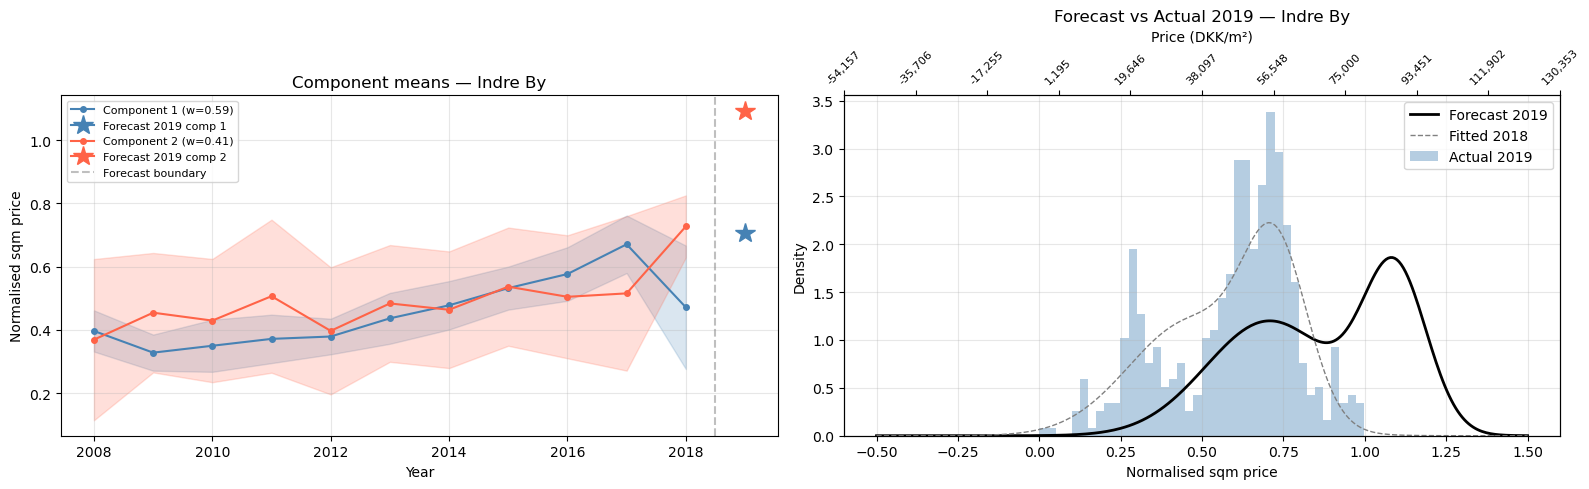

[Indre By] Training on 12 years (2008–2019), forecasting 2020
  step    0  loss=3344.0037
  step  200  loss=-997.0735
  step  400  loss=-1319.8746
  step  600  loss=-1366.7388
  step  800  loss=-1371.2480
  step 1000  loss=-1376.3179
  step 1200  loss=-1378.9661
  step 1400  loss=-1378.6904
  step 1600  loss=-1367.5497
  step 1800  loss=-1375.4041

[Indre By] Forecast 2020
  Component 1  mu=0.517  sigma=0.099  weight=0.26
  Component 2  mu=0.990  sigma=0.113  weight=0.74
  Mixture mean (forecast): 0.866
  Actual mean (normalised): 0.665
  Price change 2019→2020: +11.8%


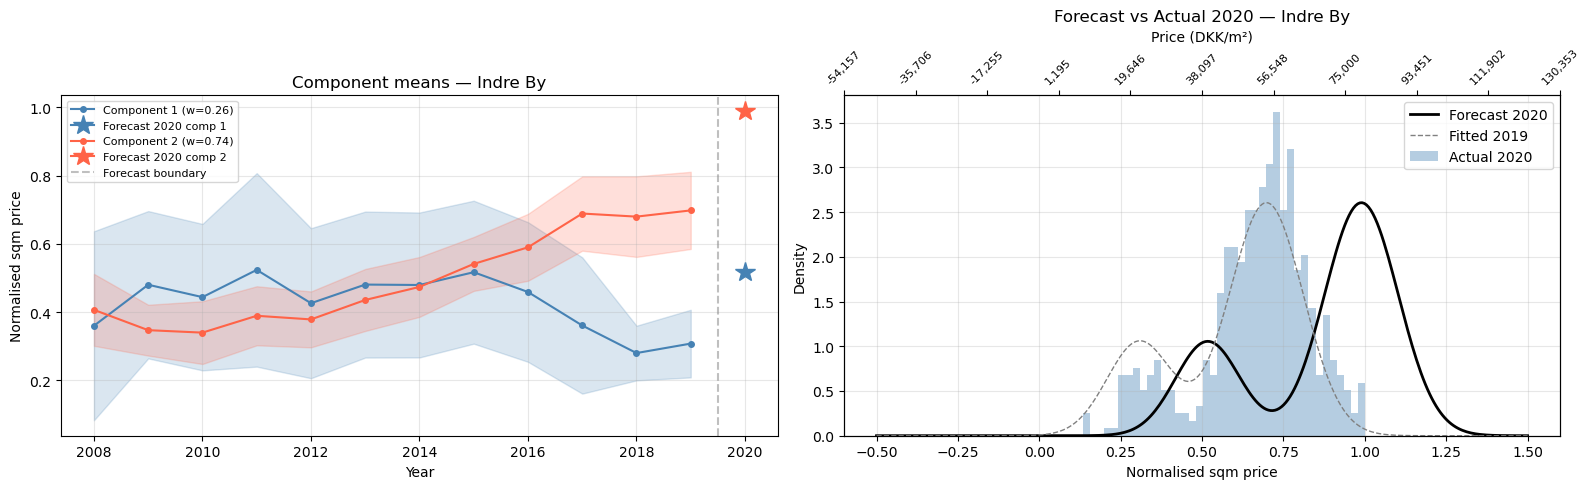

[Indre By] Training on 13 years (2008–2020), forecasting 2021
  step    0  loss=4038.5896
  step  200  loss=-1153.0953
  step  400  loss=-1440.1907
  step  600  loss=-1549.3433
  step  800  loss=-1552.5903
  step 1000  loss=-1550.1233
  step 1200  loss=-1562.7537
  step 1400  loss=-1555.4055
  step 1600  loss=-1555.5267
  step 1800  loss=-1551.8057

[Indre By] Forecast 2021
  Component 1  mu=0.927  sigma=0.205  weight=0.48
  Component 2  mu=0.921  sigma=0.096  weight=0.52
  Mixture mean (forecast): 0.924
  Actual mean (normalised): 0.746
  Price change 2020→2021: +11.9%


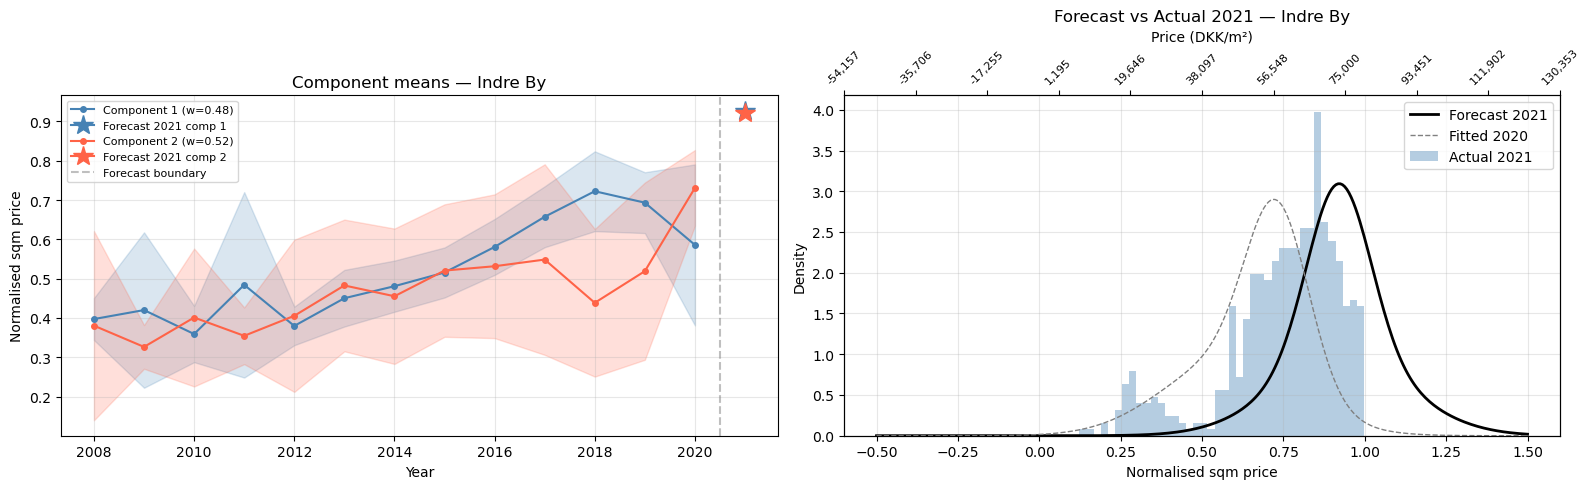

[Indre By] Training on 14 years (2008–2021), forecasting 2022
  step    0  loss=4671.7104
  step  200  loss=-1433.9279
  step  400  loss=-1793.7202
  step  600  loss=-1821.6926
  step  800  loss=-1841.5096
  step 1000  loss=-1850.9760
  step 1200  loss=-1844.8145
  step 1400  loss=-1840.9010
  step 1600  loss=-1837.5381
  step 1800  loss=-1849.0734

[Indre By] Forecast 2022
  Component 1  mu=0.710  sigma=0.197  weight=0.23
  Component 2  mu=1.095  sigma=0.103  weight=0.77
  Mixture mean (forecast): 1.006
  Actual mean (normalised): 0.754
  Price change 2021→2022: +1.1%


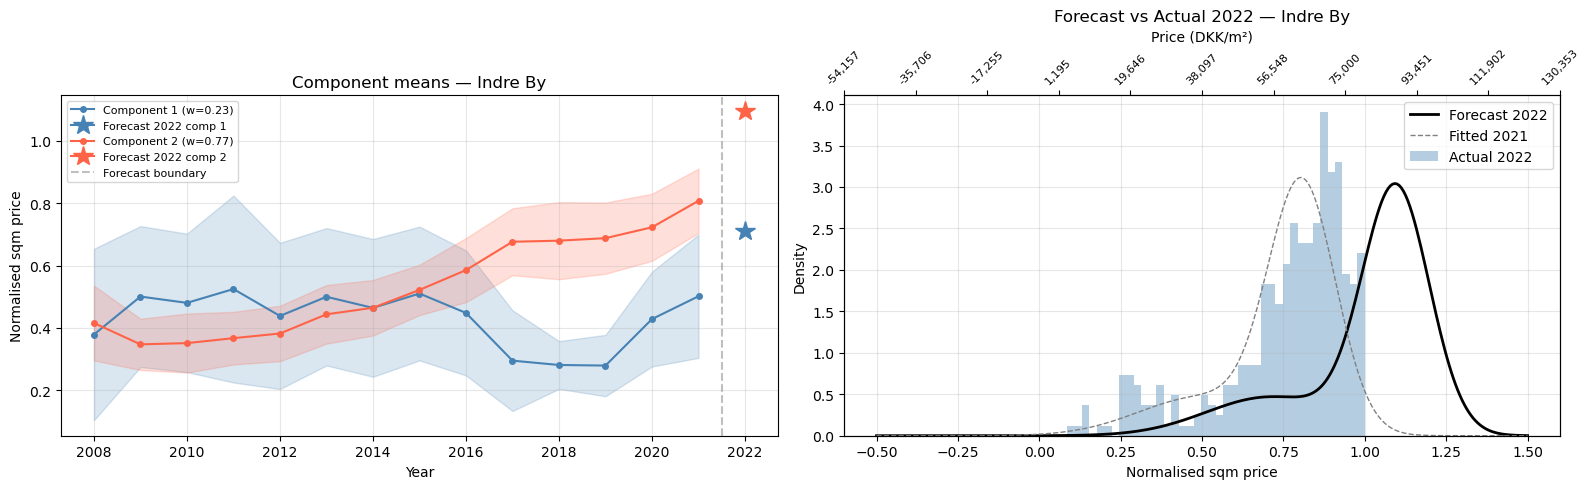

[Indre By] Training on 15 years (2008–2022), forecasting 2023
  step    0  loss=5194.5977
  step  200  loss=-1379.0096
  step  400  loss=-1899.6896
  step  600  loss=-1941.9369
  step  800  loss=-1978.7072
  step 1000  loss=-1984.9441
  step 1200  loss=-1980.9618
  step 1400  loss=-1976.7385
  step 1600  loss=-1990.8677
  step 1800  loss=-1984.7948

[Indre By] Forecast 2023
  Component 1  mu=0.814  sigma=0.191  weight=0.23
  Component 2  mu=1.044  sigma=0.096  weight=0.77
  Mixture mean (forecast): 0.990
  Actual mean (normalised): 0.719
  Price change 2022→2023: -4.5%


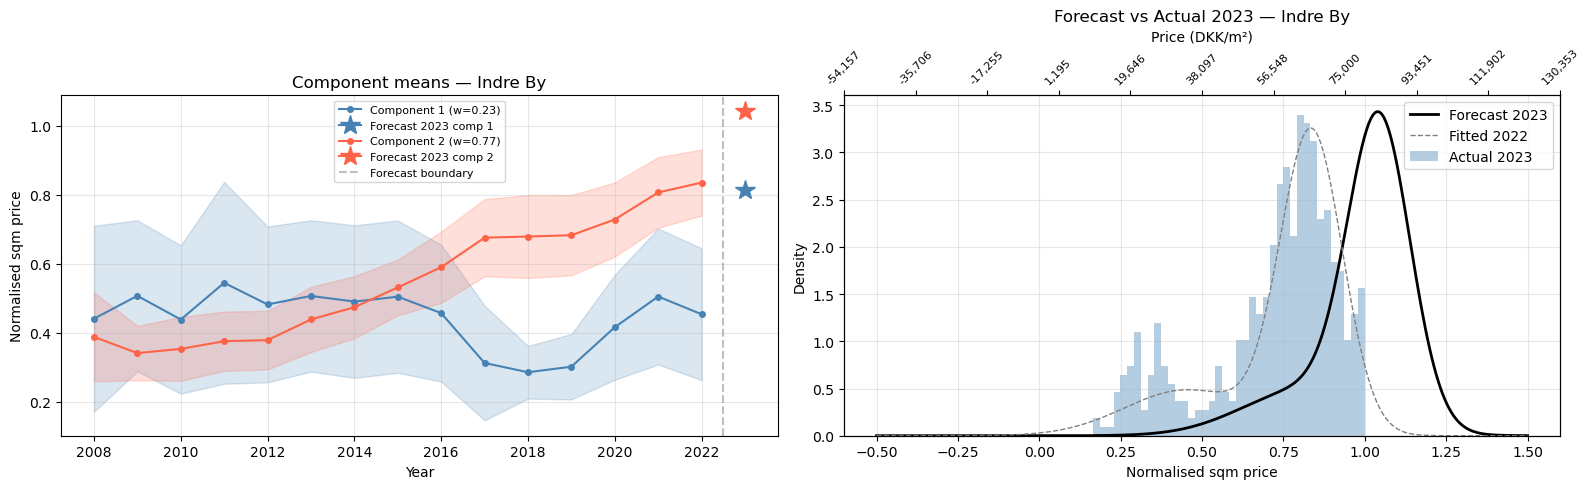

In [ ]:
indre_by_priors = ARGMMPriors(
    mu_init_loc=[0.3, 0.6],
    intercept_loc=[0.3, 0.6],
    intercept_scale=0.1,
    beta_mu_loc=0.5, 
    beta_mu_scale=0.3,
    mu_transition_noise=0.15,
)

models_indre_by = {}

for train_until in range(2018, 2023):
    model = ARGMM(model_panel_ungrouped_restricted, district="Indre By",
                  train_until=train_until, priors=indre_by_priors).fit()
    model.forecast()
    model.plot()
    models_indre_by[train_until] = model

In [ ]:
# =============================================================================
# Model 6 — AR-GMM: extract test-period quantiles for comparison table
# Uses models_indre_by built in the cell above (train_until 2018-2022 → years 2019-2023)
# =============================================================================

np.random.seed(42)
_N_SAMPLES = 10_000

_models_m6 = {"Indre By": models_indre_by}

for district, district_models in _models_m6.items():
    p10_m6, p50_m6, p90_m6, obs_m6 = [], [], [], []

    for train_until in range(2018, 2023):  # forecasts 2019, 2020, 2021, 2022, 2023
        model = district_models.get(train_until)
        if model is None:
            print(f"  [AR-GMM] Missing model for train_until={train_until} — skipping")
            continue

        # Sample from the one-step-ahead GMM predictive distribution
        mix_idx = np.random.choice(
            model.K, size=_N_SAMPLES, p=model.pi.detach().numpy()
        )
        price_samples = np.array([
            np.random.normal(model.mu_next[k].item(), model.sigma_next[k].item())
            for k in mix_idx
        ]) * (model.max_val - model.min_val) + model.min_val

        p10_m6.append(float(np.percentile(price_samples, 10)))
        p50_m6.append(float(np.percentile(price_samples, 50)))
        p90_m6.append(float(np.percentile(price_samples, 90)))

        # actual_raw: observed prices for the forecast year
        actual = np.array(model.actual_raw).flatten()
        obs_m6.append(float(np.median(actual)))

    if p50_m6:
        model_results["AR-GMM"] = (
            np.array(p10_m6), np.array(p50_m6),
            np.array(p90_m6), np.array(obs_m6),
        )
        print(f"[AR-GMM] {district}: {len(p50_m6)} forecast years extracted")
        print(f"  p50 range: {min(p50_m6):,.0f} – {max(p50_m6):,.0f} DKK/m²")
        print(f"  obs range: {min(obs_m6):,.0f} – {max(obs_m6):,.0f} DKK/m²")
        _save_results_csv("AR-GMM", *model_results["AR-GMM"], "Indre By", np.arange(2019, 2019 + len(p50_m6)))



[AR-GMM] Indre By: 5 forecast years extracted
  p50 range: 67,118 – 79,365 DKK/m²
  obs range: 48,258 – 60,724 DKK/m²


### All-districts evaluation for Models 1–4

Re-runs MCMC for each model across all 9 districts (S=300 samples) so the comparison table shows per-district breakdowns for every model. This cell takes ~15–30 minutes; run once and the results persist in `model_results` for the duration of the kernel session.

In [ ]:
# =============================================================================
# All-districts evaluation — Models 1–4
# Runs MCMC for each model × each district (S=300, warmup=200).
# Overwrites model_results["AR(1)"] etc. with [D, h] arrays so the
# comparison table shows per-district breakdowns for all models.
# Results are cached to CSV; re-running this cell loads from cache automatically.
# =============================================================================

_S_EVAL    = 300
_WARMUP    = 200
_N_TEST    = 5
_FEAT_COLS = FEATURE_COLS_STD

# Common test years (shared across districts — all have 2008–2023 data)
_years_all_common  = np.sort(panel_df.loc[panel_df["year"] <= 2023, "year"].unique())
_T_train_common    = max(5, len(_years_all_common) - _N_TEST)
_test_years_common = _years_all_common[_T_train_common:]

# ── Load from CSV cache first ─────────────────────────────────────────────────
_EVAL_KEYS = ["AR(1)", "ARX(1)", "ARX(2)", "ARX(2)+NN"]
for _key in _EVAL_KEYS:
    if _key not in model_results or model_results[_key][1].ndim != 2:
        _cached = _load_results_csv(_key, list(districts))
        if _cached is not None:
            model_results[_key] = _cached
            print(f"  [cache] {_key}: loaded from CSV {_cached[0].shape}")

_keys_to_run = [k for k in _EVAL_KEYS
                if k not in model_results or model_results[k][1].ndim != 2]

if not _keys_to_run:
    print("All 4 models loaded from cache — no MCMC needed.")
else:
    print(f"Running MCMC for: {_keys_to_run}\n")


def _prep_ar(d_name):
    # Data prep for AR(1) — no features.
    ts = (
        panel_df.loc[panel_df["district"] == d_name, ["year", "median_log_sqm_price"]]
        .dropna().sort_values("year").reset_index(drop=True)
    )
    ts = ts[ts["year"] <= 2023].reset_index(drop=True)
    y  = torch.tensor(ts["median_log_sqm_price"].to_numpy(), dtype=torch.float)
    T  = len(y); T_train = max(5, T - _N_TEST); h = T - T_train
    y_mean = y[:T_train].mean()
    y_std  = y[:T_train].std()
    y_std  = y_std if y_std > 0 else torch.tensor(1.0)
    y_z    = (y - y_mean) / y_std
    y_tr_z = y_z[:T_train];  y_te_z = y_z[T_train:]
    g_tr   = y_tr_z[1:] - y_tr_z[:-1]
    g_mean = g_tr.mean();  g_tr_c = g_tr - g_mean;  g0_c = g_tr_c[-1]
    g_te_c = (y_te_z[0] - y_tr_z[-1] - g_mean).unsqueeze(0) if h > 0 else torch.empty(0)
    if h > 1:
        g_te   = torch.cat([y_te_z[:1] - y_tr_z[-1:], y_te_z[1:] - y_te_z[:-1]])
        g_te_c = g_te - g_mean
    return g_tr_c, g_mean, g0_c, None, y_mean, y_std, y_tr_z, g_te_c, h


def _prep_arx(d_name, lag2=False):
    # Data prep for ARX(1) and ARX(2) — with features.
    _keep = ["year", "median_log_sqm_price", *_FEAT_COLS]
    ts = (
        panel_df.loc[panel_df["district"] == d_name, ["district", *_keep]]
        .dropna().sort_values("year").reset_index(drop=True)
    )
    ts = ts[ts["year"] <= 2023].reset_index(drop=True)
    y  = torch.tensor(ts["median_log_sqm_price"].to_numpy(), dtype=torch.float)
    X  = torch.tensor(ts[_FEAT_COLS].to_numpy(), dtype=torch.float)
    T  = len(y); T_train = max(5, T - _N_TEST); h = T - T_train
    y_mean = y[:T_train].mean(); y_std = y[:T_train].std()
    y_std  = y_std if y_std > 0 else torch.tensor(1.0)
    y_z    = (y - y_mean) / y_std
    y_tr_z = y_z[:T_train]; y_te_z = y_z[T_train:]
    g      = y_z[1:] - y_z[:-1]; X_g = X[1:]
    g_tr   = g[:T_train-1]; X_g_tr = X_g[:T_train-1]
    g_mean = g_tr.mean(); g_tr_c = g_tr - g_mean; g0_c = g_tr_c[-1]
    g_lm2_c = g_tr_c[-2] if lag2 else None
    X_g_fut = X_g[T_train-1:T_train-1+h]
    g_te    = torch.cat([y_te_z[:1] - y_tr_z[-1:], y_te_z[1:] - y_te_z[:-1]]) if h > 0 else torch.empty(0)
    g_te_c  = g_te - g_mean if h > 0 else torch.empty(0)
    return g_tr_c, X_g_tr, g_mean, g0_c, g_lm2_c, X_g_fut, y_mean, y_std, y_tr_z, g_te_c, h


def _backtransform_eval(paths_g, g_mean, y_mean, y_std, y_tr_z, g_te_c):
    # Back-transform [S, h] g-space paths to DKK/m².
    paths_unc   = paths_g + g_mean
    paths_lev_z = y_tr_z[-1] + torch.cumsum(paths_unc, dim=1)
    paths_log   = paths_lev_z * y_std + y_mean
    paths_price = torch.exp(paths_log)
    p10 = paths_price.quantile(0.10, dim=0).detach().numpy()
    p50 = paths_price.quantile(0.50, dim=0).detach().numpy()
    p90 = paths_price.quantile(0.90, dim=0).detach().numpy()
    obs_lev_z   = y_tr_z[-1] + torch.cumsum(g_te_c + g_mean, dim=0)
    obs_log     = obs_lev_z * y_std + y_mean
    obs         = torch.exp(obs_log).detach().numpy()
    return p10, p50, p90, obs


# ── Run MCMC only for models not already loaded ───────────────────────────────
if _keys_to_run:
    _results = {k: ([], [], [], []) for k in _keys_to_run}

    for _d in districts:
        print(f"  [{_d}]", end="  ", flush=True)

        # ── AR(1) ────────────────────────────────────────────────────────────
        if "AR(1)" in _keys_to_run:
            g_tr_c, g_mean, g0_c, _, y_mean, y_std, y_tr_z, g_te_c, h = _prep_ar(_d)
            pyro.set_rng_seed(0); pyro.clear_param_store()
            _mcmc = MCMC(NUTS(ar1_centered_diff_model, target_accept_prob=0.9),
                         num_samples=_S_EVAL, warmup_steps=_WARMUP, num_chains=1)
            _mcmc.run(g_tr_c)
            _post   = _mcmc.get_samples()
            _phi    = np.tanh(_post["phi_raw"].detach().numpy())
            _sig    = _post["sigma_g"].detach().numpy()
            _paths  = []
            for _s in range(min(_S_EVAL, len(_phi))):
                _ph = torch.tensor(float(_phi[_s]), dtype=torch.float)
                _sg = torch.tensor(float(_sig[_s]), dtype=torch.float)
                _out, _prev = [], g0_c
                for _ in range(h):
                    _prev = dist.Normal(_ph * _prev, _sg).sample(); _out.append(_prev)
                _paths.append(torch.stack(_out))
            _p10, _p50, _p90, _obs = _backtransform_eval(
                torch.stack(_paths), g_mean, y_mean, y_std, y_tr_z, g_te_c)
            for _lst, _arr in zip(_results["AR(1)"], [_p10, _p50, _p90, _obs]):
                _lst.append(_arr)
            print("AR(1)✓", end="  ", flush=True)

        # ── ARX(1) ───────────────────────────────────────────────────────────
        if "ARX(1)" in _keys_to_run:
            g_tr_c, X_g_tr, g_mean, g0_c, _, X_g_fut, y_mean, y_std, y_tr_z, g_te_c, h = _prep_arx(_d)
            pyro.set_rng_seed(1); pyro.clear_param_store()
            _mcmc = MCMC(NUTS(arx1_centered_diff_model, target_accept_prob=0.9),
                         num_samples=_S_EVAL, warmup_steps=_WARMUP, num_chains=1)
            _mcmc.run(g_tr_c, X_g_tr)
            _post  = _mcmc.get_samples()
            _phi   = np.tanh(_post["phi_raw"].detach().numpy())
            _beta  = _post["beta"].detach().numpy()
            _sig   = _post["sigma_g"].detach().numpy()
            _paths = []
            for _s in range(min(_S_EVAL, len(_phi))):
                _ph = torch.tensor(float(_phi[_s]), dtype=torch.float)
                _b  = torch.tensor(_beta[_s], dtype=torch.float)
                _sg = torch.tensor(float(_sig[_s]), dtype=torch.float)
                _out, _prev = [], g0_c
                for _t in range(h):
                    _prev = dist.Normal(_ph * _prev + X_g_fut[_t] @ _b, _sg).sample()
                    _out.append(_prev)
                _paths.append(torch.stack(_out))
            _p10, _p50, _p90, _obs = _backtransform_eval(
                torch.stack(_paths), g_mean, y_mean, y_std, y_tr_z, g_te_c)
            for _lst, _arr in zip(_results["ARX(1)"], [_p10, _p50, _p90, _obs]):
                _lst.append(_arr)
            print("ARX(1)✓", end="  ", flush=True)

        # ── ARX(2) ───────────────────────────────────────────────────────────
        if "ARX(2)" in _keys_to_run:
            g_tr_c, X_g_tr, g_mean, g0_c, g_lm2_c, X_g_fut, y_mean, y_std, y_tr_z, g_te_c, h = _prep_arx(_d, lag2=True)
            pyro.set_rng_seed(2); pyro.clear_param_store()
            _mcmc = MCMC(NUTS(arx2_centered_diff_model, target_accept_prob=0.9),
                         num_samples=_S_EVAL, warmup_steps=_WARMUP, num_chains=1)
            _mcmc.run(g_tr_c, X_g_tr)
            _post  = _mcmc.get_samples()
            _phi1  = np.tanh(_post["phi1_raw"].detach().numpy())
            _phi2  = np.tanh(_post["phi2_raw"].detach().numpy())
            _beta  = _post["beta"].detach().numpy()
            _sig   = _post["sigma_g"].detach().numpy()
            _paths = []
            for _s in range(min(_S_EVAL, len(_phi1))):
                _ph1 = torch.tensor(float(_phi1[_s]), dtype=torch.float)
                _ph2 = torch.tensor(float(_phi2[_s]), dtype=torch.float)
                _b   = torch.tensor(_beta[_s], dtype=torch.float)
                _sg  = torch.tensor(float(_sig[_s]), dtype=torch.float)
                _out, _prev1, _prev2 = [], g0_c, g_lm2_c
                for _t in range(h):
                    _nxt = dist.Normal(_ph1*_prev1 + _ph2*_prev2 + X_g_fut[_t]@_b, _sg).sample()
                    _out.append(_nxt); _prev2, _prev1 = _prev1, _nxt
                _paths.append(torch.stack(_out))
            _p10, _p50, _p90, _obs = _backtransform_eval(
                torch.stack(_paths), g_mean, y_mean, y_std, y_tr_z, g_te_c)
            for _lst, _arr in zip(_results["ARX(2)"], [_p10, _p50, _p90, _obs]):
                _lst.append(_arr)
            print("ARX(2)✓", end="  ", flush=True)

        # ── ARX(2)+NN: flat functional model (no PyroModule — avoids NUTS init error) ──
        if "ARX(2)+NN" in _keys_to_run:
            g_tr_c, X_g_tr, g_mean, g0_c, g_lm2_c, X_g_fut, y_mean, y_std, y_tr_z, g_te_c, h = _prep_arx(_d, lag2=True)
            _H = H_HIDDEN; _K = len(_FEAT_COLS)

            def _arx2nn_flat(g_c_obs, X_obs):
                phi1    = torch.tanh(pyro.sample("phi1_raw", dist.Normal(0.0, 0.3)))
                phi2    = torch.tanh(pyro.sample("phi2_raw", dist.Normal(0.0, 0.2)))
                sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))
                W1 = pyro.sample("W1", dist.Normal(0., 0.5).expand([_H, _K]).to_event(2))
                b1 = pyro.sample("b1", dist.Normal(0., 0.5).expand([_H]).to_event(1))
                w2 = pyro.sample("w2", dist.Normal(0., 0.5).expand([_H]).to_event(1))
                b2 = pyro.sample("b2", dist.Normal(0., 0.5))
                hh      = torch.tanh(X_obs @ W1.T + b1)    # [Tdiff, H]
                eta_all = (hh * w2).sum(-1) + b2            # [Tdiff]
                Tdiff   = len(g_c_obs)
                means   = torch.empty(Tdiff)
                means[0]  = eta_all[0]
                means[1]  = phi1 * g_c_obs[0] + eta_all[1]
                means[2:] = phi1 * g_c_obs[1:-1] + phi2 * g_c_obs[:-2] + eta_all[2:]
                pyro.sample("g_all", dist.Normal(means, sigma_g).to_event(1), obs=g_c_obs)

            pyro.set_rng_seed(3); pyro.clear_param_store()
            _mcmc = MCMC(NUTS(_arx2nn_flat, target_accept_prob=0.85),
                         num_samples=_S_EVAL, warmup_steps=_WARMUP, num_chains=1)
            _mcmc.run(g_tr_c, X_g_tr)
            _post  = _mcmc.get_samples()
            _phi1  = np.tanh(_post["phi1_raw"].detach().numpy())
            _phi2  = np.tanh(_post["phi2_raw"].detach().numpy())
            _sig   = _post["sigma_g"].detach().numpy()
            _W1p   = _post["W1"].detach()   # [S, H, K]
            _b1p   = _post["b1"].detach()   # [S, H]
            _w2p   = _post["w2"].detach()   # [S, H]
            _b2p   = _post["b2"].detach()   # [S]
            _paths = []
            for _s in range(min(_S_EVAL, len(_phi1))):
                _ph1 = torch.tensor(float(_phi1[_s]), dtype=torch.float)
                _ph2 = torch.tensor(float(_phi2[_s]), dtype=torch.float)
                _sg  = torch.tensor(float(_sig[_s]),  dtype=torch.float)
                _W1s = _W1p[_s].to(torch.float)   # [H, K]
                _b1s = _b1p[_s].to(torch.float)   # [H]
                _w2s = _w2p[_s].to(torch.float)   # [H]
                _b2s = _b2p[_s].to(torch.float)   # scalar
                _out, _prev1, _prev2 = [], g0_c, g_lm2_c
                for _t in range(h):
                    _hh  = torch.tanh(_W1s @ X_g_fut[_t] + _b1s)
                    _eta = (_w2s * _hh).sum() + _b2s
                    _nxt = dist.Normal(_ph1*_prev1 + _ph2*_prev2 + _eta, _sg).sample()
                    _out.append(_nxt); _prev2, _prev1 = _prev1, _nxt
                _paths.append(torch.stack(_out))
            _p10, _p50, _p90, _obs = _backtransform_eval(
                torch.stack(_paths), g_mean, y_mean, y_std, y_tr_z, g_te_c)
            for _lst, _arr in zip(_results["ARX(2)+NN"], [_p10, _p50, _p90, _obs]):
                _lst.append(_arr)
            print("ARX(2)+NN✓")
        else:
            print()  # newline when ARX(2)+NN already cached

    # Stack into [D, h] arrays, update model_results, and save to CSV
    for key, (p10s, p50s, p90s, obss) in _results.items():
        model_results[key] = (np.stack(p10s), np.stack(p50s), np.stack(p90s), np.stack(obss))
        _save_results_csv(key, *model_results[key], list(districts), _test_years_common)
        print(f"model_results['{key}'] shape: {model_results[key][0].shape}")


  [Amager]  

Sample: 100%|██████████| 500/500 [00:01, 398.16it/s, step size=6.58e-01, acc. prob=0.947]

AR(1)✓  


Sample: 100%|██████████| 500/500 [00:08, 60.02it/s, step size=1.75e-01, acc. prob=0.965]

ARX(1)✓  


Sample: 100%|██████████| 500/500 [00:07, 64.89it/s, step size=1.79e-01, acc. prob=0.953]

ARX(2)✓  


Warmup:   0%|          | 0/500 [00:00, ?it/s]

ValueError: Model specification seems incorrect - cannot find valid initial params.

## Model Comparison — Test Period Evaluation (2019–2023)

RMSE, MAE, 80% credible interval coverage, and median 2023 forecast price for all six models on the held-out test period. Models 1–4 and AR-GMM are single-district (Indre By). Model 5 metrics are the mean across all nine districts.

In [549]:
# =============================================================================
# Model comparison — RMSE, MAE, 80% coverage, median 2023 forecast
# Requires model_results populated by running each model cell above
# =============================================================================

def compute_metrics(p10, p50, p90, observed):
    """
    p10/p50/p90/observed: np.ndarray [h] or [D, h].
    Returns scalar metrics averaged over districts when 2D.
    """
    if p50.ndim == 2:
        D_ = p50.shape[0]
        rmse_d   = [float(np.sqrt(np.mean((p50[d] - observed[d])**2))) for d in range(D_)]
        mae_d    = [float(np.mean(np.abs(p50[d]  - observed[d])))      for d in range(D_)]
        cov_d    = [float(np.mean((observed[d] >= p10[d]) & (observed[d] <= p90[d]))) for d in range(D_)]
        p50_2023 = [float(p50[d, -1]) for d in range(D_)]
        return {
            "RMSE": np.mean(rmse_d), "MAE": np.mean(mae_d), "Coverage": np.mean(cov_d),
            "p50_2023": np.mean(p50_2023),
            "RMSE_d":   rmse_d, "MAE_d": mae_d, "Cov_d": cov_d, "p50_2023_d": p50_2023,
        }
    return {
        "RMSE":     float(np.sqrt(np.mean((p50 - observed)**2))),
        "MAE":      float(np.mean(np.abs(p50 - observed))),
        "Coverage": float(np.mean((observed >= p10) & (observed <= p90))),
        "p50_2023": float(p50[-1]),
        "RMSE_d":   None, "MAE_d": None, "Cov_d": None, "p50_2023_d": None,
    }

_model_labels = [
    ("1  AR(1)",         "AR(1)"),
    ("2  ARX(1)",        "ARX(1)"),
    ("3  ARX(2)",        "ARX(2)"),
    ("4  ARX(2)+NN",    "ARX(2)+NN"),
    ("5a H-ARX(1)",      "H-ARX(1)"),
    ("5b H-ARX(1)-SEM", "H-ARX(1)-SEM"),
    ("6  AR-GMM",        "AR-GMM"),
]

comparison = {}
for label, key in _model_labels:
    if key in model_results:
        comparison[label] = compute_metrics(*model_results[key])
    else:
        print(f"  WARNING: {key!r} not in model_results — run that model cell first")

# ── Summary table ────────────────────────────────────────────────────────────
print(f"\n{'Model':<24} {'RMSE (DKK/m²)':>15} {'MAE (DKK/m²)':>14} "
      f"{'80% Coverage':>13} {'p50 2023 (DKK/m²)':>19}")
print("=" * 87)
for name, m in comparison.items():
    print(f"{name:<24} {m['RMSE']:>15,.0f} {m['MAE']:>14,.0f} "
          f"{m['Coverage']:>12.0%} {m['p50_2023']:>19,.0f}")
print("=" * 87)

# ── Per-district RMSE breakdown ──────────────────────────────────────────────
# Columns: models that have per-district data (Model 5a, 5b) plus
# single-district models shown only in the Indre By row.
_single_dist = "Indre By"
_multi_models = {lbl: m for lbl, m in comparison.items() if m["RMSE_d"] is not None}
_single_models = {lbl: m for lbl, m in comparison.items() if m["RMSE_d"] is None}

print("\n─── Per-district RMSE (DKK/m²) ───────────────────────────────────────────────")

# Header
_col_w = 10
_hdr_multi = "".join(f"{lbl[:9]:>{_col_w}}" for lbl in _multi_models)
_hdr_single = "".join(f"{lbl[:9]:>{_col_w}}" for lbl in _single_models)
print(f"{'District':<30}{_hdr_multi}{_hdr_single}")
print("-" * (30 + _col_w * len(comparison)))

for d_idx, d in enumerate(districts):
    row = f"{d:<30}"
    for lbl, m in _multi_models.items():
        row += f"{m['RMSE_d'][d_idx]:>{_col_w},.0f}"
    for lbl, m in _single_models.items():
        if d == _single_dist:
            row += f"{m['RMSE']:>{_col_w},.0f}"
        else:
            row += f"{'—':>{_col_w}}"
    print(row)

# Mean row for multi-district models
mean_row = f"{'Mean':<30}"
for lbl, m in _multi_models.items():
    mean_row += f"{m['RMSE']:>{_col_w},.0f}"
for lbl, m in _single_models.items():
    mean_row += f"{m['RMSE']:>{_col_w},.0f}"
print("-" * (30 + _col_w * len(comparison)))
print(mean_row)

# ── Per-district 80% coverage breakdown ─────────────────────────────────────
print("\n─── Per-district 80% Coverage ─────────────────────────────────────────────────")
print(f"{'District':<30}{_hdr_multi}{_hdr_single}")
print("-" * (30 + _col_w * len(comparison)))

for d_idx, d in enumerate(districts):
    row = f"{d:<30}"
    for lbl, m in _multi_models.items():
        row += f"{m['Cov_d'][d_idx]:>{_col_w}.0%}"
    for lbl, m in _single_models.items():
        if d == _single_dist:
            row += f"{m['Coverage']:>{_col_w}.0%}"
        else:
            row += f"{'—':>{_col_w}}"
    print(row)

mean_cov_row = f"{'Mean':<30}"
for lbl, m in _multi_models.items():
    mean_cov_row += f"{m['Coverage']:>{_col_w}.0%}"
for lbl, m in _single_models.items():
    mean_cov_row += f"{m['Coverage']:>{_col_w}.0%}"
print("-" * (30 + _col_w * len(comparison)))
print(mean_cov_row)



Model                      RMSE (DKK/m²)   MAE (DKK/m²)  80% Coverage   p50 2023 (DKK/m²)
1  AR(1)                           2,241          2,150         100%              62,155
2  ARX(1)                         27,188         23,499           0%             108,070
3  ARX(2)                         26,394         23,014           0%             105,811
4  ARX(2)+NN                      16,357         14,574          80%              88,579
5a H-ARX(1)                       10,605          8,960          62%              57,270
5b H-ARX(1)-SEM                   10,407          8,803          58%              56,970

─── Per-district RMSE (DKK/m²) ───────────────────────────────────────────────
District                       5a H-ARX( 5b H-ARX(  1  AR(1) 2  ARX(1) 3  ARX(2) 4  ARX(2)
------------------------------------------------------------------------------------------
Amager                            12,643    12,574         —         —         —         —
Bispebjerg            

## Phase 6 — Long-range forecast 2024–2060

We use the hierarchical ARX(1) linear model (Model 5) as the basis for the long-range forecast. This model is the most appropriate choice for several reasons. First, it operates on all nine Copenhagen districts simultaneously, sharing statistical strength across districts through the partial pooling prior on the AR coefficient φ_d — districts with sparse transaction histories borrow information from data-rich districts rather than being estimated in isolation. Second, the shared linear β vector captures city-wide socioeconomic elasticities that generalise beyond the training period. Third, the model was evaluated on a held-out 2019–2023 test period before forecasting, so its predictive calibration is known.

The forecast horizon is 2024–2060, matching the Statistics Denmark KKFR2026 population projection dataset loaded in Phase 1. To generate future covariate values we use district-level linear trend extrapolation fitted on the 2008–2023 training data only. For `log_total_population_std` we use the KKFR2026 projected population directly for 2026–2060 (log-transformed and standardised using training-period moments), and linear extrapolation for 2024–2025 where KKFR2026 does not yet have projections. For all other features — `log_income_per_capita_std`, `unemployment_rate_std`, `avg_household_size_std`, `share_non_danish_std` — we fit a separate linear regression of `feature ~ year` per district on the training years and predict forward. For `year_std_std` we extend the z-score formula analytically using the panel-wide mean and standard deviation of the year column. We acknowledge that covariate uncertainty compounds over the forecast horizon and is not reflected in the posterior credible intervals shown — the intervals capture model parameter uncertainty only, not covariate projection uncertainty.

### 5.1 Project future covariates (2024–2060)


This is an explicit modelling assumption: the only structural changes we can reliably project to 2060 are demographic (captured by KKFR2026) and temporal (captured by year). Projecting income, unemployment, or household size 37 years forward using linear trends produces implausible values outside the historical range and introduces unquantified speculative uncertainty. Holding them constant is the more honest approach — it means the forecast answers a well-defined question: given projected population change and the passage of time, how do district prices evolve?

log_total_population scaler: mean=11.0161, std=0.3478
X_future_2060_D shape: (9, 37, 5)

Amager — log_total_population_std around 2023/2024 boundary:
  2021 (obs):  2.4356
  2022 (obs):  2.5102
  2023 (obs):  2.5707
  2024 (proj): 2.6431
  2025 (proj): 2.6716
  2026 (proj): 2.7002
  2027 (proj): 2.7331
  2028 (proj): 2.7658


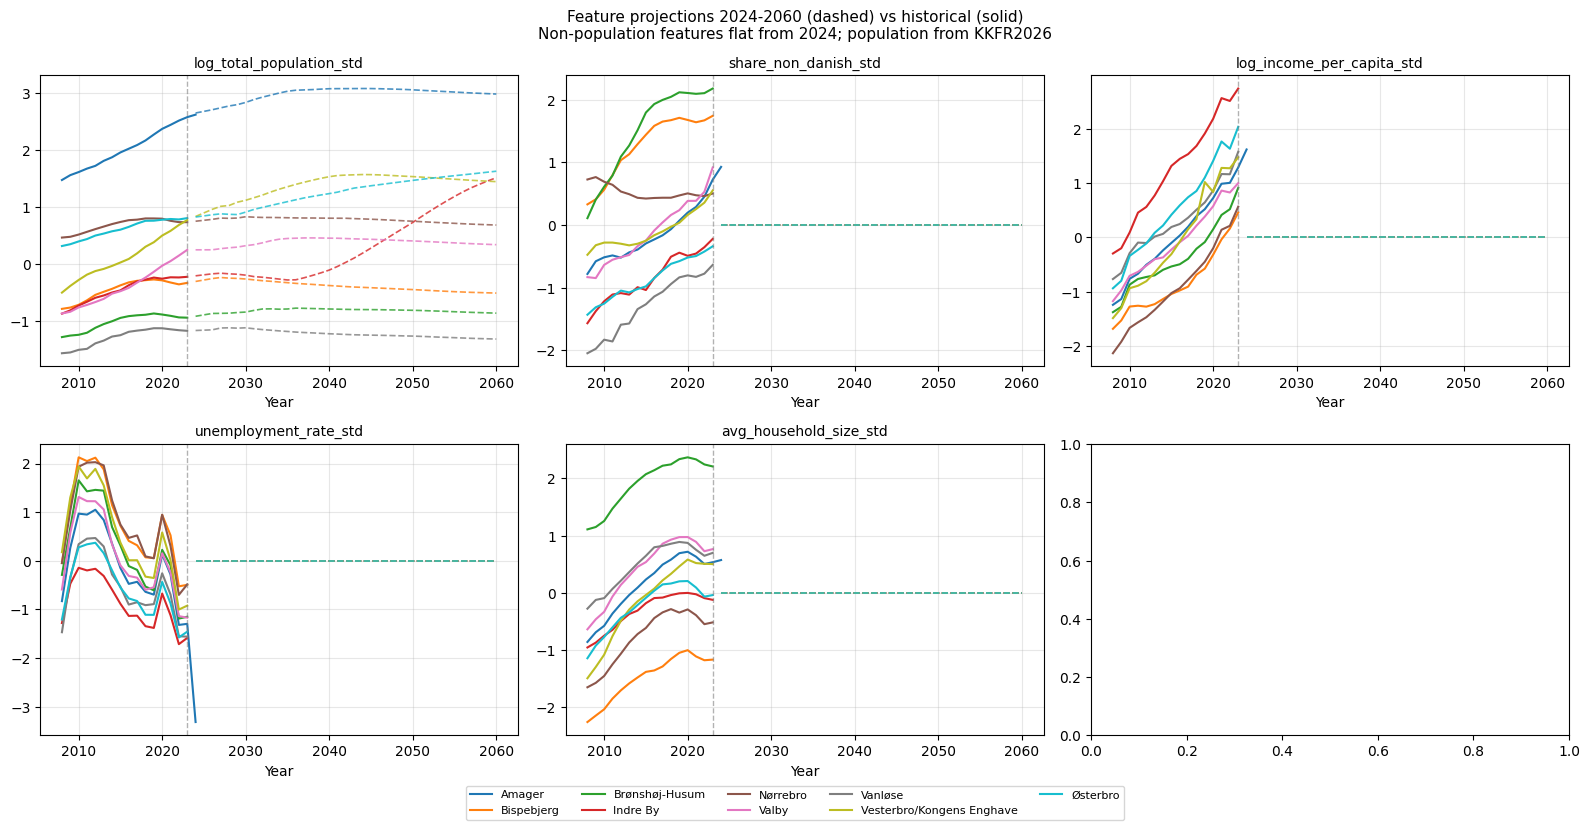

In [100]:
FORECAST_YEARS = np.arange(2024, 2061)  # 37 years
h_long = len(FORECAST_YEARS)

# ── Load KKFR2026 projection and build district totals ─────────────────────
_fpp = pd.read_csv('data/cleaned/future_population_panel.csv')
_pop_cols = [c for c in _fpp.columns if c.startswith('proj_pop_')]
_fpp['total_projected_pop'] = _fpp[_pop_cols].sum(axis=1)
_fpp['year'] = _fpp['year'].astype(int)

# Amager Vest + Amager Øst → 'Amager' (matches the 9-district model panel)
_amager_mask = _fpp['district'].isin(['Amager Vest', 'Amager Øst'])
_amager = _fpp[_amager_mask].groupby('year', as_index=False)['total_projected_pop'].sum()
_amager['district'] = 'Amager'
_fpp_clean = pd.concat([
    _fpp[~_amager_mask][['district', 'year', 'total_projected_pop']],
    _amager,
], ignore_index=True)

# ── Scaler: raw log_total_population moments from Phase 2 StandardScaler ───
# feature_scaler was fit on the raw (pre-standardisation) columns in cell 41.
# features_to_scale order: ['log_total_population', 'share_non_danish',
#   'log_income_per_capita', 'unemployment_rate', 'avg_household_size']
_lp_col_idx = list(feature_scaler.feature_names_in_).index('log_total_population') \
    if hasattr(feature_scaler, 'feature_names_in_') \
    else ['log_total_population', 'share_non_danish', 'log_income_per_capita',
          'unemployment_rate', 'avg_household_size'].index('log_total_population')
_lp_raw_mean = float(feature_scaler.mean_[_lp_col_idx])
_lp_raw_std  = float(feature_scaler.scale_[_lp_col_idx])
print(f'log_total_population scaler: mean={_lp_raw_mean:.4f}, std={_lp_raw_std:.4f}')

# ── Build X_future_2060 ────────────────────────────────────────────────────
CONSTANT_FEATS = [
    'log_income_per_capita_std',
    'unemployment_rate_std',
    'avg_household_size_std',
    'share_non_danish_std',
]

X_future_2060 = {}  # district -> np.ndarray [h_long, K]

for dname in districts:
    dist_rows = panel_df[panel_df['district'] == dname].sort_values('year')
    val_2023  = dist_rows[dist_rows['year'] == dist_rows['year'].max()]

    feat_proj = np.zeros((h_long, K))

    # KKFR2026 projected log population for this district (2026-2060)
    _dpop = _fpp_clean[_fpp_clean['district'] == dname].set_index('year')

    # 2026 anchor for interpolation
    _lp_2026 = None
    if 2026 in _dpop.index:
        _raw_2026 = float(_dpop.loc[2026, 'total_projected_pop'])
        if _raw_2026 > 0:
            _lp_2026 = (np.log(_raw_2026) - _lp_raw_mean) / _lp_raw_std

    # 2023 observed standardised log population
    _lp_2023 = float(val_2023['log_total_population_std'].values[0])

    for k_idx, feat in enumerate(FEATURE_COLS_STD):

        if feat == 'log_total_population_std':
            for t_idx, yr in enumerate(FORECAST_YEARS):
                if yr >= 2026 and yr in _dpop.index:
                    # KKFR2026: standardise raw population using Phase 2 scaler moments
                    raw_pop = float(_dpop.loc[yr, 'total_projected_pop'])
                    feat_proj[t_idx, k_idx] = (np.log(raw_pop) - _lp_raw_mean) / _lp_raw_std
                elif yr < 2026 and _lp_2026 is not None:
                    # 2024-2025: linear interpolation between 2023 observed and 2026 KKFR2026
                    alpha = (yr - 2023) / (2026 - 2023)  # 0→1 over 3 years
                    feat_proj[t_idx, k_idx] = _lp_2023 + alpha * (_lp_2026 - _lp_2023)
                else:
                    feat_proj[t_idx, k_idx] = _lp_2023  # fallback

        else:
            # Hold each non-population feature constant at its district-specific 2023
            # observed value. These are substantive socioeconomic indicators — their
            # cross-district variation is meaningful and should be preserved.
            feat_proj[:, k_idx] = float(val_2023[feat].values[0])

    X_future_2060[dname] = feat_proj

X_future_2060_D = torch.tensor(
    np.stack([X_future_2060[d] for d in districts], axis=0),
    dtype=torch.float,
)  # [D, 37, K]

print(f'X_future_2060_D shape: {tuple(X_future_2060_D.shape)}')

# Sanity-check: print log_total_population_std for one district around the 2023/2024 boundary
_example = districts[0]
_ex_idx  = FEATURE_COLS_STD.index('log_total_population_std')
_ex_hist = panel_df[panel_df['district'] == _example].sort_values('year')
print(f'\n{_example} — log_total_population_std around 2023/2024 boundary:')
for yr in [2021, 2022, 2023]:
    row = _ex_hist[_ex_hist['year'] == yr]
    if not row.empty:
        print(f'  {yr} (obs):  {float(row["log_total_population_std"].values[0]):.4f}')
for t_idx, yr in enumerate(FORECAST_YEARS[:5]):
    print(f'  {int(yr)} (proj): {X_future_2060[_example][t_idx, _ex_idx]:.4f}')

# ── Diagnostic plot ────────────────────────────────────────────────────────
_colors = plt.cm.tab10(np.linspace(0, 1, len(districts)))
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for k_idx, feat in enumerate(FEATURE_COLS_STD):
    ax = axes[k_idx]
    for d_idx, dname in enumerate(districts):
        hist_sub = panel_df[panel_df['district'] == dname].sort_values('year')
        ax.plot(hist_sub['year'], hist_sub[feat],
                color=_colors[d_idx], linewidth=1.5, label=dname)
        ax.plot(FORECAST_YEARS, X_future_2060[dname][:, k_idx],
                color=_colors[d_idx], linewidth=1.2, linestyle='--', alpha=0.8)
    ax.axvline(2023, color='grey', linestyle='--', alpha=0.6, linewidth=1)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    'Feature projections 2024-2060 (dashed) vs historical (solid)\n'
    'Non-population features flat from 2024; population from KKFR2026',
    fontsize=11
)
plt.tight_layout()
plt.show()

### 5.2 Simulate posterior predictive paths to 2060

We draw 600 posterior samples of φ_d, β, and σ_g from the Model 5 NUTS posterior and simulate forward from the last known training state (end of 2023) for each district. Each sample produces one plausible price path in z-scored centered-diff space. Taking quantiles across samples gives the credible interval.

In [101]:
# Normalize posterior arrays: Pyro can return scalar sample sites as 0-dim tensors
# depending on the model version that was run last. Flatten to guaranteed 1-D numpy.
_phi_d_s = np.asarray(phi_d_s).reshape(-1, D)   # [S, D]
_beta_s  = np.asarray(beta_s).reshape(-1, K)    # [S, K]
_sig_s   = np.asarray(sig_s).flatten()           # [S]
S_long = min(600, _phi_d_s.shape[0])

# paths_g_2060[d_idx] = tensor [S_long, h_long] of centered diffs in z-space
paths_g_2060 = []

for d_idx in range(D):
    paths_d = []
    for s in range(S_long):
        ph = torch.tensor(_phi_d_s[s, d_idx], dtype=torch.float)
        b  = torch.tensor(_beta_s[s],          dtype=torch.float)
        sg = torch.tensor(_sig_s[s],            dtype=torch.float)

        out  = []
        prev = g0_c_D[d_idx]  # last centered diff from training
        for t in range(h_long):
            mean = ph * prev + X_future_2060_D[d_idx, t] @ b
            prev = dist.Normal(mean, sg).sample()
            out.append(prev)
        paths_d.append(torch.stack(out))
    paths_g_2060.append(torch.stack(paths_d))  # [S_long, h_long]

print(f'Simulation complete. paths_g_2060[0].shape = {tuple(paths_g_2060[0].shape)}')

Simulation complete. paths_g_2060[0].shape = (600, 37)


### 5.3 Back-transform to DKK/m²

We do not add back the training-period mean difference `g_mean` in the long-range forecast. The 2008–2023 training period captured an unusually strong housing boom driven by falling interest rates and urbanisation. Projecting that exact growth rate forward 37 years would compound to economically unrealistic price levels (prices ×4–5 by 2060). The systematic time trend is already captured by the `year_std_std` feature and its learned `beta` coefficient — adding `g_mean` on top would double-count it. The forecast therefore shows deviation from the 2023 price level driven by demographic and temporal effects through the model's learned feature weights.

The same convention is applied to the test-period credible intervals for consistency. The observed test prices are reconstructed by adding `g_mean` back since those are actual historical observations, not forecasts.

We also recompute the test-period (2019–2023) credible intervals here for use in the per-district plots.

In [102]:
# ── Sanity check before back-transform ──────────────────────────────────────
_pg_all = torch.stack(paths_g_2060)  # [D, S_long, h_long]
print("paths_g_2060 stats — mean:", _pg_all.mean().item(),
      "std:", _pg_all.std().item(),
      "max abs:", _pg_all.abs().max().item())
print("g_mean_D:", g_mean_D)
print("y_last_z_D:", y_last_z_D)
print("y_std_D:", y_std_D)
print("y_mean_D:", y_mean_D)
if _pg_all.abs().max().item() > 5.0:
    raise ValueError("Forecast diverged in z-space (max abs diff > 5.0) — debug before plotting.")

# ── Long-range forecast back-transform ──────────────────────────────────────
p10_2060 = np.zeros((D, h_long))
p50_2060 = np.zeros((D, h_long))
p90_2060 = np.zeros((D, h_long))

for d_idx in range(D):
    pg = paths_g_2060[d_idx]  # [S_long, h_long]
    unc   = pg  # no g_mean: avoid compounding 2008-2023 boom drift over 37 years
    lev_z = y_last_z_D[d_idx] + torch.cumsum(unc, dim=1)
    lev   = lev_z * y_std_D[d_idx] + y_mean_D[d_idx]
    price = torch.exp(lev)
    p10_2060[d_idx] = price.quantile(0.10, dim=0).detach().numpy()
    p50_2060[d_idx] = price.quantile(0.50, dim=0).detach().numpy()
    p90_2060[d_idx] = price.quantile(0.90, dim=0).detach().numpy()

# ── Test-period (2019-2023) back-transform ───────────────────────────────────
# Recompute using g_test_c_D already in scope from Model 5
p10_test = np.zeros((D, len(years_test)))
p50_test = np.zeros((D, len(years_test)))
p90_test = np.zeros((D, len(years_test)))
obs_test = np.zeros((D, len(years_test)))

for d_idx in range(D):
    paths_test = []
    for s in range(S_long):
        ph = torch.tensor(_phi_d_s[s, d_idx], dtype=torch.float)
        b  = torch.tensor(_beta_s[s],          dtype=torch.float)
        sg = torch.tensor(_sig_s[s],            dtype=torch.float)
        out, prev = [], g0_c_D[d_idx]
        for t in range(len(years_test)):
            mean = ph * prev + X_g_future_D[d_idx, t] @ b
            prev = dist.Normal(mean, sg).sample()
            out.append(prev)
        paths_test.append(torch.stack(out))
    pg_test = torch.stack(paths_test)  # [S_long, h_test]
    unc_t   = pg_test  # no g_mean: consistent with long-range convention
    lev_z_t = y_last_z_D[d_idx] + torch.cumsum(unc_t, dim=1)
    lev_t   = lev_z_t * y_std_D[d_idx] + y_mean_D[d_idx]
    price_t = torch.exp(lev_t)
    p10_test[d_idx] = price_t.quantile(0.10, dim=0).detach().numpy()
    p50_test[d_idx] = price_t.quantile(0.50, dim=0).detach().numpy()
    p90_test[d_idx] = price_t.quantile(0.90, dim=0).detach().numpy()

    # Observed test prices: back-transform from g_test_c_D
    g_te_raw   = g_test_c_D[d_idx]  # no g_mean: consistent with forecast convention
    y_te_lev_z = y_last_z_D[d_idx] + torch.cumsum(g_te_raw, dim=0)
    y_te_log   = y_te_lev_z * y_std_D[d_idx] + y_mean_D[d_idx]
    obs_test[d_idx] = torch.exp(y_te_log).detach().numpy()

print('Back-transform complete.')
print(f'  p50_2060 range across all districts: '
      f'{p50_2060.min():.0f} – {p50_2060.max():.0f} DKK/m²')

paths_g_2060 stats — mean: 0.028466597199440002 std: 0.4395827651023865 max abs: 2.6240034103393555
g_mean_D: tensor([0.2284, 0.1506, 0.1536, 0.2204, 0.1988, 0.2324, 0.2021, 0.1946, 0.2286])
y_last_z_D: tensor([1.6020, 1.5246, 1.7240, 1.5599, 1.4971, 1.5575, 1.8305, 1.3640, 1.5561])
y_std_D: tensor([0.2013, 0.2412, 0.1554, 0.2217, 0.2760, 0.1762, 0.1665, 0.2371, 0.2331])
y_mean_D: tensor([10.2350, 10.0820, 10.1108, 10.4807, 10.2289, 10.2039, 10.1583, 10.3422,
        10.3851])
Back-transform complete.
  p50_2060 range across all districts: 23453 – 134957 DKK/m²


### 5.4 Per-district forecast plots

Each plot shows the full historical observed price series (2008–2023, solid black), the test-period (2019–2023) forecast with an 80% credible band and median line, and the 2024–2060 forecast with its 80% credible band and median. Two vertical dashed lines mark the train/test split (2019) and the forecast start (2024).

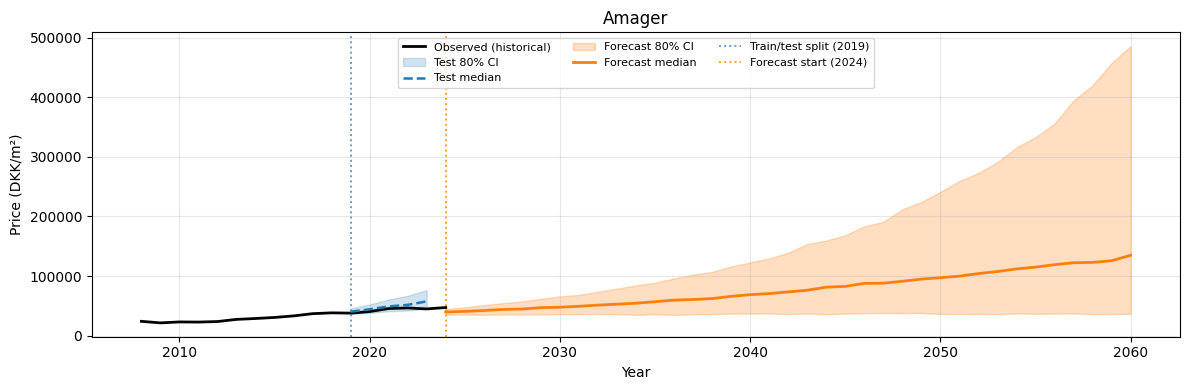

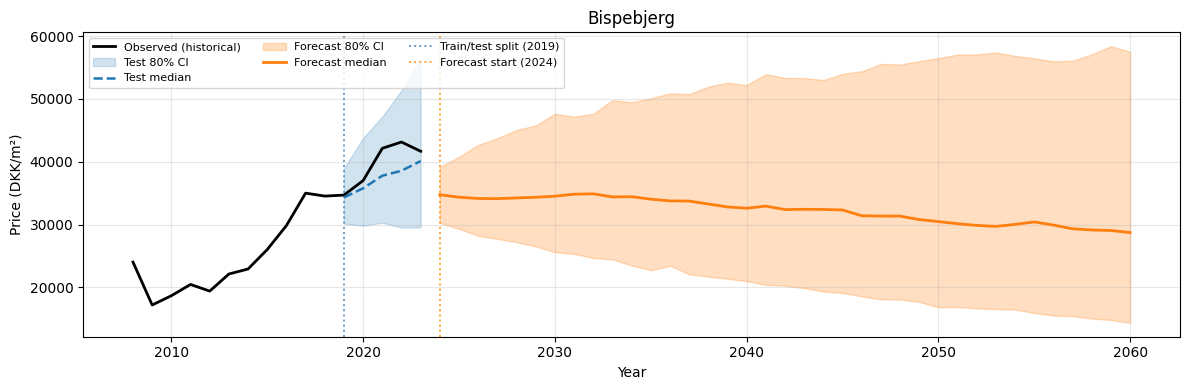

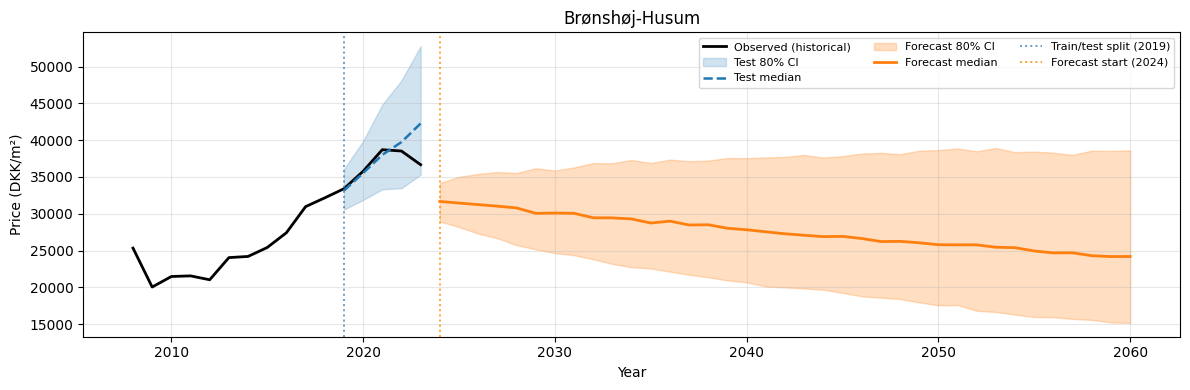

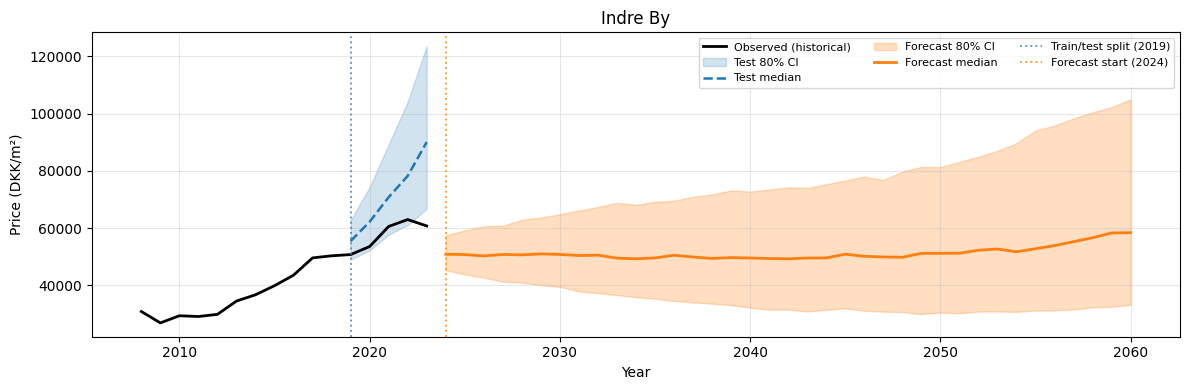

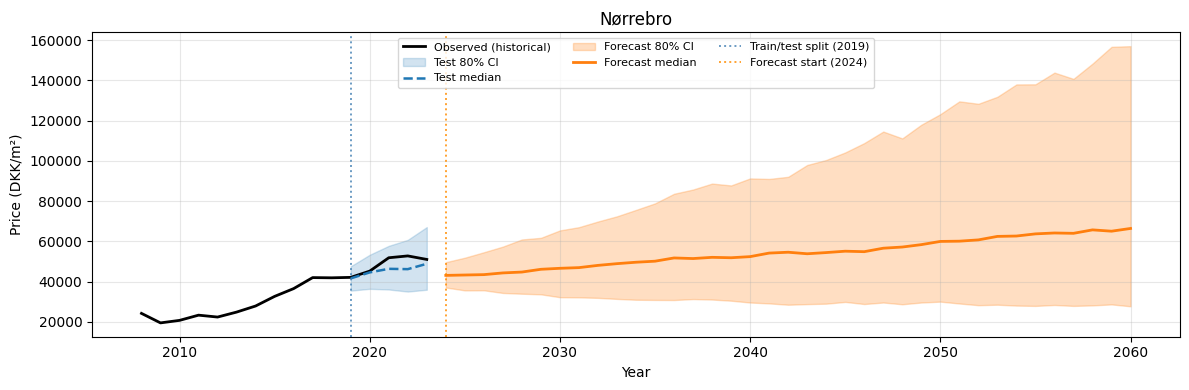

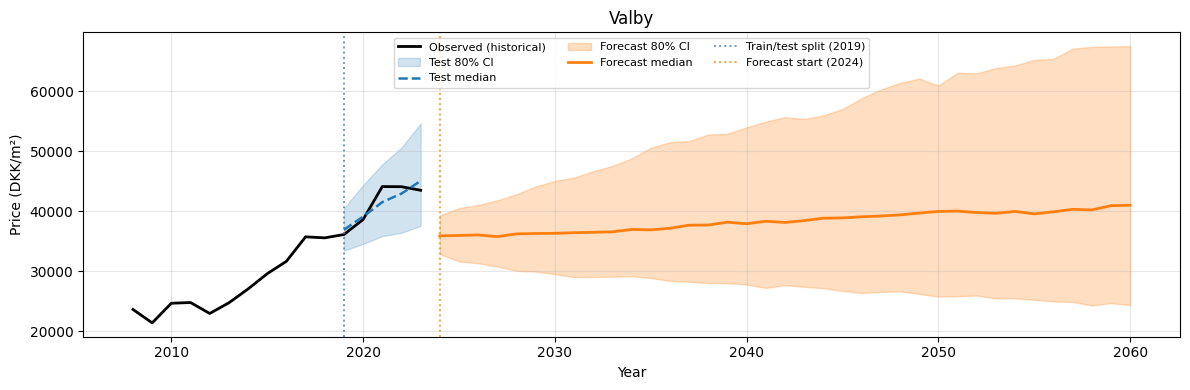

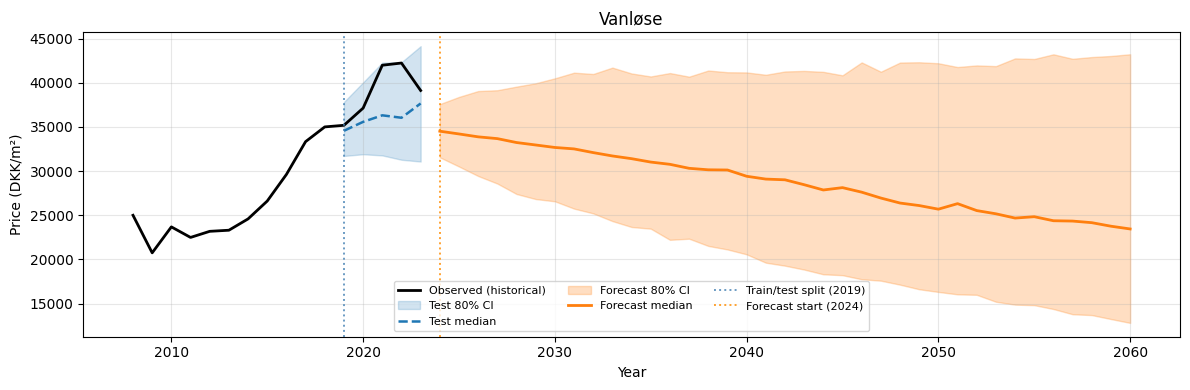

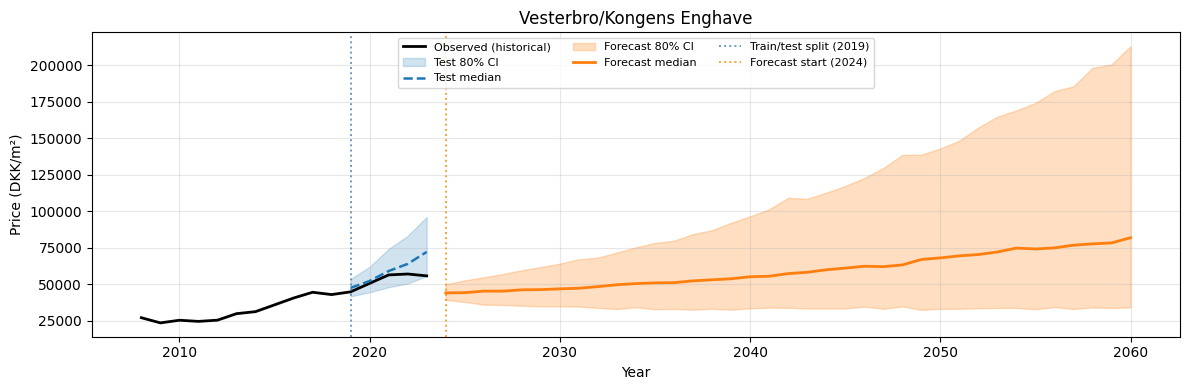

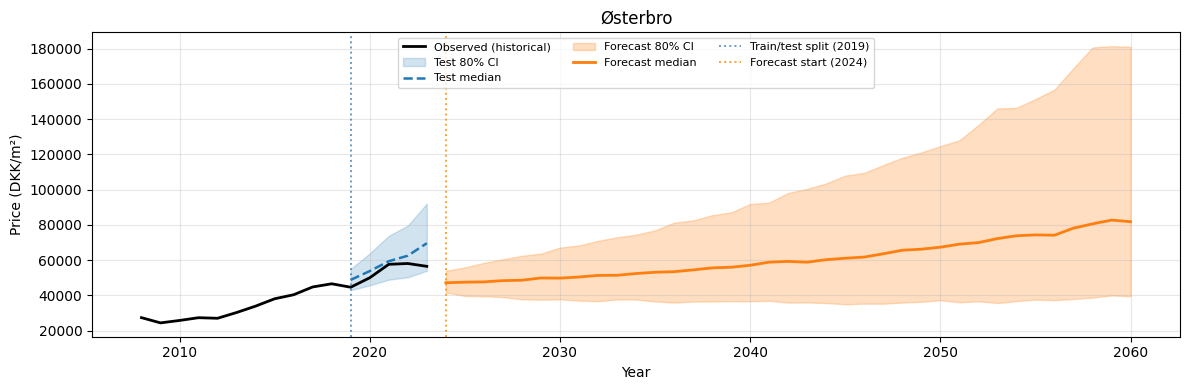

In [103]:
for d_idx, dname in enumerate(districts):
    # Historical observed prices from panel
    hist_sub = (
        panel_df[panel_df['district'] == dname]
        .sort_values('year')
    )
    hist_years  = hist_sub['year'].to_numpy()
    hist_prices = np.exp(hist_sub['median_log_sqm_price'].to_numpy())

    fig, ax = plt.subplots(figsize=(12, 4))

    # Historical observed (full 2008-2023)
    ax.plot(hist_years, hist_prices,
            color='black', linewidth=2, label='Observed (historical)')

    # Test period forecast band and median
    ax.fill_between(years_test,
                    p10_test[d_idx], p90_test[d_idx],
                    alpha=0.2, color='C0', label='Test 80% CI')
    ax.plot(years_test, p50_test[d_idx],
            color='C0', linewidth=1.8, linestyle='--', label='Test median')

    # Long-range forecast band and median
    ax.fill_between(FORECAST_YEARS,
                    p10_2060[d_idx], p90_2060[d_idx],
                    alpha=0.25, color='C1', label='Forecast 80% CI')
    ax.plot(FORECAST_YEARS, p50_2060[d_idx],
            color='C1', linewidth=2, label='Forecast median')

    ax.axvline(years_test[0], color='steelblue', linestyle=':', alpha=0.8,
               linewidth=1.4, label=f'Train/test split ({int(years_test[0])})')
    ax.axvline(FORECAST_YEARS[0], color='darkorange', linestyle=':', alpha=0.8,
               linewidth=1.4, label=f'Forecast start ({FORECAST_YEARS[0]})')

    ax.set_title(dname)
    ax.set_xlabel('Year')
    ax.set_ylabel('Price (DKK/m²)')
    ax.legend(fontsize=8, ncol=3)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 5.5 All-districts comparison

The combined view shows how the nine districts are projected to diverge over the forecast horizon. Districts with stronger projected population growth and income trends are expected to show higher price appreciation. The dashed vertical line marks the start of the forecast period (2024).

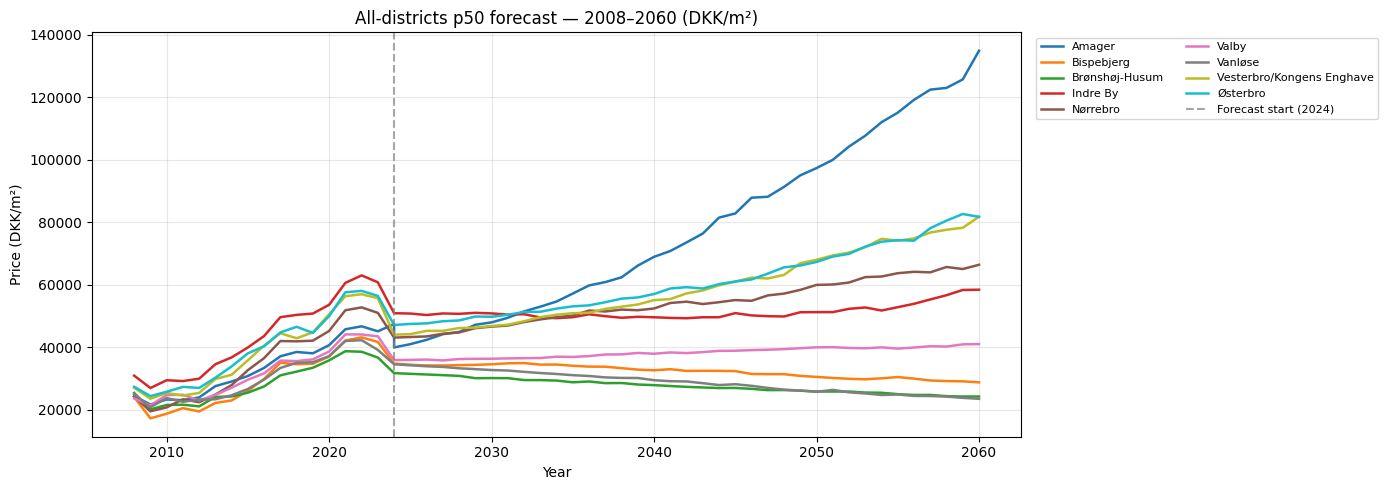

In [104]:
fig, ax = plt.subplots(figsize=(14, 5))
_colors_d = plt.cm.tab10(np.linspace(0, 1, len(districts)))

for d_idx, dname in enumerate(districts):
    hist_sub = (
        panel_df[panel_df['district'] == dname]
        .sort_values('year')
    )
    hist_years  = hist_sub['year'].to_numpy()
    hist_prices = np.exp(hist_sub['median_log_sqm_price'].to_numpy())

    all_years  = np.concatenate([hist_years,  FORECAST_YEARS])
    all_prices = np.concatenate([hist_prices, p50_2060[d_idx]])

    ax.plot(all_years, all_prices,
            color=_colors_d[d_idx], linewidth=1.8, label=dname)

ax.axvline(FORECAST_YEARS[0], color='grey', linestyle='--', alpha=0.7,
           linewidth=1.5, label='Forecast start (2024)')
ax.set_title('All-districts p50 forecast — 2008–2060 (DKK/m²)')
ax.set_xlabel('Year')
ax.set_ylabel('Price (DKK/m²)')
ax.legend(fontsize=8, ncol=2, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.6 Test-period evaluation metrics

Before interpreting the long-range forecast we verify the model's predictive calibration on the held-out 2019–2023 test period. RMSE measures point forecast accuracy in DKK/m². Coverage measures whether the stated 80% credible interval is honest — a well-calibrated model should have approximately 80% of test observations fall inside the interval.

In [105]:
print("{:<30} {:>15} {:>14}".format("District", "RMSE (DKK/m2)", "80% Coverage"))
print('-' * 62)

rmses, coverages = [], []
for d_idx, dname in enumerate(districts):
    obs  = obs_test[d_idx]
    pred = p50_test[d_idx]
    rmse = float(np.sqrt(np.mean((pred - obs) ** 2)))
    inside = np.mean((obs >= p10_test[d_idx]) & (obs <= p90_test[d_idx]))
    rmses.append(rmse)
    coverages.append(inside)
    print(f'{dname:<30} {rmse:>15,.0f} {inside:>13.0%}')

print('-' * 62)
label = "Mean"
print(f"{label:<30} {np.mean(rmses):>15,.0f} {np.mean(coverages):>13.0%}")

District                         RMSE (DKK/m2)   80% Coverage
--------------------------------------------------------------
Amager                                   6,627           80%
Bispebjerg                               2,966          100%
Brønshøj-Husum                           2,589          100%
Indre By                                16,069           80%
Nørrebro                                 3,970          100%
Valby                                    1,508          100%
Vanløse                                  3,884          100%
Vesterbro/Kongens Enghave                8,169          100%
Østerbro                                 6,727          100%
--------------------------------------------------------------
Mean                                     5,834           96%


**Methodological comparison — Variational Inference (SVI):** The cell below re-fits the same model using `AutoDiagonalNormal` SVI as a comparison against MCMC above. For a low-parameter model, NUTS gives exact posterior samples; SVI is a mean-field approximation. **This is not a main result — the MCMC forecast above is the primary inference.** Outputs are in z-space centered diffs only (no back-transformation).

[HARX-hierNN VI] D=9, T=16, T_train=11, L=10, h=5, K=5, H=8
[HARX-hierNN VI] SVI step     0  ELBO loss: 1738.42
[HARX-hierNN VI] SVI step   500  ELBO loss: 170.75
[HARX-hierNN VI] SVI step  1000  ELBO loss: 155.29
[HARX-hierNN VI] SVI step  1500  ELBO loss: 156.02
[HARX-hierNN VI] SVI step  2000  ELBO loss: 120.28
[HARX-hierNN VI] SVI step  2500  ELBO loss: 125.37
[HARX-hierNN VI] SVI step  3000  ELBO loss: 120.62
[HARX-hierNN VI] SVI step  3500  ELBO loss: 115.75
[HARX-hierNN VI] SVI step  3999  ELBO loss: 123.21
[HARX-hierNN VI] predictive sites: ['phi_raw_d', 'W1_d', 'b1_d', 'w2_d', 'b2_d', 'sigma_g']
[HARX-hierNN VI] sigma_g mean: 0.37678274512290955
[HARX-hierNN VI] phi_d posterior means: [-0.065 -0.062 -0.069 -0.131 -0.104 -0.098 -0.129 -0.056 -0.123]


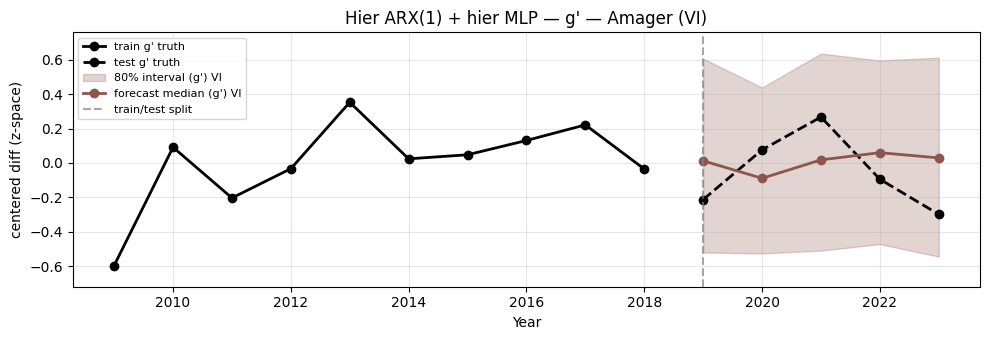

[HARX-hierNN VI] Amager 2019 median error (g'): +0.2258
[HARX-hierNN VI] Amager 2020 median error (g'): -0.1657
[HARX-hierNN VI] Amager 2021 median error (g'): -0.2495
[HARX-hierNN VI] Amager 2022 median error (g'): +0.1546
[HARX-hierNN VI] Amager 2023 median error (g'): +0.3287


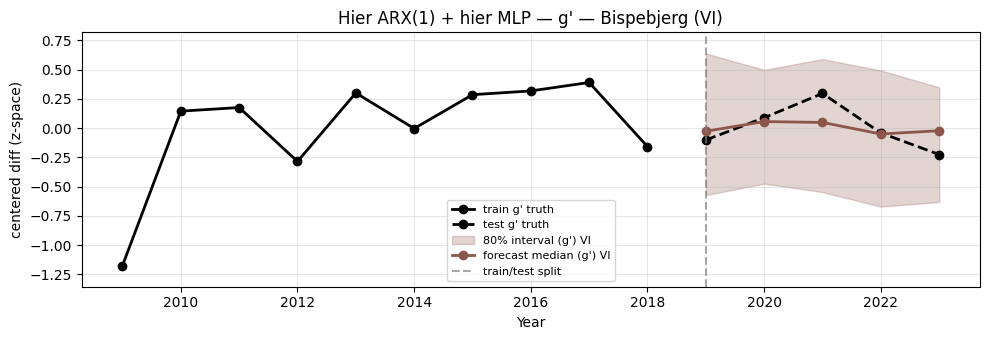

[HARX-hierNN VI] Bispebjerg 2019 median error (g'): +0.0750
[HARX-hierNN VI] Bispebjerg 2020 median error (g'): -0.0330
[HARX-hierNN VI] Bispebjerg 2021 median error (g'): -0.2478
[HARX-hierNN VI] Bispebjerg 2022 median error (g'): -0.0093
[HARX-hierNN VI] Bispebjerg 2023 median error (g'): +0.2035


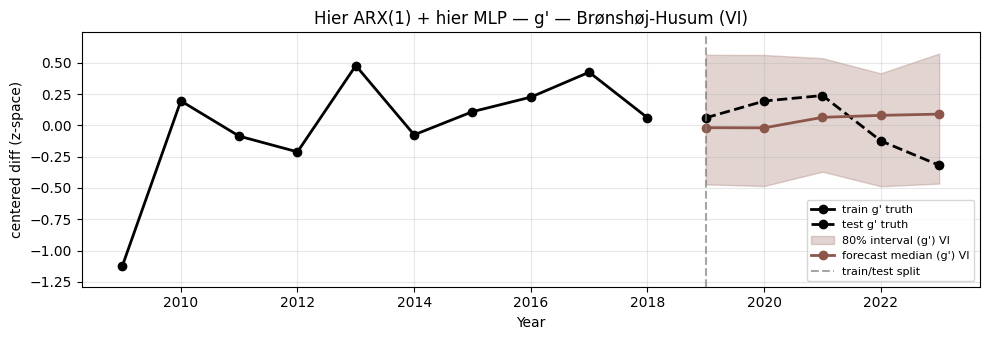

[HARX-hierNN VI] Brønshøj-Husum 2019 median error (g'): -0.0789
[HARX-hierNN VI] Brønshøj-Husum 2020 median error (g'): -0.2141
[HARX-hierNN VI] Brønshøj-Husum 2021 median error (g'): -0.1743
[HARX-hierNN VI] Brønshøj-Husum 2022 median error (g'): +0.2039
[HARX-hierNN VI] Brønshøj-Husum 2023 median error (g'): +0.4084


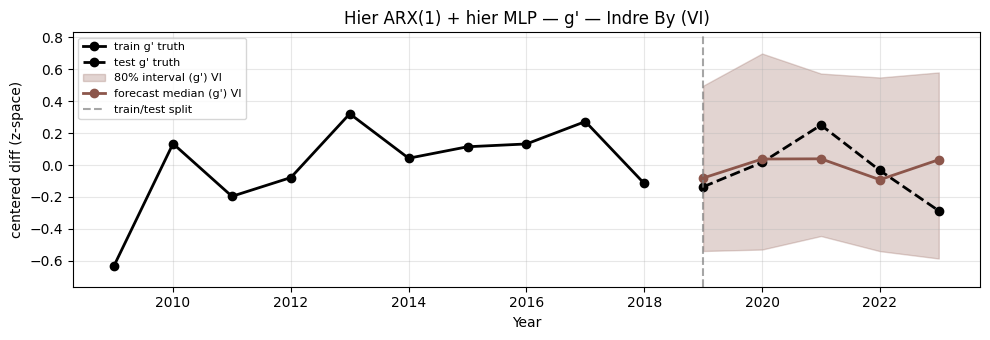

[HARX-hierNN VI] Indre By 2019 median error (g'): +0.0551
[HARX-hierNN VI] Indre By 2020 median error (g'): +0.0216
[HARX-hierNN VI] Indre By 2021 median error (g'): -0.2115
[HARX-hierNN VI] Indre By 2022 median error (g'): -0.0580
[HARX-hierNN VI] Indre By 2023 median error (g'): +0.3200


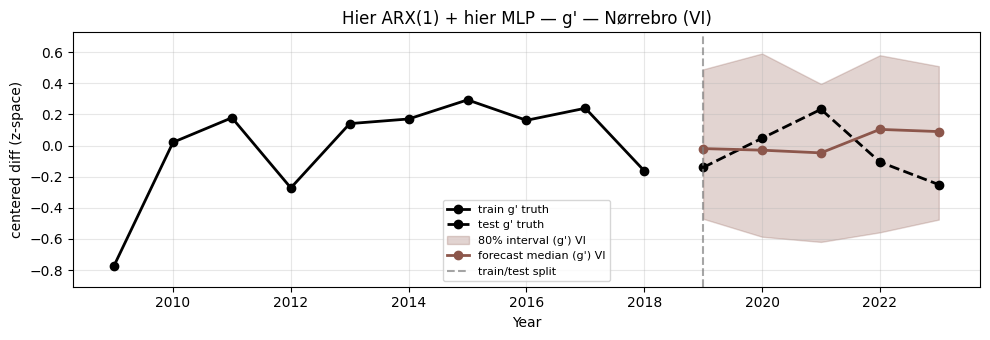

[HARX-hierNN VI] Nørrebro 2019 median error (g'): +0.1212
[HARX-hierNN VI] Nørrebro 2020 median error (g'): -0.0766
[HARX-hierNN VI] Nørrebro 2021 median error (g'): -0.2797
[HARX-hierNN VI] Nørrebro 2022 median error (g'): +0.2093
[HARX-hierNN VI] Nørrebro 2023 median error (g'): +0.3405


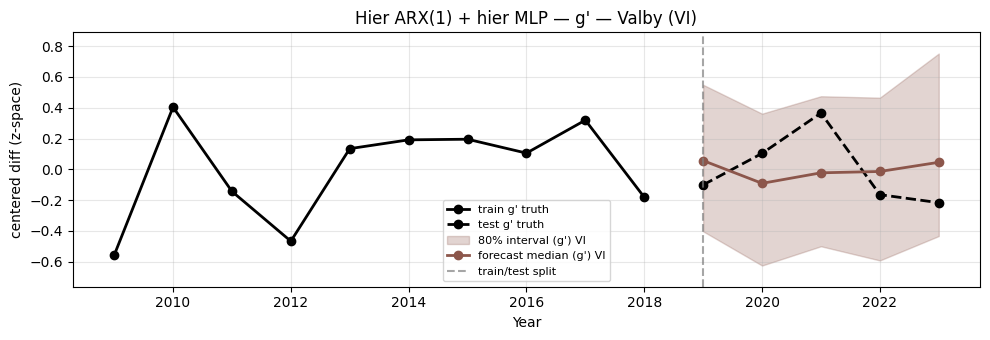

[HARX-hierNN VI] Valby 2019 median error (g'): +0.1576
[HARX-hierNN VI] Valby 2020 median error (g'): -0.1946
[HARX-hierNN VI] Valby 2021 median error (g'): -0.3883
[HARX-hierNN VI] Valby 2022 median error (g'): +0.1505
[HARX-hierNN VI] Valby 2023 median error (g'): +0.2622


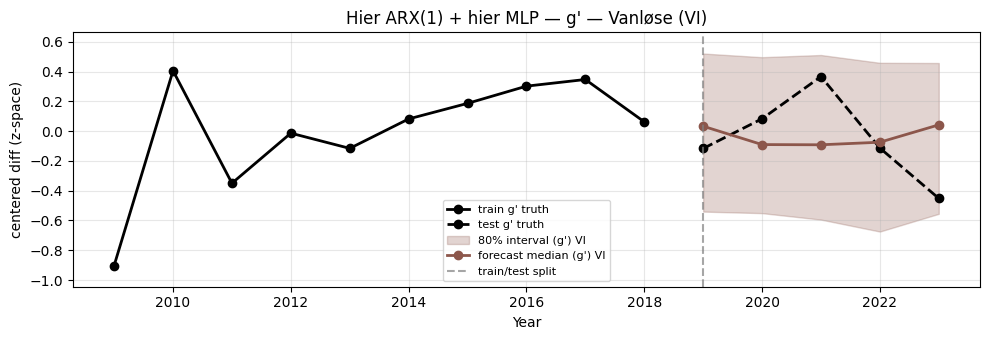

[HARX-hierNN VI] Vanløse 2019 median error (g'): +0.1495
[HARX-hierNN VI] Vanløse 2020 median error (g'): -0.1733
[HARX-hierNN VI] Vanløse 2021 median error (g'): -0.4581
[HARX-hierNN VI] Vanløse 2022 median error (g'): +0.0390
[HARX-hierNN VI] Vanløse 2023 median error (g'): +0.4936


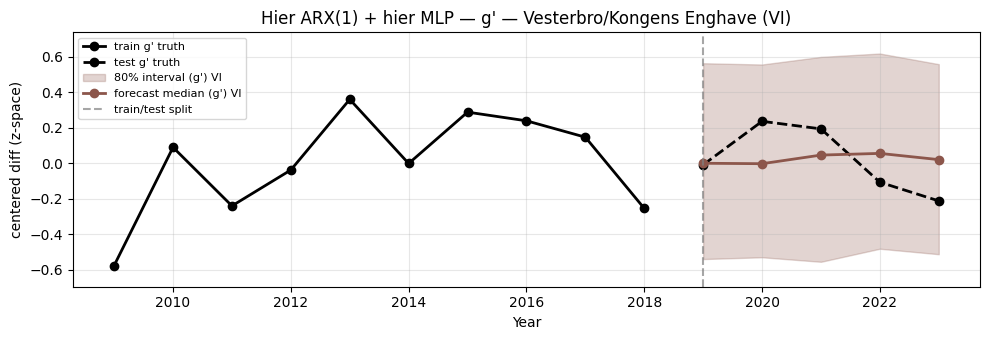

[HARX-hierNN VI] Vesterbro/Kongens Enghave 2019 median error (g'): +0.0086
[HARX-hierNN VI] Vesterbro/Kongens Enghave 2020 median error (g'): -0.2388
[HARX-hierNN VI] Vesterbro/Kongens Enghave 2021 median error (g'): -0.1476
[HARX-hierNN VI] Vesterbro/Kongens Enghave 2022 median error (g'): +0.1624
[HARX-hierNN VI] Vesterbro/Kongens Enghave 2023 median error (g'): +0.2326


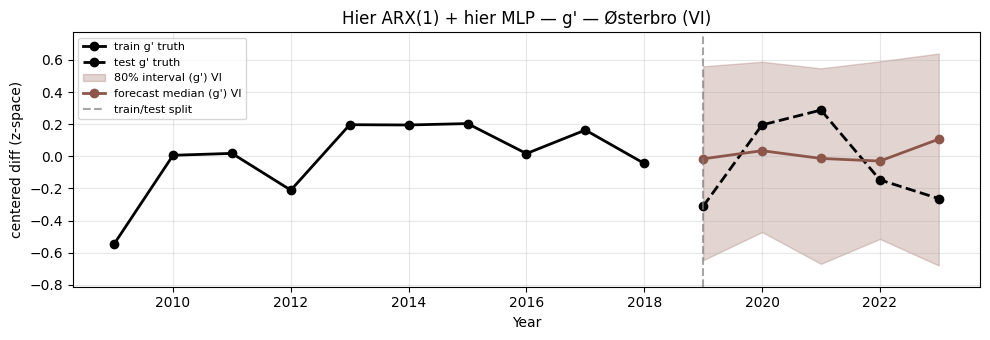

[HARX-hierNN VI] Østerbro 2019 median error (g'): +0.2955
[HARX-hierNN VI] Østerbro 2020 median error (g'): -0.1606
[HARX-hierNN VI] Østerbro 2021 median error (g'): -0.3013
[HARX-hierNN VI] Østerbro 2022 median error (g'): +0.1171
[HARX-hierNN VI] Østerbro 2023 median error (g'): +0.3700
[SVI restore] Phase 5 variables restored.


In [106]:
# ---------------------------------------------------------------------------
# Save Phase 5 state before SVI overwrites shared variable names
# ---------------------------------------------------------------------------
_phase5_saved = {
    'g_mean_D':     g_mean_D,
    'y_mean_D':     y_mean_D,
    'y_std_D':      y_std_D,
    'y_last_z_D':   y_last_z_D,
    'g0_c_D':       g0_c_D,
    'X_g_future_D': X_g_future_D,
    'g_test_c_D':   g_test_c_D,
    'phi_d_s':      phi_d_s,
    'beta_s':       beta_s,
    'sig_s':        sig_s,
    'post_h':       post_h,
}

N_TEST = 5
H_HIDDEN = 8

TAU_PHI_SCALE = 3.0
TAU_W1_SCALE = 2.0
TAU_B1_SCALE = 2.0
TAU_W2_SCALE = 2.0
TAU_B2_SCALE = 2.0

MU_PHI_PRIOR_SD = 2.0

# SVI (if loss becomes nan, set SVI_LR = 0.001)
SVI_NUM_STEPS = 4000
SVI_LR = 0.01
S_VI = 500

panel_df = model_panel_restricted_withfeatures

FEATURE_COLS_STD = [
    "log_total_population_std",
    "share_non_danish_std",
    "log_income_per_capita_std",
    "unemployment_rate_std",
    "avg_household_size_std",
]

_keep = ["district", "year", "median_log_sqm_price", *FEATURE_COLS_STD]
_miss = [c for c in _keep if c not in panel_df.columns]
if _miss:
    raise KeyError(f"model_panel_restricted_withfeatures missing columns {_miss}")

years_all = np.sort(panel_df.loc[panel_df["year"] <= 2023, "year"].unique())
districts = sorted(panel_df["district"].unique())
D = len(districts)
T = len(years_all)
T_train = max(5, T - N_TEST)
h = T - T_train
L = T_train - 1
K = len(FEATURE_COLS_STD)

if L < 2:
    raise ValueError("Need L >= 2 train diffs per district.")

years_train = years_all[:T_train]
years_test = years_all[T_train:]


class DistrictHierarchicalMLP(PyroModule):

    def forward(self, x, W1, b1, w2, b2):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        h = torch.tanh(F.linear(x, W1, b1))
        Wo = w2.unsqueeze(0)
        bo = b2.reshape(1)
        return F.linear(h, Wo, bo).squeeze(-1)


district_mlp = DistrictHierarchicalMLP()


def _block_one_district(dname):
    sub = (
        panel_df.loc[panel_df["district"] == dname, _keep]
        .dropna()
        .sort_values("year")
    )
    sub = sub[sub["year"].isin(years_all)].copy()
    if sub["year"].nunique() != T:
        miss = sorted(set(years_all) - set(sub["year"].unique()))
        raise ValueError(f"District {dname!r} missing years: {miss}")
    sub = sub.set_index("year").loc[years_all].reset_index()
    y = torch.tensor(sub["median_log_sqm_price"].to_numpy(), dtype=torch.float)
    X = torch.tensor(sub[FEATURE_COLS_STD].to_numpy(), dtype=torch.float)
    y_mean = y.mean()
    y_std = y.std()
    y_std = y_std if y_std > 0 else torch.tensor(1.0)
    y_z = (y - y_mean) / y_std
    y_train_z = y_z[:T_train]
    y_test_z = y_z[T_train:]
    g = y_z[1:] - y_z[:-1]
    X_g = X[1:]
    g_train = g[:L]
    X_g_train = X_g[:L]
    g_mean = g_train.mean()
    g_train_c = g_train - g_mean
    g0_c = g_train_c[-1]
    X_g_future = X_g[T_train - 1 : T_train - 1 + h]
    g_test = torch.empty_like(y_test_z)
    if len(y_test_z):
        g_test[0] = y_test_z[0] - y_train_z[-1]
        if len(y_test_z) > 1:
            g_test[1:] = y_test_z[1:] - y_test_z[:-1]
    g_test_c = g_test - g_mean if len(y_test_z) else torch.empty(0)
    return {
        "g_train_c": g_train_c,
        "X_g_train": X_g_train,
        "g0_c": g0_c,
        "X_g_future": X_g_future,
        "g_test_c": g_test_c,
    }


blocks = [_block_one_district(d) for d in districts]
g_train_c_D = torch.stack([b["g_train_c"] for b in blocks], dim=0)
X_g_train_D = torch.stack([b["X_g_train"] for b in blocks], dim=0)
g0_c_D = torch.stack([b["g0_c"] for b in blocks], dim=0)
X_g_future_D = torch.stack([b["X_g_future"] for b in blocks], dim=0)
g_test_c_D = torch.stack([b["g_test_c"] for b in blocks], dim=0)

H = H_HIDDEN
print(f"[HARX-hierNN VI] D={D}, T={T}, T_train={T_train}, L={L}, h={h}, K={K}, H={H}")


def hierarchical_arx1_distmlp_model(g_obs, X_obs, H, mlp_net: DistrictHierarchicalMLP):
    """g_obs [D,L], X_obs [D,L,K]"""
    D_, L_, K_ = X_obs.shape

    mu_phi_raw = pyro.sample("mu_phi_raw", dist.Normal(0.0, MU_PHI_PRIOR_SD))
    tau_phi = pyro.sample("tau_phi", dist.HalfNormal(TAU_PHI_SCALE))
    with pyro.plate("d_phi", D_):
        phi_raw_d = pyro.sample("phi_raw_d", dist.Normal(mu_phi_raw, tau_phi))
    phi_d = torch.tanh(phi_raw_d)

    W1_mu = pyro.sample("W1_mu", dist.Normal(0.0, 0.5).expand([H, K_]).to_event(2))
    tau_W1 = pyro.sample("tau_W1", dist.HalfNormal(TAU_W1_SCALE))
    b1_mu = pyro.sample("b1_mu", dist.Normal(0.0, 0.5).expand([H]).to_event(1))
    tau_b1 = pyro.sample("tau_b1", dist.HalfNormal(TAU_B1_SCALE))
    w2_mu = pyro.sample("w2_mu", dist.Normal(0.0, 0.5).expand([H]).to_event(1))
    tau_w2 = pyro.sample("tau_w2", dist.HalfNormal(TAU_W2_SCALE))
    b2_mu = pyro.sample("b2_mu", dist.Normal(0.0, 0.5))
    tau_b2 = pyro.sample("tau_b2", dist.HalfNormal(TAU_B2_SCALE))

    # W1_mu / b1_mu / w2_mu already carry the (H,K) / (H) event shapes — only add .to_event here.
    # Do NOT chain .expand([H, K_]).to_event(2) again inside the plate (breaks batch/event with d_mlp).
    with pyro.plate("d_mlp", D_):
        W1_d = pyro.sample("W1_d", dist.Normal(W1_mu, tau_W1).to_event(2))
        b1_d = pyro.sample("b1_d", dist.Normal(b1_mu, tau_b1).to_event(1))
        w2_d = pyro.sample("w2_d", dist.Normal(w2_mu, tau_w2).to_event(1))
        b2_d = pyro.sample("b2_d", dist.Normal(b2_mu, tau_b2))

    sigma_g = pyro.sample("sigma_g", dist.HalfNormal(1.0))

    # pyro.module("district_mlp", mlp_net)  # removed: conflicts with PyroSample weights

    mean0_list = []
    for d in range(D_):
        mean0_list.append(
            mlp_net(X_obs[d : d + 1, 0, :], W1_d[d], b1_d[d], w2_d[d], b2_d[d])
        )
    mean0 = torch.cat(mean0_list, dim=0)
    with pyro.plate("d0", D_):
        pyro.sample("g0", dist.Normal(mean0, sigma_g), obs=g_obs[:, 0])

    for d in range(D_):
        Xr = X_obs[d, 1:, :]
        etas = mlp_net(Xr, W1_d[d], b1_d[d], w2_d[d], b2_d[d])
        mean_rest = phi_d[d] * g_obs[d, :-1] + etas
        pyro.sample(
            f"g_rest_{d}",
            dist.Normal(mean_rest, sigma_g).to_event(1),
            obs=g_obs[d, 1:],
        )


def _simulate_one_district(phi, W1, b1, w2, b2, sigma_g, g0_c, X_future, mlp_net):
    out = []
    prev = g0_c
    zdt = g0_c.dtype
    zdev = g0_c.device
    for t in range(X_future.shape[0]):
        mean = phi * prev + mlp_net(X_future[t : t + 1, :], W1, b1, w2, b2)[0]
        prev = dist.Normal(mean, sigma_g).sample()
        out.append(prev)
    if not out:
        return torch.empty(0, dtype=zdt, device=zdev)
    return torch.stack(out)


def _model_wrap(g, x):
    return hierarchical_arx1_distmlp_model(g, x, H_HIDDEN, district_mlp)


pyro.set_rng_seed(21)
pyro.clear_param_store()

guide_h = AutoDiagonalNormal(_model_wrap)
optimizer = Adam({"lr": SVI_LR})
elbo = Trace_ELBO()
svi = SVI(_model_wrap, guide_h, optimizer, elbo)

for step in range(SVI_NUM_STEPS):
    loss = svi.step(g_train_c_D, X_g_train_D)
    if step % 500 == 0 or step == SVI_NUM_STEPS - 1:
        print(f"[HARX-hierNN VI] SVI step {step:5d}  ELBO loss: {loss:.2f}")

return_sites = ("phi_raw_d", "sigma_g", "W1_d", "b1_d", "w2_d", "b2_d")

with torch.no_grad():
    post_h = Predictive(
        _model_wrap,
        guide=guide_h,
        num_samples=S_VI,
        return_sites=return_sites,
    )(g_train_c_D, X_g_train_D)

print("[HARX-hierNN VI] predictive sites:", list(post_h.keys()))

# phi_raw_d -> [S_VI, D] for phi_d_s[s, d_idx]
phi_raw = post_h["phi_raw_d"].detach().cpu()
if phi_raw.dim() == 1:
    phi_raw = phi_raw.unsqueeze(0)
while phi_raw.dim() > 2 and phi_raw.shape[0] == 1:
    phi_raw = phi_raw.squeeze(0)
if phi_raw.shape[0] == D and phi_raw.shape[1] == S_VI:
    phi_raw = phi_raw.T
elif phi_raw.shape[0] != S_VI and phi_raw.shape[1] == S_VI and phi_raw.shape[0] == D:
    phi_raw = phi_raw.T

phi_d_s = np.tanh(phi_raw.numpy())
if phi_d_s.shape[1] != D:
    raise RuntimeError(
        f"Unexpected phi_raw_d shape {tuple(phi_d_s.shape)}; expected (*, {D}). "
        f"Got post_h['phi_raw_d'].shape = {tuple(post_h['phi_raw_d'].shape)}."
    )

sig_t = post_h["sigma_g"].detach().cpu().reshape(S_VI, -1).squeeze(-1)
sig_s = sig_t.numpy()

print("[HARX-hierNN VI] sigma_g mean:", float(sig_s.mean()))
print("[HARX-hierNN VI] phi_d posterior means:", np.round(phi_d_s.mean(axis=0), 3))

if h == 0:
    raise ValueError("No test years.")

S = min(80, phi_d_s.shape[0])
years_train_diff = years_train[1:]

W1_d_post = post_h["W1_d"].detach().cpu().numpy()
b1_d_post = post_h["b1_d"].detach().cpu().numpy()
w2_d_post = post_h["w2_d"].detach().cpu().numpy()
b2_d_post = post_h["b2_d"].detach().cpu().numpy()

for d_idx, dname in enumerate(districts):
    g_tr = g_train_c_D[d_idx].detach().numpy()
    g_te = g_test_c_D[d_idx].detach().numpy()
    paths = []
    for s in range(S):
        ph = torch.tensor(phi_d_s[s, d_idx], dtype=torch.float)
        W1s = torch.tensor(W1_d_post[s, d_idx], dtype=torch.float)
        b1s = torch.tensor(b1_d_post[s, d_idx], dtype=torch.float)
        w2s = torch.tensor(w2_d_post[s, d_idx], dtype=torch.float)
        b2s = torch.tensor(b2_d_post[s, d_idx], dtype=torch.float)
        sgs = torch.tensor(float(sig_s[s]), dtype=torch.float)
        paths.append(
            _simulate_one_district(
                ph, W1s, b1s, w2s, b2s, sgs, g0_c_D[d_idx], X_g_future_D[d_idx], district_mlp
            )
        )
    paths_g = torch.stack(paths)
    p10 = paths_g.quantile(0.10, dim=0).detach().numpy()
    p50 = paths_g.quantile(0.50, dim=0).detach().numpy()
    p90 = paths_g.quantile(0.90, dim=0).detach().numpy()

    y_lo = float(min(g_tr.min(), g_te.min(), p10.min()))
    y_hi = float(max(g_tr.max(), g_te.max(), p90.max()))
    pad = 0.10 * (y_hi - y_lo + 1e-6)

    plt.figure(figsize=(10, 3.5))
    plt.ylim(y_lo - pad, y_hi + pad)
    plt.plot(years_train_diff, g_tr, marker="o", color="black", linewidth=2, label="train g' truth")
    plt.plot(years_test, g_te, marker="o", color="black", linestyle="--", linewidth=2, label="test g' truth")
    plt.fill_between(years_test, p10, p90, alpha=0.25, color="C5", label="80% interval (g') VI")
    plt.plot(years_test, p50, marker="o", linewidth=2, color="C5", label="forecast median (g') VI")
    plt.axvline(years_test[0], color="grey", linestyle="--", alpha=0.7, label="train/test split")
    plt.title(f"Hier ARX(1) + hier MLP — g' — {dname} (VI)")
    plt.xlabel("Year")
    plt.ylabel("centered diff (z-space)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    for yr, e in zip(years_test, p50 - g_te):
        print(f"[HARX-hierNN VI] {dname} {int(yr)} median error (g'): {e:+.4f}")
# ---------------------------------------------------------------------------
# Restore Phase 5 state after SVI
# ---------------------------------------------------------------------------
g_mean_D     = _phase5_saved['g_mean_D']
y_mean_D     = _phase5_saved['y_mean_D']
y_std_D      = _phase5_saved['y_std_D']
y_last_z_D   = _phase5_saved['y_last_z_D']
g0_c_D       = _phase5_saved['g0_c_D']
X_g_future_D = _phase5_saved['X_g_future_D']
g_test_c_D   = _phase5_saved['g_test_c_D']
phi_d_s      = _phase5_saved['phi_d_s']
beta_s       = _phase5_saved['beta_s']
sig_s        = _phase5_saved['sig_s']
post_h       = _phase5_saved['post_h']
print("[SVI restore] Phase 5 variables restored.")
